In [2]:
import os
import numpy as np
import pandas as pd
import math

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

os.getcwd()

'/home/makki/forked/monkey_reaching_data_analysis/dev'

# eXponential FAmily Dynamical Systems (XFADS): Large-scale nonlinear Gaussian state-space modeling

In [3]:
import torch
import pytorch_lightning as lightning

from hydra import compose, initialize
from sklearn.linear_model import Ridge

from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from xfads.smoothers.lightning_trainers import LightningMonkeyReaching
from xfads.ssm_modules.prebuilt_models import create_xfads_poisson_log_link, create_xfads_poisson_log_link_w_input

import xfads.utils as utils
import xfads.prob_utils as prob_utils

from utils.plot_utils import *
from utils.stats_utils import *

In [4]:
torch.cuda.empty_cache()
try:
    initialize(version_base=None, config_path="", job_name="monkey_reaching")
except ValueError as e:
    print(e)
cfg = compose(config_name="config")

lightning.seed_everything(cfg.seed, workers=True)
torch.set_default_dtype(torch.float32)

cfg

Seed set to 1212


{'n_latents': 40, 'n_latents_read': 40, 'rank_local': 15, 'rank_backward': 5, 'n_hidden_dynamics': 128, 'use_layer_norm': False, 'n_samples': 25, 'n_hidden_local': 256, 'n_hidden_backward': 128, 'use_cd': False, 'p_mask_a': 0.6, 'p_mask_b': 0.0, 'p_mask_apb': 0.0, 'p_mask_y_in': 0.0, 'p_local_dropout': 0.4, 'p_backward_dropout': 0.0, 'device': 'cpu', 'data_device': 'cpu', 'lr': 0.001, 'lr_gamma_decay': 0.997, 'n_epochs': 1500, 'batch_sz': 128, 'bin_sz': 0.02, 'bin_sz_ms': 20, 'seed': 1212, 'default_dtype': 'torch.float32', 'n_ray_samples': 10}

# Load and arrange the data

In [5]:
binsize = cfg.bin_sz_ms # ms

event_bin_wrt_obs = 15
event_bin_wrt_vel = 20 # Velocity is lagged by 100 ms

In [6]:
animal = 1
session = 3
data_splits_path = f'./aligned_data/animal_{animal}/session_{session}'

train_data = torch.load(data_splits_path + f'/data_train_{binsize}ms_cor.pt')
valid_data = torch.load(data_splits_path + f'/data_valid_{binsize}ms_cor.pt')
test_data = torch.load(data_splits_path + f'/data_test_{binsize}ms_cor.pt')

# MC Maze metadata
reach_conds = torch.load(data_splits_path + f'/maze_conditions.pt')
active_target_pos = torch.load(data_splits_path + f'/target_positions.pt')
conds_target_pos = torch.load(data_splits_path + f'/conditions_target_positions.pt')

In [7]:
train_dx = train_data['trial_id'].to(cfg.data_device)
valid_dx = valid_data['trial_id'].to(cfg.data_device)
test_dx = test_data['trial_id'].to(cfg.data_device)

n_train_trials = train_dx.shape[0]
n_valid_trials = valid_dx.shape[0]
n_test_trials = test_dx.shape[0]

n_trials = n_train_trials + n_valid_trials + n_test_trials
n_trials

2296

In [8]:
'''
The data is aligned aroung different events, therefore the window around the event used for the analysis should be specfied
'''
aligned_around = 'move_onset'

def get_alignment(obs, n_trials, aligned_arouned):
    if aligned_arouned == 'target_on':
        return obs[:n_trials, ...]
    elif aligned_arouned == 'go_cue':
        return obs[n_trials:-n_trials, ...]
    elif aligned_arouned == 'move_onset':
        return obs[-n_trials:, ...]
    else:
        raise ValueError(f"Typo in the event name?")

y_train_obs = get_alignment(train_data['y_obs'].float().to(cfg.data_device), n_train_trials, aligned_around)
train_input = get_alignment(train_data['input'].float().to(cfg.data_device), n_train_trials, aligned_around)
vel_train = get_alignment(train_data['velocity'].float().to(cfg.data_device), n_train_trials, aligned_around)
train_delay = get_alignment(train_data['delay'].float().to(cfg.data_device), n_train_trials, aligned_around)
train_rt = get_alignment(train_data['rt'].float().to(cfg.data_device), n_train_trials, aligned_around)

y_valid_obs = get_alignment(valid_data['y_obs'].float().to(cfg.data_device), n_valid_trials, aligned_around)
valid_input = get_alignment(valid_data['input'].float().to(cfg.data_device), n_valid_trials, aligned_around)
vel_valid = get_alignment(valid_data['velocity'].float().to(cfg.data_device), n_valid_trials, aligned_around)
valid_delay = get_alignment(valid_data['delay'].float().to(cfg.data_device), n_valid_trials, aligned_around)
valid_rt = get_alignment(valid_data['rt'].float().to(cfg.data_device), n_valid_trials, aligned_around)

y_test_obs = get_alignment(test_data['y_obs'].float().to(cfg.data_device), n_test_trials, aligned_around)
test_input = get_alignment(test_data['input'].float().to(cfg.data_device), n_test_trials, aligned_around)
vel_test = get_alignment(test_data['velocity'].float().to(cfg.data_device), n_test_trials, aligned_around)
test_delay = get_alignment(test_data['delay'].float().to(cfg.data_device), n_test_trials, aligned_around)
test_rt = get_alignment(test_data['rt'].float().to(cfg.data_device), n_test_trials, aligned_around)

conds_train = reach_conds[train_dx]
conds_valid = reach_conds[valid_dx]
conds_test = reach_conds[test_dx]


In [9]:
print("trials x bins x neurons")
print(y_train_obs.shape)
print(y_test_obs.shape)
print(y_valid_obs.shape)

trials x bins x neurons
torch.Size([1796, 50, 192])
torch.Size([250, 50, 192])
torch.Size([250, 50, 192])


In [10]:
n_bins_enc = train_data['n_time_bins_enc']

# at t=bin_prd_start start forecast
bin_prd_start = 15
n_bins_prd = n_bins_enc - bin_prd_start

# Number of inpout signals, each of which is an impulse function on the time bin of the occurance of each event
n_inputs = train_input.shape[-1]

"""prepare data for torch"""
_, n_bins, n_neurons_obs = y_train_obs.shape

y_train_dataset = torch.utils.data.TensorDataset(y_train_obs, vel_train, train_input)
y_val_dataset = torch.utils.data.TensorDataset(y_valid_obs, vel_valid, valid_input)
y_test_dataset = torch.utils.data.TensorDataset(y_test_obs, vel_test, test_input)

train_dataloader = torch.utils.data.DataLoader(y_train_dataset, batch_size=cfg.batch_sz, shuffle=True)
valid_dataloader = torch.utils.data.DataLoader(y_val_dataset, batch_size=y_valid_obs.shape[0], shuffle=False)
test_dataloader = torch.utils.data.DataLoader(y_test_dataset, batch_size=y_test_obs.shape[0], shuffle=False)

# inferring the latent factors

In [11]:
'''
Build the state-space model
'''
ssm = create_xfads_poisson_log_link_w_input(cfg, n_neurons_obs, n_inputs, train_dataloader, model_type='c')
import torch.nn as nn
ssm.nl_filter.input_latent_fn = nn.Linear(3, cfg.n_latents, bias=False)
torch.cuda.empty_cache()

In [12]:
'''
Load the trained model
'''
# Make sure what you want mathes what is in the config
ckpts_folder = f"ckpts/smoother/causal/animal_{animal}/session_{session}/{cfg.n_latents}d/seed_{cfg.seed}"
ckpt_path = f'{ckpts_folder}/epoch=986_valid_loss=10071.64_r2_valid_enc=0.89_r2_valid_prd=0.61_valid_bps_enc=0.17.ckpt'

seq_vae = LightningMonkeyReaching.load_from_checkpoint(ckpt_path,
                                                       ssm=ssm, cfg=cfg, n_bins_enc=y_train_obs.shape[1],
                                                       bin_prd_start=bin_prd_start, use_input=True,
                                                       strict=False).to(cfg.device)
torch.cuda.empty_cache()
ssm

LowRankNonlinearStateSpaceModelWithInput(
  (nl_filter): NonlinearFilterWithInput(
    (dynamics_mod): DenseGaussianDynamics(
      (mean_fn): DynamicsGRU(
        (gru_cell): GRUCell(0, 128)
        (h_to_z): Linear(in_features=128, out_features=40, bias=True)
        (z_to_h): Linear(in_features=40, out_features=128, bias=True)
      )
    )
    (initial_c_pdf): DenseGaussianInitialCondition()
    (input_latent_fn): Linear(in_features=3, out_features=40, bias=False)
  )
  (dynamics_mod): DenseGaussianDynamics(
    (mean_fn): DynamicsGRU(
      (gru_cell): GRUCell(0, 128)
      (h_to_z): Linear(in_features=128, out_features=40, bias=True)
      (z_to_h): Linear(in_features=40, out_features=128, bias=True)
    )
  )
  (local_encoder): LocalEncoderLRMvn(
    (mlp): Sequential(
      (0): Linear(in_features=192, out_features=256, bias=True)
      (1): SiLU()
      (2): Dropout(p=0.4, inplace=False)
      (3): Linear(in_features=256, out_features=640, bias=True)
    )
  )
  (initial_c_pdf

In [13]:
'''
Use the filtering posterior to infer the latents
'''
with torch.no_grad():
    loss, z_f_train, stats = seq_vae.ssm.forward_filter(y_train_obs, train_input, cfg.n_samples)
    loss, z_f_valid, stats = seq_vae.ssm.forward_filter(y_valid_obs, valid_input, cfg.n_samples)
    loss, z_f_test, stats = seq_vae.ssm.forward_filter(y_test_obs, test_input, cfg.n_samples)

torch.cuda.empty_cache()

In [14]:
'''
Use the smoothing posterior to infer the latents
'''
with torch.no_grad():
    loss, z_s_train, stats = seq_vae.ssm(y_train_obs, train_input, cfg.n_samples)
    loss, z_s_valid, stats = seq_vae.ssm(y_valid_obs, valid_input, cfg.n_samples)
    loss, z_s_test, stats = seq_vae.ssm(y_test_obs, test_input, cfg.n_samples)

torch.cuda.empty_cache()

In [15]:
'''
Use the predective posterior, and the latents at point t=bin_prd_start at the beginning of the filtered trajectories... to forcast the the rest of each trajectory
'''
cat_f_p = lambda x, y: torch.cat([x, y], dim=2)

with torch.no_grad():
    z_p_train = cat_f_p(z_f_train[:, :, :bin_prd_start], seq_vae.ssm.predict_forward(z_f_train[:, :, bin_prd_start], train_input[:, bin_prd_start:], n_bins_prd))
    z_p_valid = cat_f_p(z_f_valid[:, :, :bin_prd_start], seq_vae.ssm.predict_forward(z_f_valid[:, :, bin_prd_start], valid_input[:, bin_prd_start:], n_bins_prd))
    z_p_test = cat_f_p(z_f_test[:, :, :bin_prd_start], seq_vae.ssm.predict_forward(z_f_test[:, :, bin_prd_start], test_input[:, bin_prd_start:], n_bins_prd))

torch.cuda.empty_cache()

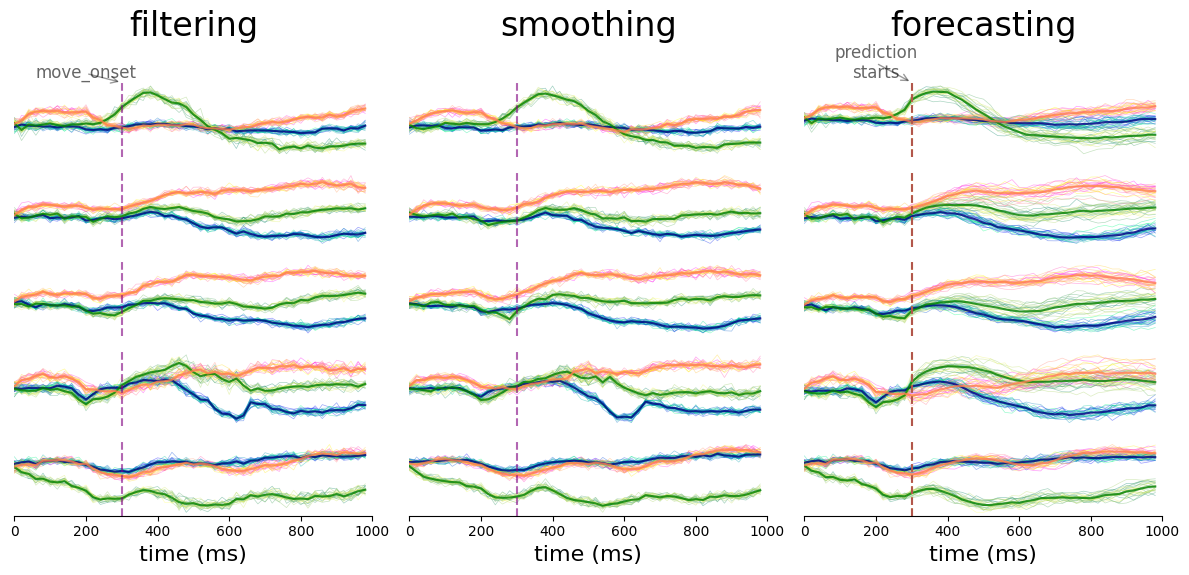

In [16]:
fig, axs = plot_z_samples(
    [z_f_test, z_s_test, z_p_test],
    cfg,
    event_bin_wrt_obs,
    bin_prd_start,
    align_event=aligned_around,
)

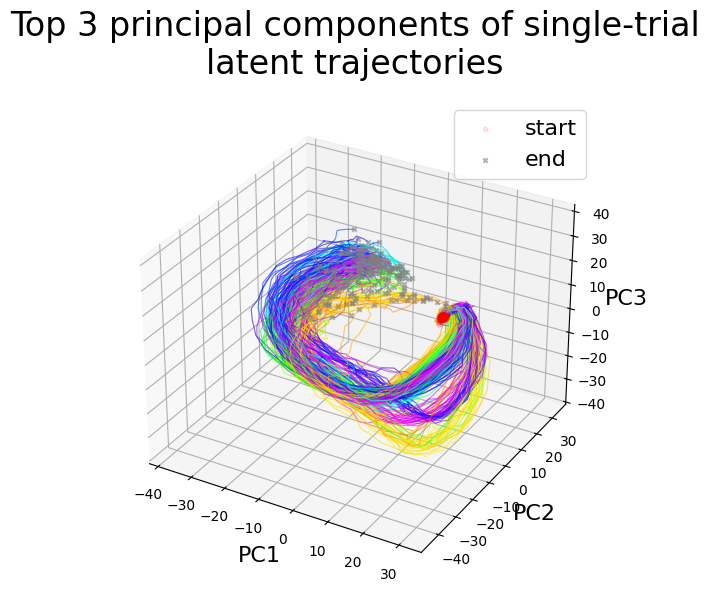

In [17]:
plot_z_3d(z_s_test, vel_test)

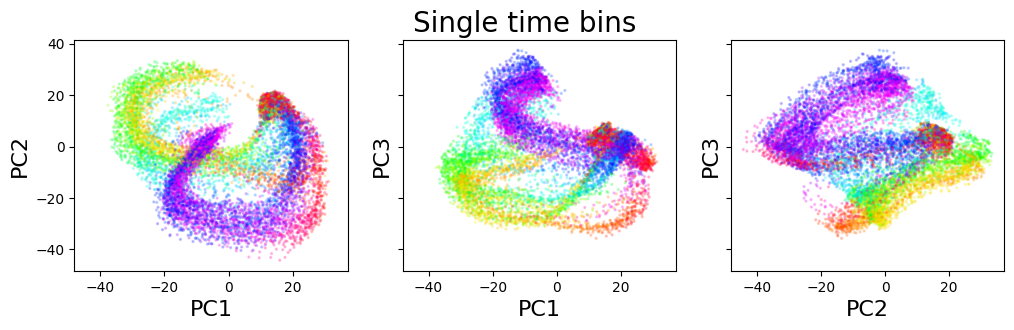

In [18]:
plot_z_single_bins(z_s_test, vel_test)

In [19]:
# Smaples of trajectories
compute_r2(z_p_test, z_f_test)

0.8532860279083252

In [20]:
# Mean trajectories
compute_r2(torch.mean(z_p_test, dim=0), torch.mean(z_f_test, dim=0))

0.9367526173591614

# Latents scaling and rotation

In [21]:
likelihood_pdf, readout_fn = get_ll_pdf_readouf_fn(seq_vae.ssm)

C = readout_fn.weight.detach().cpu()
R = likelihood_pdf.delta * torch.exp(readout_fn.bias).cpu()
b = readout_fn.bias.detach().cpu()

delta = cfg.bin_sz

In [22]:
rotation_matrix, S, U = get_rotation_matrix(likelihood_pdf)
rotation_matrix.shape   # latents x latents

torch.Size([40, 40])

In [23]:
z = z_s_train[:, :, :, :cfg.n_latents_read].detach().cpu()

z_rot = rotate_z(z, rotation_matrix)
z_rot.shape   # samples x trials x bins x latents

torch.Size([25, 1796, 50, 40])

In [24]:
C_rot = rotate_c(R, U)
C_rot.shape   # neurons x latents

torch.Size([192, 40])

In [25]:
class PoissonReadout(nn.Module):
    """
    Poisson likelihood for spike counts with a learnable readout matrix.
    y ~ Poisson(delta * exp(C @ z + b))
    """

    def __init__(self, n_latents, n_neurons, delta=1.0, bias=None, device='cuda'):
        super().__init__()
        self.n_latents = n_latents
        self.n_neurons = n_neurons
        self.delta = delta

        # Readout weights
        self.C = nn.Parameter(torch.zeros(n_neurons, n_latents, device=device))

        # Bias
        if bias is None:
            self.bias = nn.Parameter(torch.zeros(n_neurons, device=device))
        else:
            self.bias = nn.Parameter(bias.clone().detach().to(device))

        # Training logs
        self.training_nll = []

    def forward(self, z):
        """
        z: (trials, time, n_latents)
        returns: (trials, time, n_neurons)
        """
        eta = torch.einsum("tbd,nd->tbn", z, self.C) + self.bias
        rate = self.delta * torch.exp(eta)
        return rate

    def negative_log_likelihood(self, z, y_spikes):
        """
        Mean Poisson negative log-likelihood (up to constant).
        """
        rate = self.forward(z)
        eps = 1e-8
        nll = (rate - y_spikes * torch.log(rate + eps)).mean()
        return nll

    def fit_readout(self, z, y_spikes, lr=1e-2, n_steps=300, verbose=True):
        """
        Optimize C to fit given latents z and spike counts y_spikes.
        """
        self.training_nll = []  # reset logs
        opt = torch.optim.Adam([self.C], lr=lr)

        for step in tqdm(range(n_steps)):
            opt.zero_grad()
            loss = self.negative_log_likelihood(z, y_spikes)
            loss.backward()
            opt.step()

            self.training_nll.append(loss.detach().item())

            if verbose and (step % max(1, n_steps // 5) == 0):
                print(f"Step {step+1}/{n_steps}, NLL: {loss.item():.4f}")

        return self.C.detach().clone()
    
    
def fit_C_per_subset_latents(z_full, y_spikes, delta, bias,
                             lr=1e-2, n_steps=500, device="cuda"):
    """
    Fit Poisson readouts for top-k latent subsets.

    Returns:
        {
            "C":   dict[k] -> (neurons, k) tensor
            "nll": dict[k] -> list of length n_steps
        }
    """
    z_full = z_full.to(device)
    y_spikes = y_spikes.to(device)

    n_latents = z_full.shape[-1]
    n_neurons = y_spikes.shape[-1]

    C_dict = {}
    nll_dict = {}

    for k in tqdm(range(1, n_latents + 1), desc="Fitting C for top-k latents"):
        z_k = z_full[..., :k]

        readout = PoissonReadout(
            n_latents=k,
            n_neurons=n_neurons,
            delta=delta,
            bias=bias,
            device=device,
        )

        C_k = readout.fit_readout(
            z_k, y_spikes, lr=lr, n_steps=n_steps, verbose=False
        )

        C_dict[k] = C_k
        nll_dict[k] = readout.training_nll.copy()

    return {"C": C_dict, "nll": nll_dict}


def fit_C_per_single_latents(z_full, y_spikes, delta, bias,
                             lr=1e-2, n_steps=500, device="cuda"):
    """
    Fit Poisson readouts independently for each latent.

    Returns:
        {
            "C":   dict[k] -> (neurons, 1) tensor
            "nll": dict[k] -> list of length n_steps
        }
    """
    z_full = z_full.to(device)
    y_spikes = y_spikes.to(device)

    n_latents = z_full.shape[-1]
    n_neurons = y_spikes.shape[-1]

    C_dict = {}
    nll_dict = {}

    for k in tqdm(range(n_latents), desc="Fitting C for single latents"):
        z_k = z_full[..., k:k+1]

        readout = PoissonReadout(
            n_latents=1,
            n_neurons=n_neurons,
            delta=delta,
            bias=bias,
            device=device,
        )

        C_k = readout.fit_readout(
            z_k, y_spikes, lr=lr, n_steps=n_steps, verbose=False
        )

        C_dict[k] = C_k
        nll_dict[k] = readout.training_nll.copy()

    return {"C": C_dict, "nll": nll_dict}


def compute_obs_variance_explained_by_top_z(Cs_dict, z_full):
    """
    Computes mean squared log-rate induced by top-k latent subsets.
    """
    z_full = z_full.detach().cpu()

    ks = sorted(Cs_dict.keys())
    results = []

    for k in ks:
        Ck = Cs_dict[k].detach().cpu()   # (neurons, k)
        zk = z_full[..., :k]             # (trials, time, k)

        Z = zk.reshape(-1, k)            # (N, k)
        Z = Z - Z.mean(0, keepdim=True)

        eta = Z @ Ck.T                   # (N, neurons)

        mslr = (eta ** 2).mean()
        results.append(mslr)

    return torch.stack(results)


def compute_obs_variance_explained_by_each_z(Cs_dict, z_full):
    """
    Computes mean squared log-rate induced by each latent independently.
    """
    z_full = z_full.detach().cpu()

    ks = sorted(Cs_dict.keys())
    results = []

    for k in ks:
        Ck = Cs_dict[k].detach().cpu()   # (neurons, 1)
        zk = z_full[..., k:k+1]          # (trials, time, 1)

        Z = zk.reshape(-1, 1)
        Z = Z - Z.mean(0, keepdim=True)

        eta = Z @ Ck.T                   # (N, neurons)

        mslr = (eta ** 2).mean()
        results.append(mslr)

    return torch.stack(results)


def decode_velocity_from_rates_topk(z, vel, Cs_dict, b, delta, alpha=0.01):
    """
    Decode velocity from generated firing rates (top-k latents).
    """
    y = vel.reshape(-1, 2).cpu().numpy()
    r2_scores = []

    for k in sorted(Cs_dict.keys()):
        Ck = Cs_dict[k].cpu()
        zk = z[..., :k].cpu()

        rates = reconstruct_rates(delta, Ck, b.cpu(), zk)
        X = rates.reshape(-1, rates.shape[-1]).numpy()

        clf = Ridge(alpha=alpha)
        clf.fit(X, y)
        y_pred = clf.predict(X)

        r2 = r2_score(y, y_pred, multioutput="uniform_average")
        r2_scores.append(r2)

    return np.array(r2_scores)


def decode_velocity_from_rates_single(z, vel, Cs_dict, b, delta, alpha=0.01):
    """
    Decode velocity from generated firing rates (single latents).
    """
    y = vel.reshape(-1, 2).cpu().numpy()
    r2_scores = []

    for k in sorted(Cs_dict.keys()):
        Ck = Cs_dict[k].cpu()       # (neurons, 1)
        zk = z[..., k:k+1].cpu()   # (trials, time, 1)

        rates = reconstruct_rates(delta, Ck, b.cpu(), zk)
        X = rates.reshape(-1, rates.shape[-1]).numpy()

        clf = Ridge(alpha=alpha)
        clf.fit(X, y)
        y_pred = clf.predict(X)

        r2 = r2_score(y, y_pred, multioutput="uniform_average")
        r2_scores.append(r2)

    return np.array(r2_scores)

In [26]:
#readout_rot_subset_z = fit_C_per_subset_latents(z_rot.mean(dim=0), y_train_obs, cfg.bin_sz, b)

#torch.save(readout_orig_subset_z, "outputs/readout_orig_subset_z.pt")
#torch.save(readout_rot_subset_z, "outputs/readout_rot_subset_z.pt")

In [27]:
readout_orig_subset_z = torch.load("outputs/readout_orig_subset_z.pt")
readout_rot_subset_z = torch.load("outputs/readout_rot_subset_z.pt")

Cs_orig_subset_z = readout_orig_subset_z['C']
Cs_rot_subset_z = readout_rot_subset_z['C']

nll_orig_subset_z = readout_orig_subset_z['nll']
nll_rot_subset_z = readout_rot_subset_z['nll']

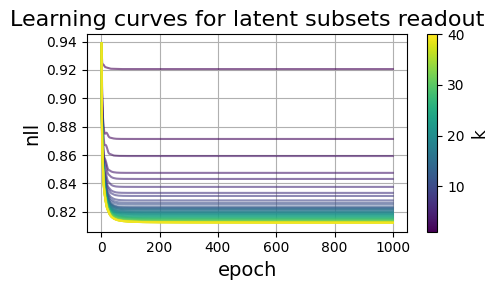

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

# Sort the keys so colors are ordered by k
ks = sorted(nll_rot_subset_z.keys())

norm = Normalize(vmin=min(ks), vmax=max(ks))
cmap = cm.viridis
colors = cmap(norm(ks))

fig, ax = plt.subplots(figsize=(5, 3))

for k, c in zip(ks, colors):
    nll = np.asarray(nll_rot_subset_z[k])
    ax.plot(np.arange(1, len(nll) + 1), nll, color=c, alpha=0.6)

ax.set_xlabel("epoch", fontsize=14)
ax.set_ylabel("nll", fontsize=14)
ax.set_title("Learning curves for latent subsets readout", fontsize=16)
ax.grid(True)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for older matplotlib versions
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("k", fontsize=12)

plt.tight_layout()
plt.show()

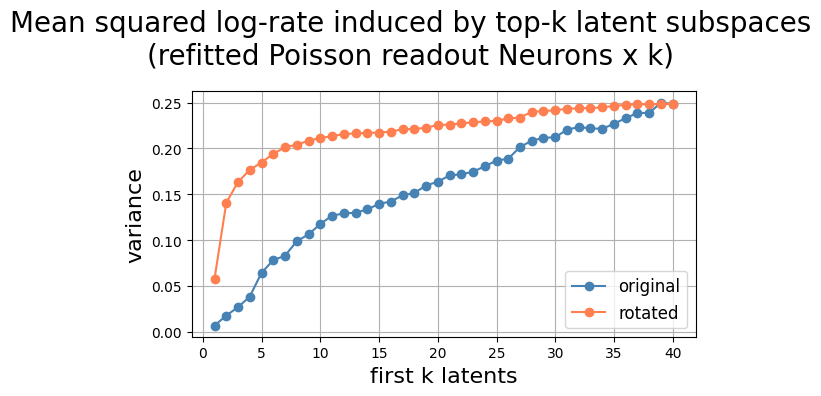

In [29]:
latent_contribs_orig = compute_obs_variance_explained_by_top_z(Cs_orig_subset_z, z.mean(dim=0))
latent_contribs_rot = compute_obs_variance_explained_by_top_z(Cs_rot_subset_z, z_rot.mean(dim=0))

fig = plt.figure(figsize=(6, 4))

x = np.arange(1, len(latent_contribs_orig) + 1)

plt.plot(x, latent_contribs_orig, marker="o", color='steelblue', label="original")
plt.plot(x, latent_contribs_rot, marker="o", color='coral', label="rotated")

plt.xlabel("first k latents", fontsize=16)
plt.ylabel("variance", fontsize=16)

fig.suptitle(
    "Mean squared log-rate induced by top-k latent subspaces\n"
    "(refitted Poisson readout Neurons x k)",
    fontsize=20,
)

plt.grid(True)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

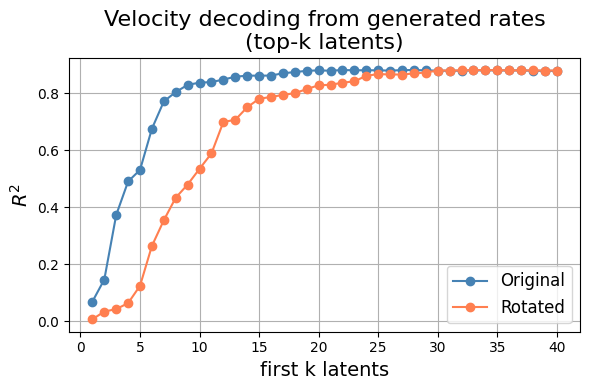

In [30]:
r2_orig_topk = decode_velocity_from_rates_topk(
    z=z,
    vel=vel_train,
    Cs_dict=Cs_orig_subset_z,
    b=b,
    delta=delta,
)

r2_rot_topk = decode_velocity_from_rates_topk(
    z=z_rot,
    vel=vel_train,
    Cs_dict=Cs_rot_subset_z,
    b=b,
    delta=delta,
)

x = np.arange(1, len(r2_orig_topk) + 1)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, r2_orig_topk, marker="o", color="steelblue", label="Original")
ax.plot(x, r2_rot_topk, marker="o", color="coral", label="Rotated")

ax.set_xlabel("first k latents", fontsize=14)
ax.set_ylabel(r"$R^2$", fontsize=14)
ax.set_title("Velocity decoding from generated rates\n(top-k latents)", fontsize=16)

ax.grid(True)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [31]:
#readout_orig_single_z = fit_C_per_single_latents(z.mean(dim=0), y_train_obs, cfg.bin_sz, b)
#readout_rot_single_z = fit_C_per_single_latents(z_rot.mean(dim=0), y_train_obs, cfg.bin_sz, b)

#torch.save(readout_orig_single_z, "outputs/readout_orig_single_z.pt")
#torch.save(readout_rot_single_z, "outputs/readout_rot_single_z.pt")

In [32]:
readout_orig_single_z = torch.load("outputs/readout_orig_single_z.pt")
readout_rot_single_z = torch.load("outputs/readout_rot_single_z.pt")

Cs_orig_single_z = readout_orig_single_z['C']
Cs_rot_single_z = readout_rot_single_z['C']

nll_orig_single_z = readout_orig_single_z['nll']
nll_rot_single_z = readout_rot_single_z['nll']

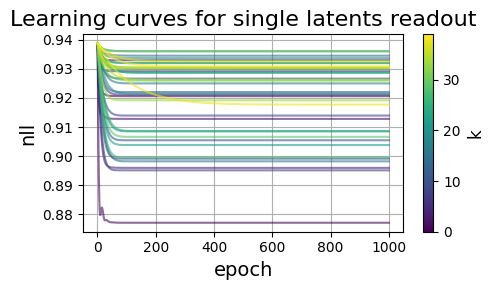

In [33]:
# Sort the keys so colors are ordered by k
ks = sorted(nll_rot_single_z.keys())

norm = Normalize(vmin=min(ks), vmax=max(ks))
cmap = cm.viridis
colors = cmap(norm(ks))

fig, ax = plt.subplots(figsize=(5, 3))

for k, c in zip(ks, colors):
    nll = np.asarray(nll_rot_single_z[k])
    ax.plot(np.arange(1, len(nll) + 1), nll, color=c, alpha=0.6)

ax.set_xlabel("epoch", fontsize=14)
ax.set_ylabel("nll", fontsize=14)
ax.set_title("Learning curves for single latents readout", fontsize=16)
ax.grid(True)

# ---- colorbar ----
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("k", fontsize=12)

plt.tight_layout()
plt.show()

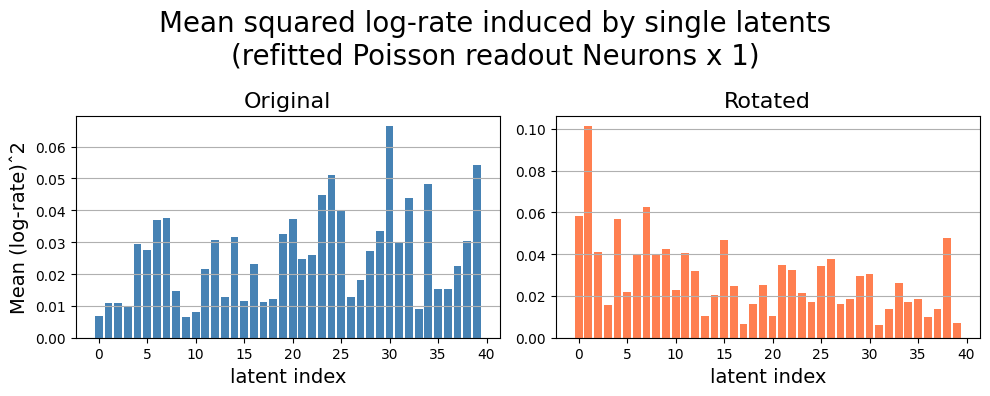

In [34]:
latent_contribs_orig = compute_obs_variance_explained_by_each_z(Cs_orig_single_z, z.mean(dim=0))
latent_contribs_rot = compute_obs_variance_explained_by_each_z(Cs_rot_single_z, z_rot.mean(dim=0))

# --- cumulative normalized mean squared log-rate ---
cum_orig = torch.cumsum(latent_contribs_orig.clone(), dim=0)
cum_rot  = torch.cumsum(latent_contribs_rot.clone(), dim=0)

cum_orig = cum_orig / cum_orig[-1]
cum_rot  = cum_rot / cum_rot[-1]

# convert to numpy for plotting
cum_orig = cum_orig.cpu().numpy()
cum_rot  = cum_rot.cpu().numpy()

orig_np = latent_contribs_orig.detach().cpu().numpy()
rot_np  = latent_contribs_rot.detach().cpu().numpy()

# --- plotting ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = np.arange(0, len(latent_contribs_orig))

# Original (bar)
axes[0].bar(x, orig_np, color="steelblue")
axes[0].set_title("Original", fontsize=16)
axes[0].set_xlabel("latent index", fontsize=14)
axes[0].set_ylabel("Mean (log-rate)ˆ2", fontsize=14)
axes[0].grid(True, axis="y")

# Rotated (bar)
axes[1].bar(x, rot_np, color="coral")
axes[1].set_title("Rotated", fontsize=16)
axes[1].set_xlabel("latent index", fontsize=14)
axes[1].grid(True, axis="y")

# Cumulative normalized curve
#axes[2].plot(x, cum_orig, marker="o", color="steelblue", label="original")
#axes[2].plot(x, cum_rot, marker="o", color="coral", label="rotated")
#axes[2].set_title("Cumulative", fontsize=16)
#axes[2].set_xlabel("latent index", fontsize=14)
#axes[2].set_ylabel("Cumulative var ratio", fontsize=14)
#axes[2].set_ylim(0, 1.05)
#axes[2].grid(True)
#axes[2].legend(fontsize=12)

fig.suptitle(
    "Mean squared log-rate induced by single latents\n"
    "(refitted Poisson readout Neurons x 1)",
    fontsize=20,
)

plt.tight_layout()
plt.show()

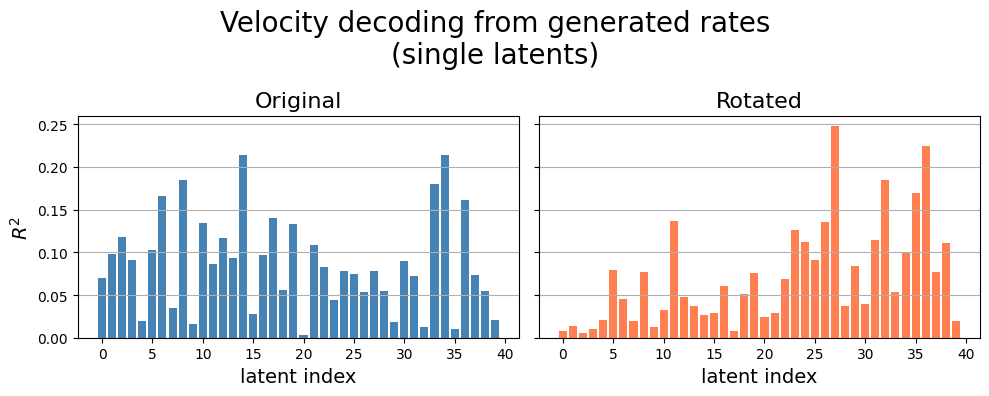

In [35]:
r2_orig_single = decode_velocity_from_rates_single(
    z=z,
    vel=vel_train,
    Cs_dict=Cs_orig_single_z,
    b=b,
    delta=delta,
)

r2_rot_single = decode_velocity_from_rates_single(
    z=z_rot,
    vel=vel_train,
    Cs_dict=Cs_rot_single_z,
    b=b,
    delta=delta,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

x = np.arange(0, len(r2_orig_single))

# --- Original ---
axes[0].bar(x, r2_orig_single, color="steelblue")
axes[0].set_title("Original", fontsize=16)
axes[0].set_xlabel("latent index", fontsize=14)
axes[0].set_ylabel(r"$R^2$", fontsize=14)
axes[0].grid(True, axis="y")

# --- Rotated ---
axes[1].bar(x, r2_rot_single, color="coral")
axes[1].set_title("Rotated", fontsize=16)
axes[1].set_xlabel("latent index", fontsize=14)
axes[1].grid(True, axis="y")

fig.suptitle(
    "Velocity decoding from generated rates\n(single latents)",
    fontsize=20
)

plt.tight_layout()
plt.show()

# Greedy incremental latent rotation

In [36]:
class GreedyPoissonReadout(nn.Module):
    def __init__(self, n_neurons, n_latents, delta=0.02, device="cuda", init_bias=None):
        super().__init__()
        self.n_neurons = n_neurons
        self.n_latents = n_latents
        self.delta = delta
        self.device = torch.device(device)

        self.U = nn.ParameterList()
        self.V = nn.ParameterList()

        if init_bias is not None:
            self.bias = nn.Parameter(init_bias.to(self.device))
            self.freeze_bias = True
        else:
            self.bias = nn.Parameter(0.01 * torch.randn(self.n_neurons, device=self.device))
            self.freeze_bias = False

        self.to(self.device)

    def forward(self, z):
        z = z.to(self.device)
        eta = self.bias
        for u, v in zip(self.U, self.V):
            proj = torch.einsum("tbd,d->tb", z, v)
            eta = eta + proj.unsqueeze(-1) * u
        return self.delta * torch.exp(eta)

    def add_component(self):
        u = nn.Parameter(0.01 * torch.randn(self.n_neurons, device=self.device))
        v = nn.Parameter(0.01 * torch.randn(self.n_latents, device=self.device))
        self.U.append(u)
        self.V.append(v)

In [37]:
def get_component_lr(k, base_lr=1e-2, decay=0.9):
    """
    Compute learning rate for component k (1-based).
    """
    return base_lr * (decay ** (k - 1))

In [38]:
def whiten_z(z, eps=1e-6):
    """
    Compute whitening transform for latent trajectories.

    Args:
        z: (trials, time, n_latents)
    Returns:
        z_white: whitened z, same shape
        W: whitening matrix (n_latents, n_latents)
        mu: latent mean (n_latents,)
    """
    device = z.device
    T, B, D = z.shape

    # Flatten samples
    Z = z.reshape(-1, D)

    # Mean
    mu = Z.mean(0, keepdim=True)
    Zc = Z - mu

    # Covariance
    C = (Zc.T @ Zc) / (Zc.shape[0] - 1)

    # Eigendecomposition
    eigvals, eigvecs = torch.linalg.eigh(C)

    # Sort descending
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Whitening matrix
    W = eigvecs @ torch.diag(1.0 / torch.sqrt(eigvals + eps))

    # Apply whitening
    Z_white = Zc @ W
    z_white = Z_white.reshape(T, B, D)

    return z_white, W, mu.squeeze(0)

In [39]:
def fit_new_component(
    model,
    z,
    y,
    lr=1e-2,
    n_steps=300,
    residualize=False,
    use_early_stopping=False,
    tol=1e-5,
    patience=5,
):
    """
    Fit a new greedy component.

    Args:
        residualize: whether to use residual log-rate objective
        use_early_stopping: whether to stop when loss plateaus
    """
    device = model.bias.device
    z = z.to(device)
    y = y.to(device)

    # Freeze everything
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze newest component + bias
    model.U[-1].requires_grad = True
    model.V[-1].requires_grad = True
    model.bias.requires_grad = True

    opt = torch.optim.Adam(
        [model.U[-1], model.V[-1], model.bias],
        lr=lr,
    )

    loss_log = []
    prev_loss = None
    stall_count = 0

    for _ in tqdm(range(n_steps)):
        opt.zero_grad()

        rate = model(z)

        if not residualize:
            # Exact Poisson NLL
            loss = (rate - y * torch.log(rate + 1e-8)).mean()
        else:
            # Residualized objective in log-rate space
            residual = y - rate
            u = model.U[-1]
            v = model.V[-1]
            proj = torch.einsum("tbd,d->tb", z, v)
            eta_new = proj.unsqueeze(-1) * u
            loss = ((rate * eta_new - residual) ** 2).mean()

        loss.backward()
        opt.step()

        loss_val = loss.item()
        loss_log.append(loss_val)

        if use_early_stopping and prev_loss is not None:
            if abs(prev_loss - loss_val) < tol:
                stall_count += 1
                if stall_count >= patience:
                    break
            else:
                stall_count = 0

        prev_loss = loss_val

    return loss_log

In [40]:
likelihood_pdf, readout_fn = get_ll_pdf_readouf_fn(seq_vae.ssm)
b = readout_fn.bias.detach().cpu()

model = GreedyPoissonReadout(
    n_neurons=n_neurons_obs,
    n_latents=cfg.n_latents_read,
    delta=cfg.bin_sz,
    device="cuda:0",
    init_bias=b,
)

model = torch.nn.DataParallel(model, device_ids=[0, 1])

nll_history = {}
U_history = {}
V_history = {}
bias_history = {}

for k in range(cfg.n_latents_read):
    model.module.add_component()

    comp_lr = get_component_lr(k + 1, base_lr=1e-3, decay=1.)
    print(f"Adding component {k + 1} with lr={comp_lr:.5f}")

    z_white, W, z_mu = whiten_z(z.mean(dim=0))
    z_centered = z.mean(dim=0) - z.mean(dim=0).mean(dim=(0, 1), keepdim=True)

    nll = fit_new_component(
        model.module,
        z_centered,
        y_train_obs,
        lr=comp_lr,
        n_steps=300,
    )
    nll_history[k + 1] = nll

    with torch.no_grad():
        U_history[k + 1] = torch.stack(
            [u.detach().cpu() for u in model.module.U], dim=1
        )
        V_history[k + 1] = torch.stack(
            [v.detach().cpu() for v in model.module.V], dim=0
        )
        bias_history[k + 1] = model.module.bias.detach().cpu()

Adding component 1 with lr=0.00100


100%|██████████| 300/300 [00:01<00:00, 216.23it/s]


Adding component 2 with lr=0.00100


100%|██████████| 300/300 [00:01<00:00, 210.49it/s]


Adding component 3 with lr=0.00100


...

100%|██████████| 300/300 [00:05<00:00, 51.13it/s]


Adding component 39 with lr=0.00100


100%|██████████| 300/300 [00:05<00:00, 50.19it/s]


Adding component 40 with lr=0.00100


100%|██████████| 300/300 [00:06<00:00, 49.20it/s]


In [41]:
torch.save({
    "model_state_dict": model.state_dict(),
    "nll_history": nll_history,
    "U_history": U_history,
    "V_history": V_history,
    "bias_history": bias_history
}, "outputs/greedy_poisson_readout.pt")

In [42]:
checkpoint = torch.load("outputs/greedy_poisson_readout.pt", map_location="cpu")
state_dict = checkpoint["model_state_dict"]

# Strip the "module." prefix if needed
from collections import OrderedDict
new_state_dict = OrderedDict()

for k, v in state_dict.items():
    name = k.replace("module.", "")
    new_state_dict[name] = v

# Create the model with **enough latent slots** to match saved state
model = GreedyPoissonReadout(
    n_neurons=n_neurons_obs,
    n_latents=cfg.n_latents_read,  # must match how many U/V were added
    delta=cfg.bin_sz,
    device="cpu",
)

# Add components so U/V lists match saved state
for _ in range(cfg.n_latents_read):
    model.add_component()

model.load_state_dict(new_state_dict)
nll_history = checkpoint["nll_history"]

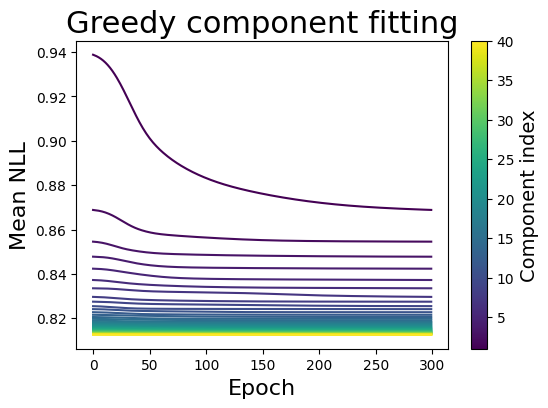

In [43]:
import matplotlib as mpl

ks = sorted(nll_history.keys())

cmap = plt.cm.viridis
norm = Normalize(vmin=min(ks), vmax=max(ks))

fig, ax = plt.subplots(figsize=(6, 4))

for k in ks:
    ax.plot(nll_history[k], color=cmap(norm(k)))

ax.set_xlabel('Epoch', fontsize=16)
ax.set_ylabel('Mean NLL', fontsize=16)
ax.set_title('Greedy component fitting', fontsize=22)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Component index', fontsize=14)

plt.show()

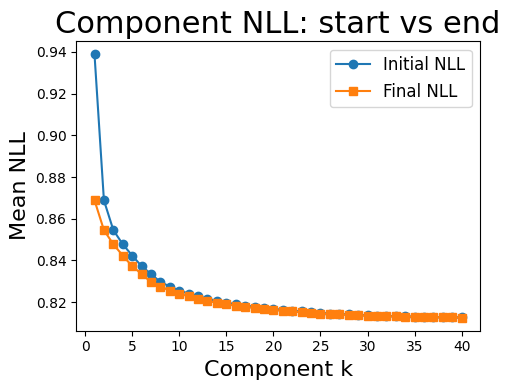

In [44]:
initial_nll = [nll[0] for nll in nll_history.values()]
final_nll   = [nll[-1] for nll in nll_history.values()]

plt.figure(figsize=(5, 4))

plt.plot(range(1, len(initial_nll)+1), initial_nll, 'o-', label='Initial NLL')
plt.plot(range(1, len(final_nll)+1), final_nll, 's-', label='Final NLL')

plt.xlabel('Component k', fontsize=16)
plt.ylabel('Mean NLL', fontsize=16)
plt.title('Component NLL: start vs end', fontsize=22)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

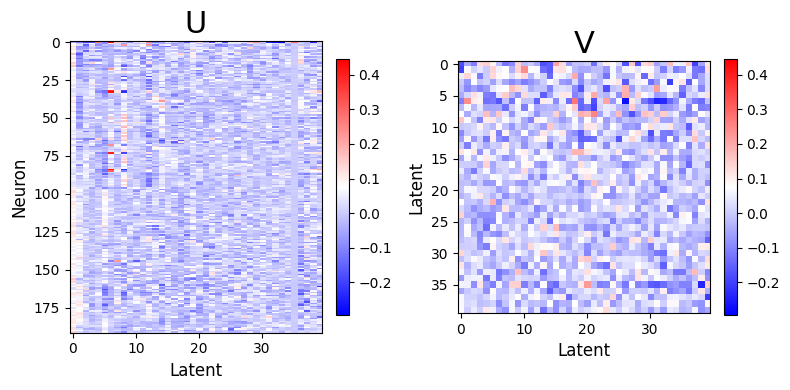

In [45]:
U_hist = checkpoint['U_history']
V_hist = checkpoint['V_history']
b_hist = checkpoint['bias_history']

U = U_hist[40]          # (n_neurons, latents)
V = V_hist[40]          # (n_latents, n_latents)
b_greedy = b_hist[40]   # (n_neurons,)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

vmin = min(U.min(), V.min())
vmax = max(U.max(), V.max())

im0 = axes[0].imshow(U, aspect=0.4, vmin=vmin, vmax=vmax, cmap='bwr', interpolation='none')
axes[0].set_title('U', fontsize=22)
axes[0].set_xlabel('Latent', fontsize=12)
axes[0].set_ylabel('Neuron', fontsize=12)

im1 = axes[1].imshow(V, vmin=vmin, vmax=vmax, cmap='bwr', interpolation='none')
axes[1].set_title('V', fontsize=22)
axes[1].set_xlabel('Latent', fontsize=12)
axes[1].set_ylabel('Latent', fontsize=12)

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)

axes[0].set_aspect('auto')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [46]:
def compute_cumulative_lograte_variance(
    U,   # (n_neurons, n_latents)
    V,   # (n_latents, n_latents)
    z,   # (trials, time, n_latents)
):
    # Rotate latents
    z_rot = torch.einsum("tbd,dl->tbl", z, V).detach().cpu()

    var_lograte = []
    for k in range(1, U.shape[1] + 1):

        U_k = U[:, :k]              # (n_neurons, k)
        z_k = z_rot[..., :k]        # (trials, time, k)

        Z = z_k.reshape(-1, k)      # (trials*time, k)
        Z = Z - Z.mean(0, keepdim=True)

        eta = Z @ U_k.T             # (trials*time, neurons)
        eta = eta - eta.mean(0, keepdim=True)

        var_lograte.append((eta ** 2).mean())

    return torch.stack(var_lograte)

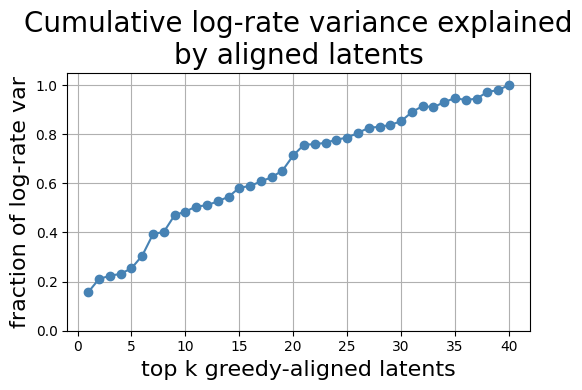

In [47]:
var_lograte = compute_cumulative_lograte_variance(U, V, z=z.mean(dim=0))
var_ratio = var_lograte / var_lograte[-1]

plt.figure(figsize=(5.5, 4))

plt.plot(np.arange(1, len(var_ratio) + 1), var_ratio,
         marker="o", color="steelblue")

plt.xlabel("top k greedy-aligned latents", fontsize=16)
plt.ylabel("fraction of log-rate var", fontsize=16)
plt.title("Cumulative log-rate variance explained\nby aligned latents", fontsize=20)

plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
def compute_per_latent_variance(
    U,   # (n_neurons, n_latents)
    V,   # (n_latents, n_latents)
    z,   # (trials, time, n_latents)
):
    """
    Marginal variance of each latent's contribution to log-rate.
    ONLY valid if components are NOT residual-trained.
    """
    device = z.device

    z_rot = torch.einsum("tbd,dl->tbl", z, V.to(device)).detach().cpu()

    per_latent_var = []

    for k in range(U.shape[1]):
        z_k = z_rot[..., k].reshape(-1, 1)
        z_k = z_k - z_k.mean(0, keepdim=True)

        u_k = U[:, k]               # (neurons,)
        eta_k = z_k @ u_k[None, :]        # (trials, neurons)

        eta_k = eta_k - eta_k.mean(0, keepdim=True)
        per_latent_var.append((eta_k ** 2).mean())

    return torch.stack(per_latent_var)

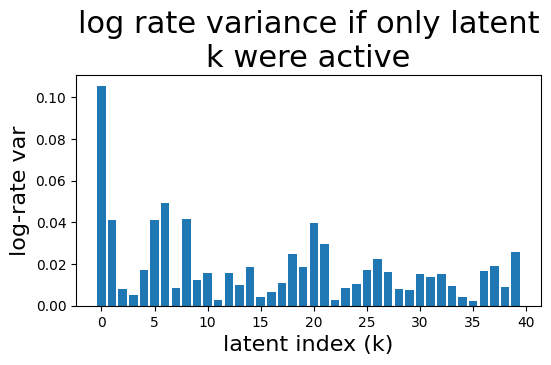

In [49]:
per_latent_var = compute_per_latent_variance(U, V, z.mean(dim=0)).numpy()

plt.figure(figsize=(6, 3))
plt.bar(range(len(per_latent_var)), per_latent_var, color='C0')
plt.xlabel("latent index (k)", fontsize=16)
plt.ylabel("log-rate var", fontsize=16)
plt.title("log rate variance if only latent\nk were active", fontsize=22)
plt.show()

In [50]:
def reconstruct_rates_greedy(z, U, V, bias, delta):

    proj = torch.einsum("tbd,kd->tbk", z, V)
    eta = torch.einsum("tbk,nk->tbn", proj, U) + bias.view(1,1,-1)

    return delta * torch.exp(eta)

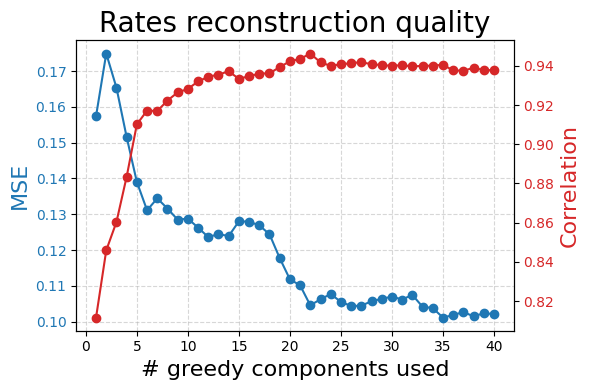

In [51]:
us_mses = []
us_corrs = []

with torch.no_grad():
    rate_hat = reconstruct_rates(delta, C, b, z.mean(dim=0))

    for k in V_hist.keys():
        rate_fit = reconstruct_rates_greedy(z.mean(dim=0), U_hist[k], V_hist[k], b_hist[k], delta)

        mse = ((rate_fit - rate_hat)**2).mean().item()
        corr = torch.corrcoef(torch.stack([rate_fit.flatten(), rate_hat.flatten()]))[0, 1].item()

        us_mses.append(mse)
        us_corrs.append(corr)

ks = list(V_hist.keys())

fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot MSE on left y-axis
color_mse = 'tab:blue'
ax1.plot(ks, us_mses, 'o-', color=color_mse)
ax1.set_xlabel('# greedy components used', fontsize=16)
ax1.set_ylabel('MSE', color=color_mse, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_mse)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Plot correlation on right y-axis
ax2 = ax1.twinx()
color_corr = 'tab:red'
ax2.plot(ks, us_corrs, 'o-', color=color_corr)
ax2.set_ylabel('Correlation', color=color_corr, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_corr)

# Optional: combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.title('Rates reconstruction quality', fontsize=20)
plt.tight_layout()
plt.show()

In [52]:
def decode_velocity_from_greedy_rates(
    z,                  # (trials, time, n_latents) RAW latents
    vel,                # (trials, time, 2)
    U_history,          # dict: k -> (n_neurons, k)
    V_history,          # dict: k -> (k, n_latents)
    bias_history,       # dict: k -> (n_neurons,)
    delta=0.02,
    alpha=0.01,
):
    """
    Decode velocity from rates generated by GREEDY Poisson readout.
    """

    device = z.device
    y = vel.reshape(-1, vel.shape[-1]).cpu().numpy()

    r2_scores = []

    for k in sorted(U_history.keys()):
        rates = reconstruct_rates_greedy(z, U_history[k].to(device), V_history[k].to(device), bias_history[k].to(device), delta)

        X = rates.reshape(-1, rates.shape[-1]).cpu().numpy()

        clf = Ridge(alpha=alpha)
        clf.fit(X, y)
        y_pred = clf.predict(X)

        r2 = r2_score(y, y_pred, multioutput="uniform_average")
        r2_scores.append(r2)

    return np.array(r2_scores)


def decode_velocity_from_latents(
    z_rot,      # (trials, time, n_latents) rotated using FINAL V
    vel,        # (trials, time, 2)
    ks=None,    # list of k values to evaluate
    alpha=0.01
):
    """
    Decode velocity directly from top-k rotated latents.

    Returns
    -------
    r2_scores : np.array (len(ks),)
    """
    assert z_rot.shape[:2] == vel.shape[:2]

    # Flatten behavior
    y = vel.reshape(-1, vel.shape[-1]).cpu().numpy()

    if ks is None:
        ks = range(1, z_rot.shape[-1] + 1)

    r2_scores = []

    for k in ks:
        # take top-k greedy latents
        z_k = z_rot[..., :k]

        # flatten trials*time
        X = z_k.reshape(-1, k).cpu().numpy()

        clf = Ridge(alpha=alpha)
        clf.fit(X, y)
        y_pred = clf.predict(X)

        r2 = r2_score(y, y_pred, multioutput="uniform_average")
        r2_scores.append(r2)

    return np.array(r2_scores)

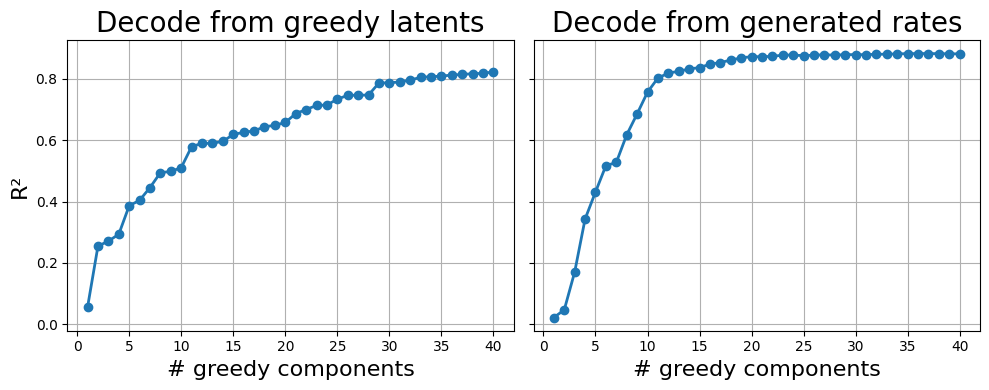

In [53]:
z_greedy = torch.einsum("tbd,dk->tbk", z.mean(dim=0), V)

r2_rates = decode_velocity_from_greedy_rates(
    z=z.mean(dim=0),
    vel=vel_train,
    U_history=U_hist,
    V_history=V_hist,
    bias_history=b_hist,
    delta=cfg.bin_sz,
    alpha=0.01,
)

r2_latent = decode_velocity_from_latents(
    z_rot=z_greedy,
    vel=vel_train,
    alpha=0.01
)

ks = np.arange(1, len(r2_latent) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---- LEFT: decode directly from latents ----
axes[0].plot(ks, r2_latent, 'o-', linewidth=2)
axes[0].set_xlabel("# greedy components", fontsize=16)
axes[0].set_ylabel("R²", fontsize=16)
axes[0].set_title("Decode from greedy latents", fontsize=20)
axes[0].grid(True)

# ---- RIGHT: decode from generated rates ----
axes[1].plot(ks, r2_rates, 'o-', linewidth=2)
axes[1].set_xlabel("# greedy components", fontsize=16)
axes[1].set_title("Decode from generated rates", fontsize=20)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
device = "cuda"

readout = PoissonReadout(
    n_latents=cfg.n_latents_read,
    n_neurons=n_neurons_obs,
    delta=cfg.bin_sz,
    bias=b_greedy,
    device="cuda",
)

z_greedy = torch.einsum("tbd,dk->tbk", z.mean(dim=0), V)

C_bar = readout.fit_readout(
    z_greedy.to(device),
    y_train_obs.to(device),
    lr=1e-3, n_steps=1000, verbose=False
).to('cpu')

v = abs(C_bar).max()
plt.imshow(C_bar, aspect=0.3, cmap='bwr', interpolation='none',
           vmin=-v, vmax=v)
plt.colorbar()
plt.show()

In [ ]:
with torch.no_grad():
    rate_hat = reconstruct_rates(delta, C, b, z.mean(dim=0))
    rate_fit = reconstruct_rates(delta, C_bar, b, z_greedy)

    mse = ((rate_fit - rate_hat)**2).mean().item()
    corr = torch.corrcoef(torch.stack([rate_fit.flatten(), rate_hat.flatten()]))[0, 1].item()

print(f"MSE between refitted rates and true spikes: {mse:.4f}")
print(f"Correlation between refitted rates and true spikes: {corr:.4f}")

In [ ]:
device = "cuda"

# Dictionary to store fitted C for each greedy component set
C_history = {}

for k, V_k in V_hist.items():
    print(f"Fitting readout for first {k} greedy components")

    # Take only the first k latents from V
    V_k_sub = V_k[:k, :].to(z.device)  # shape: (k, n_latents)

    # Rotate the original latents into aligned space
    # Resulting z_aligned has shape (trials, time, k)
    z_aligned = torch.einsum("tbd,kd->tbk", z.mean(dim=0), V_k_sub)
    b_k = b_hist[k]

    # Instantiate a new Poisson readout
    readout = PoissonReadout(
        n_neurons=y_train_obs.shape[-1],
        n_latents=k,
        delta=cfg.bin_sz,
        bias=b_k,
        device=device,
    )

    # Fit C to the rotated latents
    C_fitted = readout.fit_readout(
        z_aligned.to(device),
        y_train_obs.to(device),
        lr=1e-3,
        n_steps=1000,
        verbose=False,
    ).to("cpu")

    # Store in dictionary
    C_history[k] = C_fitted

In [ ]:
cs_mses = []
cs_corrs = []

with torch.no_grad():
    rate_hat = reconstruct_rates(delta, C, b, z.mean(dim=0))

for k, V_k in V_hist.items():

    z_greedy_k = torch.einsum("tbd,kd->tbk", z.mean(dim=0), V_k)
    rate_fit = reconstruct_rates(delta, C_history[k], b, z_greedy_k)

    mse = ((rate_fit - rate_hat)**2).mean().item()
    corr = torch.corrcoef(torch.stack([rate_fit.flatten(), rate_hat.flatten()]))[0, 1].item()

    cs_mses.append(mse)
    cs_corrs.append(corr)

ks = list(V_hist.keys())

fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot MSE on left y-axis
color_mse = 'tab:blue'
ax1.plot(ks, cs_mses, 'o-', color=color_mse, label='MSE')
ax1.set_xlabel('# greedy components used', fontsize=16)
ax1.set_ylabel('MSE', color=color_mse, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_mse)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Plot correlation on right y-axis
ax2 = ax1.twinx()
color_corr = 'tab:red'
ax2.plot(ks, cs_corrs, 'o-', color=color_corr, label='Correlation')
ax2.set_ylabel('Correlation', color=color_corr, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_corr)

# Optional: combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(lines + lines2, labels + labels2, loc='best', fontsize=12)

plt.title('Rates reconstruction quality', fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
def decode_velocity_from_rates(
    z_rot,          # (trials, time, n_latents) already rotated using final V
    vel,            # (trials, time, 2) behavior to decode
    C_history,      # dict: k -> C_k (n_neurons x k)
    b,              # bias vector (n_neurons,)
    delta=0.02,     # bin size
    alpha=0.01      # Ridge regularization
):
    """
    Decode velocity from generated rates using top-k greedy components.

    Returns:
        r2_scores: np.array of length len(C_history), R² for each k
    """
    device = z_rot.device if isinstance(z_rot, torch.Tensor) else "cpu"
    vel_flat = vel.reshape(-1, vel.shape[-1]).cpu().numpy()  # flatten trials*time

    r2_scores = []

    for k in sorted(C_history.keys()):
        Ck = C_history[k].to(device)         # (n_neurons, k)
        z_k = z_rot[..., :k].to(device)      # (trials, time, k)

        # Generate rates
        # eta = z_k @ Ck.T + b
        eta = torch.einsum("tbn,nk->tbk", z_k, Ck.T) + b.view(1, 1, -1)
        rates = delta * torch.exp(eta)

        # Flatten rates to (trials*time, n_neurons)
        X = rates.reshape(-1, rates.shape[-1]).cpu().numpy()

        # Decode velocity
        clf = Ridge(alpha=alpha)
        clf.fit(X, vel_flat)
        y_pred = clf.predict(X)

        r2 = r2_score(vel_flat, y_pred, multioutput="uniform_average")
        r2_scores.append(r2)

    return np.array(r2_scores)

In [ ]:
z_greedy = torch.einsum("tbd,dk->tbk", z.mean(dim=0), V)

r2_rates = decode_velocity_from_rates(
    z_rot=z_greedy,
    vel=vel_train,
    C_history=C_history,
    b=b,
    delta=cfg.bin_sz,
    alpha=0.01
)

r2_latent = decode_velocity_from_latents(
    z_rot=z_greedy,
    vel=vel_train,
    alpha=0.01
)

ks = np.arange(1, len(r2_latent) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---- LEFT: decode directly from latents ----
axes[0].plot(ks, r2_latent, 'o-', linewidth=2)
axes[0].set_xlabel("# greedy components", fontsize=16)
axes[0].set_ylabel("R²", fontsize=16)
axes[0].set_title("Decode from greedy latents", fontsize=20)
axes[0].grid(True)

# ---- RIGHT: decode from generated rates ----
axes[1].plot(ks, r2_rates, 'o-', linewidth=2)
axes[1].set_xlabel("# greedy components", fontsize=16)
axes[1].set_title("Decode from generated rates", fontsize=20)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Greedey incremental rotation + Reduced Rank Regression

In [54]:
class RRRPoissonReadout(nn.Module):
    def __init__(self, n_neurons, n_latents, rank, delta=0.02, init_bias=None):
        super().__init__()
        self.n_neurons = n_neurons
        self.n_latents = n_latents
        self.rank = rank
        self.delta = delta

        self.U = nn.Parameter(0.01 * torch.randn(n_neurons, rank))
        self.V = nn.Parameter(0.01 * torch.randn(n_latents, rank))

        if init_bias is not None:
            self.bias = nn.Parameter(init_bias.clone())
        else:
            self.bias = nn.Parameter(torch.zeros(n_neurons))

    def forward(self, z):
        # z: (t, b, d)
        proj = torch.einsum("tbd,dk->tbk", z, self.V)
        eta = torch.einsum("tbk,nk->tbn", proj, self.U)
        eta = eta + self.bias.view(1,1,-1)
        return self.delta * torch.exp(eta)

In [ ]:
def fit_rrr_poisson(
    model,
    z,
    y,
    lr=1e-3,
    n_steps=2000
):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_log = []

    for _ in tqdm(range(n_steps)):
        opt.zero_grad()

        rate = model(z)
        loss = (rate - y * torch.log(rate + 1e-8)).mean()

        loss.backward()
        opt.step()

        loss_log.append(loss.item())

    return loss_log

In [ ]:
model_rrr = RRRPoissonReadout(
    n_neurons=n_neurons_obs,
    n_latents=cfg.n_latents_read,
    rank=2,
    delta=cfg.bin_sz,
    init_bias=b
).to(z.device)

loss_rrr = fit_rrr_poisson(
    model_rrr,
    z.mean(dim=0),
    y_train_obs,
    lr=1e-3,
    n_steps=3000
)

In [57]:
class SequentialRRRPoisson(nn.Module):
    def __init__(self, n_neurons, n_latents, delta=0.02, device="cuda", init_bias=None):
        super().__init__()
        self.n_neurons = n_neurons
        self.n_latents = n_latents
        self.delta = delta
        self.device = torch.device(device)

        self.U = nn.ParameterList()
        self.V = nn.ParameterList()
        if init_bias is not None:
            self.bias = nn.Parameter(init_bias.to(self.device))
        else:
            self.bias = nn.Parameter(torch.zeros(n_neurons, device=self.device))

        self.to(self.device)
    
    def forward(self, z):
        z = z.to(self.device)
        eta = self.bias
        for u, v in zip(self.U, self.V):
            proj = torch.einsum("tbd,d->tb", z, v)
            eta = eta + proj.unsqueeze(-1) * u
        return eta

    def add_component(self):
        u = nn.Parameter(0.01 * torch.randn(self.n_neurons, device=self.device))
    
        v = torch.randn(self.n_latents, device=self.device)
        v = v / (v.norm() + 1e-8)
        v = nn.Parameter(v)
    
        self.U.append(u)
        self.V.append(v)

In [58]:
def fit_sequential_rrr(
    model,
    z,
    y,
    n_components,
    n_steps=300,
    lr=1e-3,
    freeze_previous=True,
    center_latents=False,
):
    """
    Fit sequential RRR components one by one (true incremental version).
    """
    device = model.bias.device
    z = z.to(device)
    y = y.to(device)
    
    if center_latents:
        z = z - z.mean(dim=(0, 1), keepdim=True)

    U_hist = {}
    V_hist = {}
    bias_hist = {}
    nll_history = {}

    for k in range(n_components):
        # Add one new component
        model.add_component()

        # Freeze previous components
        if freeze_previous:
            for i in range(k):
                model.U[i].requires_grad = False
                model.V[i].requires_grad = False

        # Unfreeze current component + bias
        model.U[k].requires_grad = True
        model.V[k].requires_grad = True
        model.bias.requires_grad = True

        optimizer = torch.optim.Adam(
            [model.U[k], model.V[k], model.bias], lr=lr
        )

        loss_log = []

        for step in tqdm(range(n_steps), desc=f"Fitting component {k+1}"):
            optimizer.zero_grad()
            
            eta = model(z)
            rate = model.delta * torch.exp(eta)
            loss = (rate - y * eta).mean()
            
            loss.backward()
            optimizer.step()
            
            with torch.no_grad():
                model.V[k].div_(model.V[k].norm() + 1e-8)
                
            loss_log.append(loss.item())

        nll_history[k + 1] = loss_log

        # Save snapshot
        with torch.no_grad():
            U_hist[k + 1] = torch.stack([u.detach().cpu() for u in model.U], dim=1)
            V_hist[k + 1] = torch.stack([v.detach().cpu() for v in model.V], dim=0)
            bias_hist[k + 1] = model.bias.detach().cpu()

    return U_hist, V_hist, bias_hist, nll_history

In [59]:
n_components = z.shape[-1]

n_neurons = y_train_obs.shape[-1]
n_latents = z.shape[-1]
delta = cfg.bin_sz
device = "cuda:0"

# optional: initialize bias from your previous SSM readout
likelihood_pdf, readout_fn = get_ll_pdf_readouf_fn(seq_vae.ssm)
init_bias = readout_fn.bias.detach().cpu()

model_rrr = SequentialRRRPoisson(
    n_neurons=n_neurons,
    n_latents=n_latents,
    delta=delta,
    device=device,
)

U_hist, V_hist, bias_hist, nll_history = fit_sequential_rrr(
    model_rrr,
    z=z.mean(dim=0),
    y=y_train_obs,
    n_components=n_components,
    n_steps=300,
    lr=1e-3,
    freeze_previous=True,
    center_latents=True,
)

Fitting component 40: 100%|██████████| 300/300 [00:05<00:00, 50.74it/s]


In [60]:
torch.save(
    {
        "model_state_dict": model_rrr.state_dict(),
        "nll_history": nll_history,
        "U_history": U_hist,
        "V_history": V_hist,
        "bias_history": bias_hist,
    },
    "outputs/sequential_rrr_poisson.pt"
)

In [61]:
n_components = z.shape[-1]

n_neurons = y_train_obs.shape[-1]
n_latents = z.shape[-1]
delta = cfg.bin_sz
device = "cuda:0"

ckpt = torch.load("outputs/sequential_rrr_poisson.pt", map_location='cpu')

model_rrr = SequentialRRRPoisson(
    n_neurons=n_neurons,
    n_latents=n_latents,
    delta=delta,
    device=device,
)

# MUST recreate components before loading state_dict
for _ in range(n_latents):
    model_rrr.add_component()

model_rrr.load_state_dict(ckpt["model_state_dict"])
model_rrr.eval()

# restore histories
nll_history  = ckpt["nll_history"]
U_hist       = ckpt["U_history"]
V_hist       = ckpt["V_history"]
bias_hist    = ckpt["bias_history"]

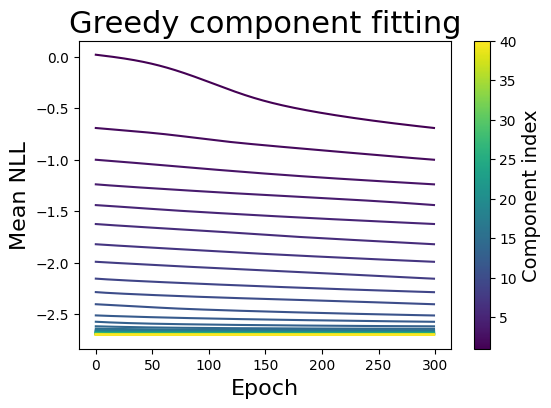

In [62]:
cmap = plt.cm.viridis
norm = Normalize(vmin=min(ks), vmax=max(ks))

fig, ax = plt.subplots(figsize=(6, 4))

for k in sorted(nll_history.keys()):
    ax.plot(nll_history[k], color=cmap(norm(k)))

ax.set_xlabel('Epoch', fontsize=16)
ax.set_ylabel('Mean NLL', fontsize=16)
ax.set_title('Greedy component fitting', fontsize=22)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Component index', fontsize=14)

plt.show()

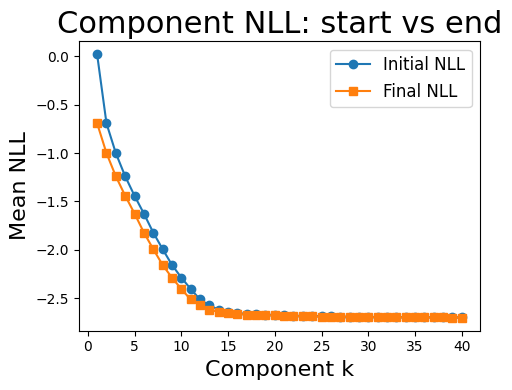

In [63]:
initial_nll = [nll[0] for nll in nll_history.values()]
final_nll   = [nll[-1] for nll in nll_history.values()]

plt.figure(figsize=(5, 4))

plt.plot(range(1, len(initial_nll)+1), initial_nll, 'o-', label='Initial NLL')
plt.plot(range(1, len(final_nll)+1), final_nll, 's-', label='Final NLL')

plt.xlabel('Component k', fontsize=16)
plt.ylabel('Mean NLL', fontsize=16)
plt.title('Component NLL: start vs end', fontsize=22)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

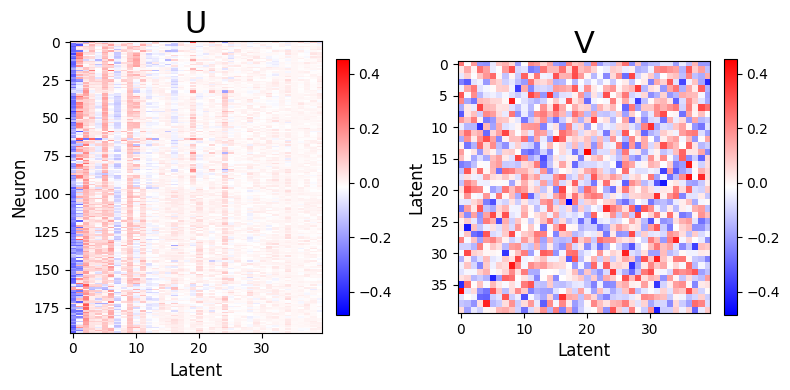

In [64]:
U_full = U_hist[max(U_hist.keys())]   # (n_neurons, n_latents)
V_full = V_hist[max(V_hist.keys())]   # (n_latents, n_latents)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

vmin = min(U_full.min(), V_full.min())
vmax = max(U_full.max(), V_full.max())

im0 = axes[0].imshow(U_full, aspect=0.4, vmin=vmin, vmax=vmax, cmap='bwr', interpolation='none')
axes[0].set_title('U', fontsize=22)
axes[0].set_xlabel('Latent', fontsize=12)
axes[0].set_ylabel('Neuron', fontsize=12)

im1 = axes[1].imshow(V_full, vmin=vmin, vmax=vmax, cmap='bwr', interpolation='none')
axes[1].set_title('V', fontsize=22)
axes[1].set_xlabel('Latent', fontsize=12)
axes[1].set_ylabel('Latent', fontsize=12)

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)

axes[0].set_aspect('auto')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

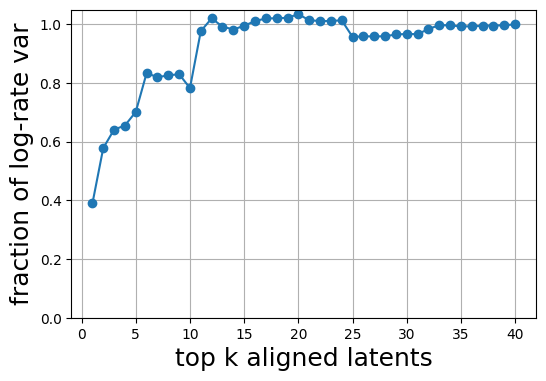

In [65]:
var_lograte = compute_cumulative_lograte_variance(U_full, V_full, z=z.mean(dim=0))
var_ratio = var_lograte / var_lograte[-1]

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(var_ratio)+1), var_ratio, marker='o')
plt.xlabel("top k aligned latents", fontsize=18)
plt.ylabel("fraction of log-rate var", fontsize=18)
#plt.title("Cumulative log-rate variance explained", fontsize=24)
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

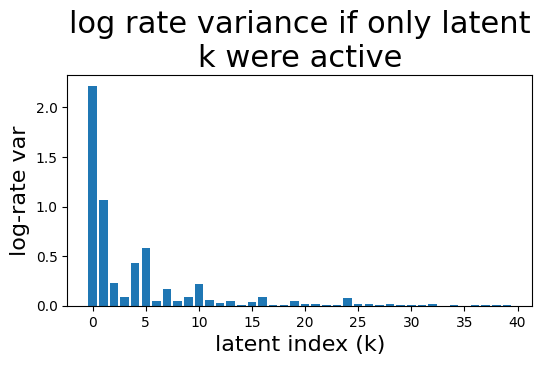

In [66]:
per_latent_var = compute_per_latent_variance(U_full, V_full, z.mean(dim=0)).numpy()

plt.figure(figsize=(6, 3))
plt.bar(range(len(per_latent_var)), per_latent_var, color='C0')
plt.xlabel("latent index (k)", fontsize=16)
plt.ylabel("log-rate var", fontsize=16)
plt.title("log rate variance if only latent\nk were active", fontsize=22)
plt.show()

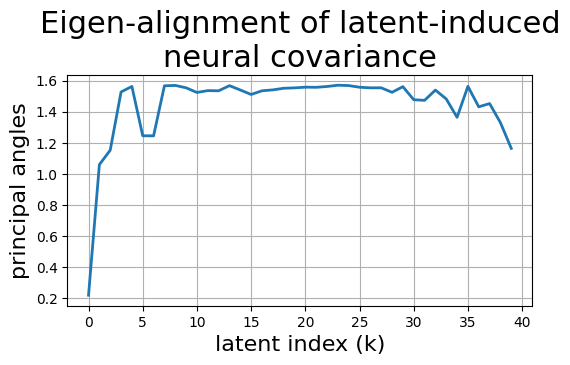

In [67]:
from scipy.linalg import subspace_angles

def neural_covariance(z, U, V):
    """
    z: [T, B, D]
    U: [N, K]
    V: [K, D]
    """
    T, B, D = z.shape
    zf = z.reshape(T*B, D)
    eta = zf @ V.T @ U.T          # [T*B, N]
    eta = eta - eta.mean(dim=0, keepdim=True)
    C = (eta.T @ eta) / eta.shape[0]
    
    return C

U_full = U_hist[max(U_hist.keys())]   # (n_neurons, n_latents)
V_full = V_hist[max(V_hist.keys())]   # (n_latents, n_latents)

C_eta = neural_covariance(z.mean(0), U_full, V_full)
eigvals, Q = torch.linalg.eigh(C_eta)
Q = Q[:, eigvals.argsort(descending=True)]

angles = []
for k in range(1, max(V_hist.keys())+1):
    
    ang = subspace_angles(U_full[:, :k].numpy(), Q[:, :k].numpy()).max()
    angles.append(ang)

plt.figure(figsize=(6, 3))
plt.plot(angles, linewidth=2)
plt.xlabel("latent index (k)", fontsize=16)
plt.ylabel("principal angles", fontsize=16)
plt.title("Eigen-alignment of latent-induced\nneural covariance", fontsize=22)
plt.grid(True)
plt.show()

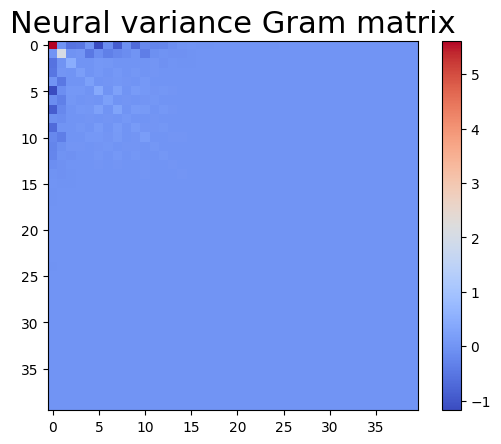

In [68]:
def neural_gram(z, U, V):
    T, B, D = z.shape
    zf = z.reshape(T*B, D)
    K = V.shape[0]

    comps = []
    for i in range(K):
        s = zf @ V[i]            # [T*B]
        eta_i = s[:, None] * U[:, i][None, :]
        comps.append(eta_i)

    comps = torch.stack(comps, dim=0)  # [K, T*B, N]
    comps = comps - comps.mean(dim=1, keepdim=True)

    G = torch.zeros(K, K)
    for i in range(K):
        for j in range(K):
            G[i, j] = (comps[i] * comps[j]).mean()
    return G

U_full = U_hist[max(U_hist.keys())]   # (n_neurons, n_latents)
V_full = V_hist[max(V_hist.keys())]   # (n_latents, n_latents)

G = neural_gram(z.mean(0), U_full, V_full)

plt.imshow(G.cpu(), cmap="coolwarm")
plt.colorbar()
plt.title("Neural variance Gram matrix", fontsize=22)
plt.show()

In [69]:
def reconstruct_rates_rrr(z, U, V, bias, delta):

    proj = torch.einsum("tbd,kd->tbk", z, V)
    eta = torch.einsum("tbk,nk->tbn", proj, U) + bias.view(1,1,-1)

    return delta * torch.exp(eta)

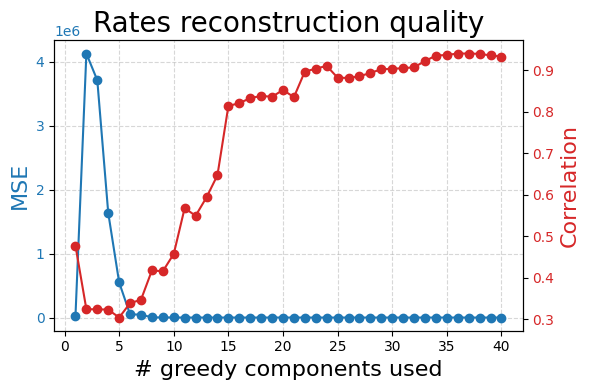

In [70]:
us_mses = []
us_corrs = []

with torch.no_grad():
    rate_hat = reconstruct_rates(delta, C, b, z.mean(dim=0))

    for k in V_hist.keys():
        rate_fit = reconstruct_rates_rrr(z.mean(dim=0), U_hist[k], V_hist[k], b_hist[k], delta)

        mse = ((rate_fit - rate_hat)**2).mean().item()
        corr = torch.corrcoef(torch.stack([rate_fit.flatten(), rate_hat.flatten()]))[0, 1].item()

        us_mses.append(mse)
        us_corrs.append(corr)

ks = list(V_hist.keys())

fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot MSE on left y-axis
color_mse = 'tab:blue'
ax1.plot(ks, us_mses, 'o-', color=color_mse)
ax1.set_xlabel('# greedy components used', fontsize=16)
ax1.set_ylabel('MSE', color=color_mse, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_mse)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Plot correlation on right y-axis
ax2 = ax1.twinx()
color_corr = 'tab:red'
ax2.plot(ks, us_corrs, 'o-', color=color_corr)
ax2.set_ylabel('Correlation', color=color_corr, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_corr)

# Optional: combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.title('Rates reconstruction quality', fontsize=20)
plt.tight_layout()
plt.show()

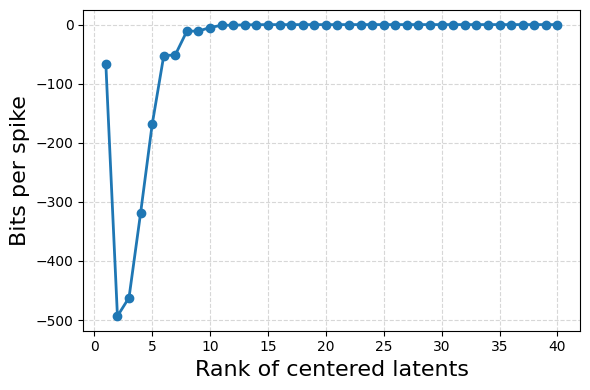

In [71]:
us_bps = []
ks = list(V_hist.keys())

eps = 1e-8  # for numerical stability

with torch.no_grad():

    for k in ks:
        rate_fit = reconstruct_rates_rrr(z.mean(dim=0), U_hist[k], V_hist[k], b_hist[k], delta)
        log_rate_fit = torch.log(rate_fit + eps)

        bps = prob_utils.bits_per_spike(log_rate_fit, y_train_obs).item()
        us_bps.append(bps)


fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ks, us_bps, 'o-', linewidth=2)
ax.set_xlabel('Rank of centered latents', fontsize=16)
ax.set_ylabel('Bits per spike', fontsize=16)

ax.grid(True, which='both', linestyle='--', alpha=0.5)
#ax.set_title('Rates reconstruction quality (BPS)', fontsize=20)

plt.tight_layout()
plt.show()

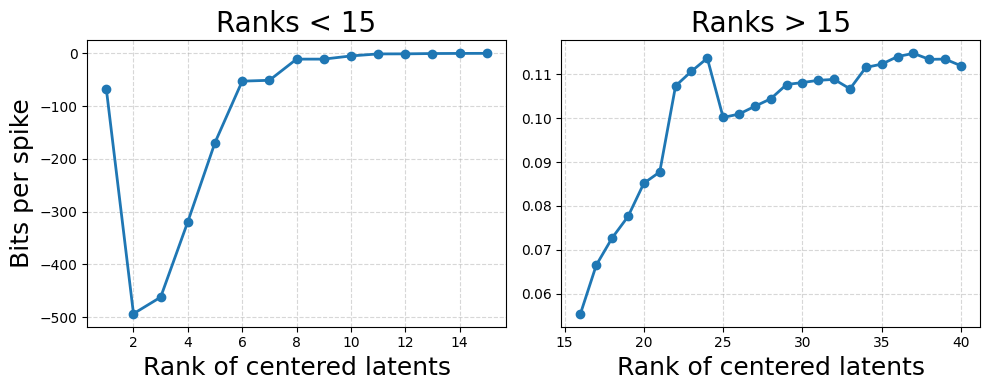

In [72]:
ks_arr = list(ks)
us_bps_arr = us_bps

# Split indices
left_mask = [k <= 15 for k in ks_arr]
right_mask = [k >= 16 for k in ks_arr]

ks_left = [k for k, m in zip(ks_arr, left_mask) if m]
bps_left = [b for b, m in zip(us_bps_arr, left_mask) if m]

ks_right = [k for k, m in zip(ks_arr, right_mask) if m]
bps_right = [b for b, m in zip(us_bps_arr, right_mask) if m]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 4), sharey=False
)

# Left plot: 0–15
ax1.plot(ks_left, bps_left, 'o-', linewidth=2)
ax1.set_xlabel('Rank of centered latents', fontsize=18)
ax1.set_ylabel('Bits per spike', fontsize=18)
ax1.set_title('Ranks < 15', fontsize=20)
ax1.grid(True, linestyle='--', alpha=0.5)

# Right plot: 16–end
ax2.plot(ks_right, bps_right, 'o-', linewidth=2)
ax2.set_xlabel('Rank of centered latents', fontsize=18)
ax2.set_title('Ranks > 15', fontsize=20)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
z_rrr = torch.einsum("tbd,dk->tbk", z.mean(dim=0), V_full)

r2_rates = decode_velocity_from_greedy_rates(
    z=z.mean(dim=0),
    vel=vel_train,
    U_history=U_hist,
    V_history=V_hist,
    bias_history=bias_hist,
    delta=cfg.bin_sz,
    alpha=0.01,
)

r2_latent = decode_velocity_from_latents(
    z_rot=z_rrr,
    vel=vel_train,
    alpha=0.01
)

ks = np.arange(1, len(r2_latent) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---- LEFT: decode directly from latents ----
axes[0].plot(ks, r2_latent, 'o-', linewidth=2)
axes[0].set_xlabel("# greedy components", fontsize=16)
axes[0].set_ylabel("R²", fontsize=16)
axes[0].set_title("Decode from greedy latents", fontsize=20)
axes[0].grid(True)

# ---- RIGHT: decode from generated rates ----
axes[1].plot(ks, r2_rates, 'o-', linewidth=2)
axes[1].set_xlabel("# greedy components", fontsize=16)
axes[1].set_title("Decode from generated rates", fontsize=20)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
us_bps

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

# z: (samples, trials, time, n_latents)
# y_train_obs: (trials, time, n_neurons)
# V: (n_latents, n_latents)
# delta: scalar bin size
device = "cuda:0"

# Rotate latents into aligned space
z_aligned = torch.einsum("tbd,dk->tbk", z.mean(dim=0).to(device), V.to(device))

class PoissonReadout(nn.Module):
    def __init__(self, n_neurons, n_latents, delta):
        super().__init__()
        self.C = nn.Parameter(0.01 * torch.randn(n_neurons, n_latents, device=device))
        self.bias = nn.Parameter(torch.zeros(n_neurons, device=device))
        self.delta = delta

    def forward(self, z):
        # z: (trials , time, latents)
        eta = torch.einsum("nd,tbd->tbn", self.C, z) + self.bias
        return self.delta * torch.exp(eta)

def fit_poisson_readout(model, z, y, lr=1e-2, n_steps=2000):
    model = model.to(device)
    z = z.to(device)
    y = y.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in tqdm(range(n_steps)):
        opt.zero_grad()
        rate = model(z)
        loss = (rate - y * torch.log(rate + 1e-8)).mean()
        loss.backward()
        opt.step()

    return model

# Instantiate and fit
poisson_readout = PoissonReadout(n_neurons=y_train_obs.shape[-1],
                                 n_latents=V.shape[0],
                                 delta=delta)

poisson_readout = fit_poisson_readout(poisson_readout, z_aligned, y_train_obs)

In [ ]:
C_bar = poisson_readout.C

plt.imshow(C_bar, aspect=0.4)

In [ ]:
with torch.no_grad():
    rate_refit = poisson_readout(z_aligned.to(device))

    mse = ((rate_refit - reconstruct_rates(delta, C, b, z.mean(dim=0)).to(device))**2).mean().item()
    corr = torch.corrcoef(torch.stack([rate_refit.flatten(), y_train_obs.to(device).flatten()]))[0, 1].item()

print(f"MSE between refitted rates and true spikes: {mse:.4f}")
print(f"Correlation between refitted rates and true spikes: {corr:.4f}")

In [ ]:
with torch.no_grad():
    rate_refit = poisson_readout(z_aligned.to(device))

    # Convert to CPU for numpy operations
    rate_np = rate_refit.cpu().numpy()
    y_np = y_train_obs.cpu().numpy()

    # Per-neuron correlation
    neuron_corrs = [np.corrcoef(rate_np[..., i].flatten(), y_np[..., i].flatten())[0,1]
                    for i in range(y_np.shape[-1])]

    print(f"Mean correlation across neurons: {np.mean(neuron_corrs):.4f}")

In [ ]:
import torch.nn.functional as F

# ------------------------------------------------------------
# Fisher-based latent rotation (your method, cleaned up)
# ------------------------------------------------------------
def get_latent_rotation_from_C(C, R):
    """
    C: (neurons, latents)
    R: (neurons,) mean rates (delta * exp(bias))
    """
    C_scaled = C / R.unsqueeze(-1).sqrt()
    U, S, Vh = torch.linalg.svd(C_scaled, full_matrices=False)
    return U, S, Vh


def rotate_z(z, Vh):
    """
    z: (..., latents)
    Vh: (latents, latents)
    """
    return torch.einsum('...d,df->...f', z, Vh.T)


def rotate_C(U, R):
    """
    U: (neurons, latents)
    R: (neurons,)
    """
    return R.unsqueeze(-1).sqrt() * U


# ------------------------------------------------------------
# 1) Extract quantities from trained model
# ------------------------------------------------------------
likelihood_pdf, readout_fn = get_ll_pdf_readouf_fn(seq_vae.ssm)

C = readout_fn.weight.detach().cpu()             # (neurons, latents)
b = readout_fn.bias.detach().cpu()
delta = likelihood_pdf.delta
R = (delta * torch.exp(b)).cpu()                 # mean rates

z = z_s_train[:, :, :, :cfg.n_latents_read].detach().cpu()

# ------------------------------------------------------------
# 2) First Fisher rotation
# ------------------------------------------------------------
U1, S1, Vh1 = get_latent_rotation_from_C(C, R)

z_rot1 = rotate_z(z, Vh1)
C_rot1 = rotate_C(U1, R)

# ------------------------------------------------------------
# 3) Second Fisher rotation (apply again!)
# ------------------------------------------------------------
U2, S2, Vh2 = get_latent_rotation_from_C(C_rot1, R)

z_rot2 = rotate_z(z_rot1, Vh2)
C_rot2 = rotate_C(U2, R)

# ------------------------------------------------------------
# 4) Plot C, C_rot1, C_rot2 side by side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(10, 6), sharey=True)

vmax = torch.max(torch.abs(C)).item()

axes[0].imshow(C, aspect='auto', cmap='bwr',
               vmin=-vmax, vmax=vmax)
axes[0].set_title("Original C", fontsize=18)
axes[0].set_xlabel("Latent")
axes[0].set_ylabel("Neuron")

axes[1].imshow(C_rot1, aspect='auto', cmap='bwr',
               vmin=-vmax, vmax=vmax)
axes[1].set_title("After 1st Fisher rotation", fontsize=18)
axes[1].set_xlabel("Latent")

axes[2].imshow(C_rot2, aspect='auto', cmap='bwr',
               vmin=-vmax, vmax=vmax)
axes[2].set_title("After 2nd Fisher rotation", fontsize=18)
axes[2].set_xlabel("Latent")

plt.suptitle(
    "Fisher-based latent canonicalization\n"
    "Second application should not change C",
    fontsize=20
)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# ------------------------------------------------------------
# 5) Quantitative sanity check
# ------------------------------------------------------------
diff = torch.norm(C_rot2 - C_rot1) / torch.norm(C_rot1)
print(f"Relative change after second rotation: {diff:.3e}")

In [ ]:
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Original Fisher
# I_bar = C^T diag(R) C
# -----------------------------
I_orig = C.T @ torch.diag(R) @ C

# -----------------------------
# Rotated loadings (your method)
# C_rot = sqrt(R) * U
# -----------------------------
C_rot = R.unsqueeze(-1).sqrt() * U

# -----------------------------
# Rotated Fisher
# I_rot = C_rot^T C_rot
# -----------------------------
I_rot = C_rot.T @ C_rot

# Normalize for visualization
I_orig_n = I_orig / I_orig.abs().max()
I_rot_n  = I_rot  / I_rot.abs().max()

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original Fisher
im0 = axes[0].imshow(I_orig_n.detach().numpy(), cmap="bwr", interpolation="none")
axes[0].set_title("Original Fisher\n$C^T\\mathrm{diag}(\\bar\\lambda)C$", fontsize=16)
axes[0].set_xlabel("Latent")
axes[0].set_ylabel("Latent")
plt.colorbar(im0, ax=axes[0])

# Rotated Fisher
im1 = axes[1].imshow(I_rot_n.detach().numpy(), cmap="bwr", interpolation="none")
axes[1].set_title("Rotated Fisher\n$C_{rot}^T C_{rot}$", fontsize=16)
axes[1].set_xlabel("Latent")
axes[1].set_ylabel("Latent")
plt.colorbar(im1, ax=axes[1])

# Diagonal of rotated Fisher
axes[2].plot(torch.diag(I_rot).detach().numpy(), marker="o")
axes[2].set_title("Diagonal of rotated Fisher\n($= S^2$)", fontsize=16)
axes[2].set_xlabel("Latent")
axes[2].set_ylabel("Fisher")
axes[2].grid(True)

plt.suptitle(
    "Fisher information is diagonalized by latent rotation\n(second rotation ≈ identity)",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Step 0: Original Fisher
# -----------------------------
I_orig = C.T @ torch.diag(R) @ C

# -----------------------------
# Step 1: First rotation (your method)
# -----------------------------
C_rot1 = R.unsqueeze(-1).sqrt() * U
I_rot1 = C_rot1.T @ C_rot1

# -----------------------------
# Step 2: Second rotation
# Apply get_latent_rotation again to C_rot1
# -----------------------------
# Decompose I_rot1
U2, S2, Vh2 = torch.linalg.svd(C_rot1, full_matrices=False)
C_rot2 = S2.unsqueeze(-1) * Vh2  # second rotation
I_rot2 = C_rot2.T @ C_rot2       # should be almost diagonal / identity

# -----------------------------
# Normalize for visualization
# -----------------------------
I_orig_n = I_orig / I_orig.abs().max()
I_rot1_n = I_rot1 / I_rot1.abs().max()
I_rot2_n = I_rot2 / I_rot2.abs().max()

# -----------------------------
# Plot all 3
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original Fisher
im0 = axes[0].imshow(I_orig_n.detach().numpy(), cmap="bwr", interpolation="none")
axes[0].set_title("Original Fisher\n$C^T diag(R) C$", fontsize=16)
axes[0].set_xlabel("Latent", fontsize=12)
axes[0].set_ylabel("Latent", fontsize=12)
plt.colorbar(im0, ax=axes[0])

# First rotation Fisher
im1 = axes[1].imshow(I_rot1_n.detach().numpy(), cmap="bwr", interpolation="none")
axes[1].set_title("First rotation\n$C_{rot}^T C_{rot}$", fontsize=16)
axes[1].set_xlabel("Latent", fontsize=12)
axes[1].set_ylabel("Latent", fontsize=12)
plt.colorbar(im1, ax=axes[1])

# Second rotation Fisher (diagonalized)
im2 = axes[2].imshow(I_rot2_n.detach().numpy(), cmap="bwr", interpolation="none")
axes[2].set_title("Second rotation\n$C_{rot2}^T C_{rot2}$ (≈ Identity)", fontsize=16)
axes[2].set_xlabel("Latent", fontsize=12)
axes[2].set_ylabel("Latent", fontsize=12)
plt.colorbar(im2, ax=axes[2])

plt.suptitle(
    "Fisher information through latent rotations\nOriginal → Rotated → Second rotation ≈ Identity\n\n",
    fontsize=18
)
plt.tight_layout()
plt.show()

In [ ]:
latent_contribs_orig = compute_latent_variance_contribution(C, z)
latent_contribs_rot = compute_latent_variance_contribution(C_rot, z_rot)

var_explained_orig = latent_contribs_orig / latent_contribs_orig.sum()
var_explained_rot = latent_contribs_rot / latent_contribs_rot.sum()

cum_var_explained_orig = var_explained_orig.cumsum(dim=0).numpy()
cum_var_explained_rot = var_explained_rot.cumsum(dim=0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle("Variance ratio in C@Z (unbiaseed log rates)\nexplained by each latent", fontsize=26)

# --- Original ---
axes[0].bar(np.arange(len(latent_contribs_orig)), latent_contribs_orig)
axes[0].set_xlabel("Latent dimension", fontsize=16)
axes[0].set_ylabel("Variance ratio", fontsize=16)
axes[0].set_title("Original", fontsize=24)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# --- Rotated ---
axes[1].bar(np.arange(len(latent_contribs_rot)), latent_contribs_rot, color="coral")
axes[1].set_xlabel("Latent dimension", fontsize=16)
axes[1].set_title("Rotated", fontsize=24)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# --- Cumulative variance explained ---
axes[2].plot(cum_var_explained_orig, label="original", marker="o", markersize=5)
axes[2].plot(cum_var_explained_rot, label="rotated", marker="o", markersize=5)
axes[2].set_xlabel("Latent dimension", fontsize=16)
axes[2].set_ylabel("Cumulative VE", fontsize=16)
axes[2].set_title("Cumulative", fontsize=24)
axes[2].grid(True)
axes[2].legend(fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
def axis_level_fisher(C, R):
    return (C**2 * R.unsqueeze(1)).sum(dim=0)

In [ ]:
axis_info_orig = axis_level_fisher(C, R)
axis_info_rot  = S**2

axis_info_orig_norm = axis_info_orig / axis_info_orig.sum()
axis_info_rot_norm  = axis_info_rot / axis_info_rot.sum()
cum_orig = torch.cumsum(axis_info_orig_norm, dim=0)
cum_rot  = torch.cumsum(axis_info_rot_norm, dim=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle("Axis-level Fisher information per latent", fontsize=28)

# --- Original ---
axes[0].bar(np.arange(len(axis_info_orig_norm)), axis_info_orig_norm.detach().numpy())
axes[0].set_xlabel("Latent dimension", fontsize=18)
axes[0].set_ylabel("Fraction of total Fisher", fontsize=18)
axes[0].set_title("Original", fontsize=24)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# --- Rotated ---
axes[1].bar(np.arange(len(axis_info_rot_norm)), axis_info_rot_norm.detach().numpy(), color="coral")
axes[1].set_xlabel("Latent dimension", fontsize=18)
axes[1].set_title("Rotated", fontsize=24)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# --- Cumulative ---
axes[2].plot(cum_orig.detach().numpy(), label="Original", marker="o", markersize=5)
axes[2].plot(cum_rot.detach().numpy(), label="Rotated", marker="o", markersize=5)
axes[2].set_xlabel("Latent dimension", fontsize=18)
axes[2].set_ylabel("Cumulative Fisher fraction", fontsize=18)
axes[2].set_title("Cumulative", fontsize=24)
axes[2].grid(True)
axes[2].legend(fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# --- Rotated latents ---
z_flat_rot = z_rot.mean(dim=0).reshape(-1, z_rot.shape[-1])
marginal_var_rot = z_flat_rot.var(dim=0, unbiased=True)

axes[0].bar(np.arange(len(marginal_var_rot)), marginal_var_rot)
axes[0].set_xlabel("Latent", fontsize=16)
axes[0].set_ylabel("Marginal variance ", fontsize=16)
axes[0].set_title("Rotated", fontsize=20)

# --- Original latents ---
z_flat = z.mean(dim=0).reshape(-1, z.shape[-1])
marginal_var = z_flat.var(dim=0, unbiased=True)

axes[1].bar(np.arange(len(marginal_var)), marginal_var)
axes[1].set_xlabel("Latent ", fontsize=16)
axes[1].set_title("Original", fontsize=20)

fig.suptitle("Marginal variance of each\nlatent dimension", fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
var_frac_rot = marginal_var_rot / marginal_var_rot.sum()
var_frac_orig = marginal_var / marginal_var.sum()

cum_var_rot = torch.cumsum(var_frac_rot, dim=0)
cum_var_orig = torch.cumsum(var_frac_orig, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# --- Rotated latents ---
axes[0].bar(np.arange(len(var_frac_rot)), var_frac_rot.numpy())
axes[0].set_xlabel("Latent", fontsize=16)
axes[0].set_ylabel("Fraction of total variance", fontsize=16)
axes[0].set_title("Rotated", fontsize=20)

# --- Original latents ---
axes[1].bar(np.arange(len(var_frac_orig)), var_frac_orig.numpy())
axes[1].set_xlabel("Latent", fontsize=16)
axes[1].set_title("Original", fontsize=20)

fig.suptitle("Marginal variance fraction of each latent dimension", fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
    # ----- Latents (original + rotated)
z_orig_train = z_s_train[:, :, :, :cfg.n_latents_read].detach().cpu()
z_orig_test  = z_s_test[:, :, :, :cfg.n_latents_read].detach().cpu()

z_rot_train = torch.einsum('stbd,df->stbf', z_orig_train, rotation_matrix.T).cpu()
z_rot_test  = torch.einsum('stbd,df->stbf', z_orig_test, rotation_matrix.T).cpu()

r2_scores_orig = n_latents_vs_r2_latents(z_orig_train.mean(dim=0), z_orig_test.mean(dim=0), vel_train, vel_test)
r2_scores_rot  = n_latents_vs_r2_latents(z_rot_train.mean(dim=0),  z_rot_test.mean(dim=0),  vel_train, vel_test)

# ----- Rates (generated from latents)
r2_scores_rates_orig = n_latents_vs_r2_rates(z_orig_train, z_orig_test, vel_train, vel_test, C, b, delta)
r2_scores_rates_rot  = n_latents_vs_r2_rates(z_rot_train,  z_rot_test,  vel_train, vel_test, C_rot, b, delta)

# ----- Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Left: Latents
axes[0].plot(np.arange(1, len(r2_scores_rates_orig)+1), r2_scores_orig, marker='o', label="original latents")
axes[0].plot(np.arange(1, len(r2_scores_rates_orig)+1),  r2_scores_rot,  marker='o', label="rotated latents")
axes[0].set_xlabel("# latents used", fontsize=16)
axes[0].set_ylabel("$R^2$", fontsize=16)
axes[0].set_title("Decoding from Latent\nfactors", fontsize=22)
axes[0].legend(fontsize=12)
axes[0].grid(True)

# Right: Rates
axes[1].plot(np.arange(1, len(r2_scores_rates_orig)+1), r2_scores_rates_orig, marker='o', label="from original latents")
axes[1].plot(np.arange(1, len(r2_scores_rates_rot)+1),  r2_scores_rates_rot,  marker='o', label="from rotated latents")
axes[1].set_xlabel("# latents used", fontsize=16)
axes[1].set_title("Decoding from generated\nrates", fontsize=22)
axes[1].legend(fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Mean across samples if present (keep trials × time × latents)
z_orig_mean = z_orig_train.mean(dim=0)   # (trials, time, latents)
z_rot_mean  = z_rot_train.mean(dim=0)

# Flatten trials × time for CCA
z_orig_flat = z_orig_mean.reshape(-1, z_orig_mean.shape[-1]).numpy()
z_rot_flat  = z_rot_mean.reshape(-1,  z_rot_mean.shape[-1]).numpy()

vel_flat = vel_train.reshape(-1, vel_train.shape[-1]).numpy()

# CCA for ORIGINAL latents
cca_orig, corr_orig, z_can_orig, vel_can_orig = apply_cca(z_orig_flat, vel_flat)
z_w_orig = torch.from_numpy(cca_orig.x_weights_).float()

# CCA for ROTATED latents
cca_rot, corr_rot, z_can_rot, vel_can_rot = apply_cca(z_rot_flat, vel_flat)
z_w_rot = torch.from_numpy(cca_rot.x_weights_).float()

cca_axis = 0

order_orig = torch.argsort(torch.abs(z_w_orig[:, cca_axis]), descending=True)
order_rot  = torch.argsort(torch.abs(z_w_rot[:,  cca_axis]), descending=True)

z_orig_train_ord = z_orig_train[..., order_orig]
z_orig_test_ord  = z_orig_test[...,  order_orig]

z_rot_train_ord  = z_rot_train[..., order_rot]
z_rot_test_ord   = z_rot_test[...,  order_rot]

z_orig_train_ord = z_orig_train[..., order_orig]
z_orig_test_ord  = z_orig_test[...,  order_orig]

z_rot_train_ord  = z_rot_train[..., order_rot]
z_rot_test_ord   = z_rot_test[...,  order_rot]

# ----- Latents
r2_scores_orig = n_latents_vs_r2_latents(
    z_orig_train_ord.mean(dim=0),
    z_orig_test_ord.mean(dim=0),
    vel_train, vel_test
)

r2_scores_rot = n_latents_vs_r2_latents(
    z_rot_train_ord.mean(dim=0),
    z_rot_test_ord.mean(dim=0),
    vel_train, vel_test
)

# ----- Rates
r2_scores_rates_orig = n_latents_vs_r2_rates(
    z_orig_train_ord, z_orig_test_ord,
    vel_train, vel_test, C, b, delta
)

r2_scores_rates_rot = n_latents_vs_r2_rates(
    z_rot_train_ord, z_rot_test_ord,
    vel_train, vel_test, C_rot, b, delta
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(np.arange(1, len(r2_scores_orig)+1), r2_scores_orig,
             marker='o', label="original (CCA-ordered)")
axes[0].plot(np.arange(1, len(r2_scores_rot)+1),  r2_scores_rot,
             marker='o', label="rotated (CCA-ordered)")
axes[0].set_xlabel("# latents used", fontsize=16)
axes[0].set_ylabel("$R^2$", fontsize=16)
axes[0].set_title("Decoding from Latents\n", fontsize=22)
axes[0].legend(fontsize=12)
axes[0].grid(True)

axes[1].plot(np.arange(1, len(r2_scores_rates_orig)+1), r2_scores_rates_orig,
             marker='o', label="from original rates")
axes[1].plot(np.arange(1, len(r2_scores_rates_rot)+1),  r2_scores_rates_rot,
             marker='o', label="from rotated rates")
axes[1].set_xlabel("# latents used", fontsize=16)
axes[1].set_title("Decoding from Rates\n", fontsize=22)
axes[1].legend(fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np

# -------------------
# 1. Generate model
# -------------------
N = 50       # neurons
T = 1000     # time points
d_true = 5   # true latent dimensionality
delta = 0.02 # bin width

# Ground-truth latents
z = torch.randn(T, d_true)  # (time, latents)

# Ground-truth readout
C = torch.randn(N, d_true) * 1.0
b = torch.randn(N) * 0.1

# Compute rates
log_lambda = b.unsqueeze(0) + z @ C.T
lambda_t = delta * torch.exp(log_lambda)

# Generate Poisson spikes
y = torch.poisson(lambda_t)

# -------------------
# 2. Fisher analysis
# -------------------
lambda_bar = lambda_t.mean(dim=0)
C_scaled = C * lambda_bar.sqrt().unsqueeze(1)

# Time-averaged Fisher
I = C_scaled.T @ C_scaled

# SVD
U, S, Vh = torch.linalg.svd(C_scaled, full_matrices=False)

# Axis-level Fisher
axis_fisher = S**2
axis_fisher_frac = axis_fisher / axis_fisher.sum()
cum_fisher = torch.cumsum(axis_fisher_frac, dim=0)

print("Singular values squared (axis-level Fisher):", axis_fisher)
print("Cumulative fraction:", cum_fisher)

In [ ]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(123)

# -------------------
# Parameters
# -------------------
N = 100          # neurons
n_trials = 2000  # trials
T = 50          # time bins
d_full = 20     # total latent dimensions
d_true = 5      # informative latent subspace
delta = 0.02    # bin width

# -------------------
# Step 1: Generate full latent space (standard normal)
# -------------------
z_full = torch.randn(n_trials, T, d_full)  # (trials, time, latents)

# -------------------
# Step 2: Generate low-rank readout (signal)
# -------------------
C_lowrank = torch.randn(N, d_true)  # strong weights for true subspace

# -------------------
# Step 3: Embed low-D subspace into full latent space via random rotation
# -------------------
Q = torch.randn(d_full, d_true)    # random rotation
Q, _ = torch.linalg.qr(Q)          # orthonormal columns, shape (d_full, d_true)
C_full = C_lowrank @ Q.T           # (N, d_full) fully mixes signal across all latent axes

# Bias
b = torch.randn(N) * 0.05

# -------------------
# Step 4: Generate Poisson spikes
# -------------------
log_lambda = torch.einsum('...d,nd->...n', z_full, C_full) + b.unsqueeze(0).unsqueeze(0)
lambda_t = delta * torch.exp(log_lambda)
y = torch.poisson(lambda_t)  # (trials, time, neurons)

# -------------------
# Step 5: Compute axis-level Fisher (time-averaged)
# -------------------
lambda_bar = lambda_t.mean(dim=(0,1))  # average over trials and time → (neurons,)
C_scaled = C_full * lambda_bar.sqrt().unsqueeze(1)  # scale readout

# SVD
U, S, Vh = torch.linalg.svd(C_scaled, full_matrices=False)

# Axis-level Fisher
axis_fisher = S**2
axis_fisher_frac = axis_fisher / axis_fisher.sum()
cum_fisher = torch.cumsum(axis_fisher_frac, dim=0)

# -------------------
# Step 6: Plot results
# -------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Axis-level Fisher
axes[0].bar(range(d_full), axis_fisher, color='steelblue')
axes[0].set_xlabel('Latent axis', fontsize=14)
axes[0].set_ylabel('Axis-level Fisher (S^2)', fontsize=14)
axes[0].set_title('Axis-level Fisher per latent', fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Cumulative Fisher fraction
axes[1].plot(cum_fisher.numpy(), marker='o', color='coral', label='Cumulative Fisher')
axes[1].axhline(0.8, color='gray', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Number of axes', fontsize=14)
axes[1].set_ylabel('Cumulative fraction', fontsize=14)
axes[1].set_title('Cumulative Fisher fraction', fontsize=16)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=12)

plt.suptitle(f"Hard Validation: {d_true}-D signal hidden in {d_full}-D latent space", fontsize=18)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

# ============================
# Parameters
# ============================
N = 200          # neurons
T = 100          # time bins
n_trials = 1000
d_full = 20      # latent dimensionality
d_true = 5       # true task dimensionality
delta = 0.02     # bin width

# ============================
# 1. Generate structured low-D latents
# ============================
z_task = torch.randn(n_trials, T, d_true)
z_noise = 0.1 * torch.randn(n_trials, T, d_full - d_true)
z_full = torch.cat([z_task, z_noise], dim=-1)  # (trials, time, d_full)

# ============================
# 2. Hide structure with rotation
# ============================
Q, _ = torch.linalg.qr(torch.randn(d_full, d_full))
z_rot = torch.einsum('btd,df->btf', z_full, Q)

# ============================
# 3. Structured readout (only first d_true matter)
# ============================
C_task = torch.randn(N, d_true)
C_noise = 0.05 * torch.randn(N, d_full - d_true)
C_full = torch.cat([C_task, C_noise], dim=1)
C_rot = C_full @ Q.T

b = torch.randn(N) * 0.05

# ============================
# 4. Generate Poisson spikes
# ============================
log_lambda = torch.einsum('btd,nd->btn', z_rot, C_rot) + b
lambda_t = delta * torch.exp(log_lambda)
y = torch.poisson(lambda_t)

# ============================
# 5. Compute Fisher-scaled C
# ============================
lambda_bar = lambda_t.mean(dim=(0, 1))          # (neurons,)
C_scaled = C_rot * lambda_bar.sqrt().unsqueeze(1)

# SVD
U, S, Vh = torch.linalg.svd(C_scaled, full_matrices=False)
axis_fisher_rot = S**2

# ============================
# 6. Marginal variance
# ============================
z_flat_orig = z_full.reshape(-1, d_full)
z_flat_rot  = z_rot.reshape(-1, d_full)

marg_var_orig = z_flat_orig.var(dim=0, unbiased=True)
marg_var_rot  = z_flat_rot.var(dim=0, unbiased=True)

# ============================
# 7. Cumulative Fisher
# ============================
axis_fisher_frac = axis_fisher_rot / axis_fisher_rot.sum()
cum_fisher = torch.cumsum(axis_fisher_frac, dim=0)

# ============================
# 8. Plot: 1 × 4
# ============================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# --- Original marginal variance
axes[0].bar(range(d_full), marg_var_orig)
axes[0].set_title("Original latents\nMarginal variance", fontsize=14)
axes[0].set_xlabel("Latent")
axes[0].set_ylabel("Variance")
axes[0].grid(True, linestyle="--", alpha=0.4)

# --- Rotated marginal variance
axes[1].bar(range(d_full), marg_var_rot, color="coral")
axes[1].set_title("Rotated latents\nMarginal variance", fontsize=14)
axes[1].set_xlabel("Latent")
axes[1].grid(True, linestyle="--", alpha=0.4)

# --- Fisher per latent
axes[2].bar(range(d_full), axis_fisher_rot, color="seagreen")
axes[2].set_title("Rotated latents\nAxis-level Fisher", fontsize=14)
axes[2].set_xlabel("Latent")
axes[2].set_ylabel("Fisher")
axes[2].grid(True, linestyle="--", alpha=0.4)

# --- Cumulative Fisher
axes[3].plot(cum_fisher.numpy(), marker="o", color="black")
axes[3].axhline(0.8, linestyle="--", color="gray")
axes[3].set_title("Cumulative Fisher", fontsize=14)
axes[3].set_xlabel("# latents")
axes[3].set_ylabel("Fraction")
axes[3].set_ylim(0, 1.05)
axes[3].grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    f"Low-D task structure (d={d_true}) hidden in {d_full}D latent space\n"
    "Rotation destroys variance but Fisher recovers effective dimensionality",
    fontsize=18
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Generate corresponding observations

In [ ]:
likelihood_pdf, readout_fn = get_ll_pdf_readouf_fn(seq_vae.ssm)
rotation_matrix, S, U = get_rotation_matrix(likelihood_pdf)

C = readout_fn.weight.detach().cpu()
R = likelihood_pdf.delta * torch.exp(readout_fn.bias).cpu()
b = readout_fn.bias.detach().cpu()
delta = cfg.bin_sz

C_rot = rotate_c(R, U)

In [ ]:
z_f_train = rotate_z(z_f_train, rotation_matrix)
z_s_train = rotate_z(z_s_train, rotation_matrix)
z_p_train = rotate_z(z_p_train, rotation_matrix)

z_f_valid = rotate_z(z_f_valid, rotation_matrix)
z_s_valid = rotate_z(z_s_valid, rotation_matrix)
z_p_valid = rotate_z(z_p_valid, rotation_matrix)

z_f_test = rotate_z(z_f_test, rotation_matrix)
z_s_test = rotate_z(z_s_test, rotation_matrix)
z_p_test = rotate_z(z_p_test, rotation_matrix)

In [ ]:
rate_hat_train_f = reconstruct_rates(delta, C_rot, b, z_f_train)
rate_hat_train_s = reconstruct_rates(delta, C_rot, b, z_s_train)
rate_hat_train_p = reconstruct_rates(delta, C_rot, b, z_p_train)

rate_hat_valid_f = reconstruct_rates(delta, C_rot, b, z_f_valid)
rate_hat_valid_s = reconstruct_rates(delta, C_rot, b, z_s_valid)
rate_hat_valid_p = reconstruct_rates(delta, C_rot, b, z_p_valid)

rate_hat_test_f = reconstruct_rates(delta, C_rot, b, z_f_test)
rate_hat_test_s = reconstruct_rates(delta, C_rot, b, z_s_test)
rate_hat_test_p = reconstruct_rates(delta, C_rot, b, z_p_test)

# Instantaneous velocity decoder

In [ ]:
on_residuals = False
on_cond_avg = False
on_move_exec = False

(clf,
 vel_hat_train_f, vel_hat_valid_f, vel_hat_test_f,
 vel_hat_train_s, vel_hat_valid_s, vel_hat_test_s,
 vel_hat_train_p, vel_hat_valid_p, vel_hat_test_p,
 r2_train_enc_f, r2_valid_enc_f, r2_test_enc_f,
 r2_train_enc_s, r2_valid_enc_s, r2_test_enc_s,
 r2_train_enc_p, r2_valid_enc_p, r2_test_enc_p) = inst_velocity_decoder(cfg,
                                                                        rate_hat_train_f, rate_hat_valid_f, rate_hat_test_f,
                                                                        rate_hat_train_s, rate_hat_valid_s, rate_hat_test_s,
                                                                        rate_hat_train_p, rate_hat_valid_p, rate_hat_test_p,
                                                                        vel_train, vel_valid, vel_test,
                                                                        conds_train, conds_valid, conds_test,
                                                                        on_residuals=on_residuals)

print('using smoothed latents (train/valid/test):\n', r2_train_enc_s, r2_valid_enc_s, r2_test_enc_s)
print('using filtered latents (train/valid/test):\n', r2_train_enc_f, r2_valid_enc_f, r2_test_enc_f)
print('using forecasted latents (train/valid/test):\n', r2_train_enc_p, r2_valid_enc_p, r2_test_enc_p)

In [ ]:
(clf_z,
 vel_hat_train_f_z, vel_hat_valid_f_z, vel_hat_test_f_z,
 vel_hat_train_s_z, vel_hat_valid_s_z, vel_hat_test_s_z,
 vel_hat_train_p_z, vel_hat_valid_p_z, vel_hat_test_p_z,
 r2_train_enc_f_z, r2_valid_enc_f_z, r2_test_enc_f_z,
 r2_train_enc_s_z, r2_valid_enc_s_z, r2_test_enc_s_z,
 r2_train_enc_p_z, r2_valid_enc_p_z, r2_test_enc_p_z) = inst_velocity_decoder(cfg,
                                                                              z_f_train.mean(dim=0), z_f_valid.mean(dim=0), z_f_test.mean(dim=0),
                                                                              z_s_train.mean(dim=0), z_s_valid.mean(dim=0), z_s_test.mean(dim=0),
                                                                              z_p_train.mean(dim=0), z_p_valid.mean(dim=0), z_p_test.mean(dim=0),
                                                                              vel_train, vel_valid, vel_test,
                                                                              conds_train, conds_valid,conds_test,
                                                                              on_residuals=on_residuals)

print('using smoothed latents (train/valid/test):\n', r2_train_enc_s_z, r2_valid_enc_s_z, r2_test_enc_s_z)
print('using filtered latents (train/valid/test):\n', r2_train_enc_f_z, r2_valid_enc_f_z, r2_test_enc_f_z)
print('using forecasted latents (train/valid/test):\n', r2_train_enc_p_z, r2_valid_enc_p_z, r2_test_enc_p_z)

In [ ]:
pos_train = vel_to_pos(vel_train)
pos_test = vel_to_pos(vel_test)

pos_train_hat_f = vel_to_pos(vel_hat_train_f)
pos_train_hat_s = vel_to_pos(vel_hat_train_s)
pos_train_hat_p = vel_to_pos(vel_hat_train_p)

pos_test_hat_f = vel_to_pos(vel_hat_test_f)
pos_test_hat_s = vel_to_pos(vel_hat_test_s)
pos_test_hat_p = vel_to_pos(vel_hat_test_p)

In [ ]:
plot_reaching(pos_train,
              pos_train_hat_s, r2_train_enc_s,
              pos_train_hat_f, r2_train_enc_f,
              pos_train_hat_p, r2_train_enc_p,
              n_trials_to_plot=120)

In [ ]:
plot_reaching(pos_test,
              pos_test_hat_s, r2_test_enc_s,
              pos_test_hat_f, r2_test_enc_f,
              pos_test_hat_p, r2_test_enc_p,
              n_trials_to_plot=120)

# Canonical correlation analysis

In [ ]:
def get_cond_avg_vel(vel_train, vel_valid, vel_test, cond_train, cond_valid,  cond_test):

    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    vt = to_numpy(vel_train)
    vv = to_numpy(vel_valid)
    vte = to_numpy(vel_test)

    ct = to_numpy(cond_train)
    cv = to_numpy(cond_valid)
    cte = to_numpy(cond_test)

    # ---------- compute condition mean from TRAIN ----------
    cond_mean = {}
    for c in np.unique(ct):
        cond_mean[c] = vt[ct == c].mean(axis=0)  # (T, 2)

    # ---------- apply ----------
    def apply(cond):
        out = np.empty((cond.shape[0],) + cond_mean[next(iter(cond_mean))].shape,
                       dtype=vt.dtype)
        for i, c in enumerate(cond):
            out[i] = cond_mean[c]
        return out

    out_train = torch.as_tensor(apply(ct))
    out_valid = torch.as_tensor(apply(cv))
    out_test  = torch.as_tensor(apply(cte))
    
    return out_train, out_valid, out_test

In [ ]:
lat_train, lat_val, lat_test = z_s_train.mean(dim=0).cpu().numpy(), z_s_valid.mean(dim=0).cpu().numpy(), z_s_test.mean(dim=0).cpu().numpy()

if on_residuals:
    v_train, v_val, v_test = residualize_velocity(
        vel_train, vel_valid, vel_test,
        reach_conds[train_dx], reach_conds[valid_dx], reach_conds[test_dx])

elif on_cond_avg:
    v_train, v_val, v_test = get_cond_avg_vel(
        vel_train, vel_valid, vel_test,
        reach_conds[train_dx], reach_conds[valid_dx], reach_conds[test_dx])

elif on_move_exec:
    lat_train, lat_val, lat_test = lat_train[:, event_bin_wrt_vel:, :], lat_val[:, event_bin_wrt_vel:, :], lat_test[:, event_bin_wrt_vel:, :]
    v_train, v_val, v_test = vel_train[:, event_bin_wrt_vel:, :], vel_valid[:, event_bin_wrt_vel:, :], vel_test[:, event_bin_wrt_vel:, :]

else:
    v_train, v_val, v_test = vel_train, vel_valid, vel_test

In [ ]:
cca, corr, z_can, vel_can = apply_cca(lat_train, v_train)
z_w = cca.x_weights_

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.scatter(z_can[:, 0], vel_can[:, 0], s=5, alpha=0.1)
plt.xlabel(f'Latents', fontsize=16)
plt.ylabel(f'Behavior', fontsize=16)
plt.title(
    f'1st Canonical Axis\n(corr: {np.corrcoef(z_can[:, 0], vel_can[:, 0])[0, 1]:.3f})',
    fontsize=22)

plt.subplot(1, 2, 2)
plt.scatter(z_can[:, 1], vel_can[:, 1], s=5, alpha=0.1)
plt.xlabel(f'Latents', fontsize=16)
plt.title(
    f'2nd Canonical Axis\n(corr: {np.corrcoef(z_can[:, 1], vel_can[:, 1])[0, 1]:.3f})',
    fontsize=22)
    
plt.tight_layout()
plt.show()

In [ ]:
z_can_traj = z_can.reshape(lat_train.shape[0], lat_train.shape[1], -1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
time = np.arange(z_can_traj.shape[-2]) * cfg.bin_sz_ms

for trial_idx in range(lat_train.shape[0]):
    pos = torch.cumsum(v_train[trial_idx], dim=0)
    reach_angle = torch.atan2(pos[-1, 0], pos[-1, 1])
    reach_color = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)

    axs[0].plot(
        time,
        z_can_traj[trial_idx, :, 0],
        alpha=0.08,
        color=reach_color
    )

axs[0].set_title("1st latent canonical axis", fontsize=24)
axs[0].set_xlabel("time (ms)", fontsize=16)
axs[0].grid(True)

for trial_idx in range(lat_train.shape[0]):
    pos = torch.cumsum(v_train[trial_idx], dim=0)
    reach_angle = torch.atan2(pos[-1, 0], pos[-1, 1])
    reach_color = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)

    axs[1].plot(
        time,
        z_can_traj[trial_idx, :, 1],
        alpha=0.08,
        color=reach_color
    )

axs[1].set_title("2nd latent canonical axis", fontsize=24)
axs[1].set_xlabel("time (ms)", fontsize=16)
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
vis_cca_weights(z_w)

In [ ]:
for i in np.argsort(np.abs(z_w[:, 0]))[::-1][:4]:
    plot_latent_single_trials(
        z_s_train.mean(dim=0).cpu().numpy(), active_target_pos[train_dx],
        latent_idx=i, event_bin=20, bin_size_ms=cfg.bin_sz_ms)

In [ ]:
for i in np.argsort(np.abs(z_w[:, 0]))[::-1][:4]:
    plot_latent_condition_average(
        z_s_train.mean(dim=0).cpu().numpy(), reach_conds[train_dx], conds_target_pos,
        latent_idx=i, event_bin=20, bin_size_ms=cfg.bin_sz_ms)

# Sequence-to-sequence non-causal velocity decoder

In [ ]:
T = lat_train.shape[-2]
F = lat_train.shape[-1]
D = v_train.shape[-1]

In [ ]:
results = train_eval_seq2seq_ridge(lat_train, lat_val, lat_test,
                                   v_train, v_val, v_test,
                                   alphas=np.logspace(-8, 4, 25),
                                   use_pca=False,
                                   use_supervised_rotation=True,
                                   rotation_n_components=F,
                                   scale_inputs=True,
                                   scale_outputs=False,
                                   cv=5,
                                   lag=0)

# To sweep lags:
#best_lag, best_res, all_res = lag_sweep(lat_train, lat_val, lat_test,
#                                        v_train, v_val, v_test,
#                                        lag_range=range(-5,11),
#                                        alphas=np.logspace(-8,4,25),
#                                        use_pca=False, scale_inputs=True, cv=5)

# To extract weight tensor:
#W_raw, bias_raw = extract_weight_matrix(best_res['model'], T=T, F=F, D=D,
#                                        pca_model=best_res['pca'],
#                                        xscaler=best_res['xscaler'])

In [ ]:
results['r2']

In [ ]:
results['mse']

In [ ]:
results['pearson']

In [ ]:
results['best_alpha']

In [ ]:
W_raw, bias_raw = extract_weight_matrix(
    results['model'],
    T=T, F=F, D=D,
    pca_model=results.get('pca', None),
    xscaler=results.get('xscaler', None)
)

print("W_raw shape (T, D, T, F):", W_raw.shape)   # should be (T, D, T, F)
print("bias_raw shape (T*D,):", bias_raw.shape)  # flatten bias

bias_per_time = bias_raw.reshape(T, D)
print("bias_per_time shape:", bias_per_time.shape)

In [ ]:
def plot_all_latent_weights(W_raw, mask=None, cmap='seismic', separate_colorbars=False):

    T_out, D, T_in, F = W_raw.shape
    order = np.arange(F) if mask is None else np.asarray(mask)

    cols = min(F, 5)
    rows = math.ceil(F / cols)

    # Compute global color range if shared colorbar
    if not separate_colorbars:
        mats = []
        for f in range(F):
            mat = W_raw[:, 0, :, order[f]] if D == 1 else np.mean(W_raw[:, :, :, order[f]], axis=1)
            mats.append(mat)
        mats = np.stack(mats)
        absmax = np.max(np.abs(mats))
        vmin, vmax = -absmax, absmax
    else:
        vmin = vmax = None

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
    fig.suptitle("Latents weights in the seq2seq\nvelocity decoder\n", fontsize=22)
    axes = np.ravel(axes)

    for i, f in enumerate(order):
        ax = axes[i]
        mat = W_raw[:, 0, :, f] if D == 1 else np.mean(W_raw[:, :, :, f], axis=1)

        im = ax.imshow(mat.T, aspect='auto', origin='upper',
                       vmin=vmin, vmax=vmax, cmap=cmap)

        ax.set_title(f"latent {f}", fontsize=16)
        if i % cols == 0:
            ax.set_ylabel('factor time', fontsize=12)
        if i >= (rows-1)*cols:
            ax.set_xlabel('behavior time', fontsize=12)

        ax.axvline(x=15, color='gray', linestyle='--', linewidth=0.8)
        ax.axhline(y=15, color='gray', linestyle='--', linewidth=0.8)
        ax.plot([0, T_out-1], [0, T_in-1], color='gray', linestyle='-', linewidth=0.8)

        if separate_colorbars:
            cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                                fraction=0.046, pad=0.04)
            cbar.set_label('weight value')

    # Hide unused subplots if any
    for j in range(len(order), len(axes)):
        axes[j].axis('off')

    #if not separate_colorbars:
    #    cbar = fig.colorbar(im, ax=axes.tolist(), orientation='vertical', fraction=0.02, pad=0.02)
    #    cbar.set_label('weight value')

    plt.tight_layout()
    plt.show()

In [ ]:
plot_all_latent_weights(W_raw, mask=np.argsort(np.abs(z_w[:, 0]))[::-1])

In [ ]:
T_out, D, T_in, F = W_raw.shape

factor_strength_X = np.sqrt((W_raw[:, 0, :, :]**2).sum(axis=(0, 1)))  # (F,)
factor_strength_Y = np.sqrt((W_raw[:, 1, :, :]**2).sum(axis=(0, 1)))  # (F,)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(np.arange(F), factor_strength_X, color='steelblue', alpha=0.85)
axes[0].set_title('X velocity', fontsize=20)
axes[0].set_xlabel('Latent dimension', fontsize=16)
axes[0].set_ylabel('L2 weight strength', fontsize=16)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].bar(
    np.arange(F),
    factor_strength_Y,
    color='coral',
    alpha=0.85
)
axes[1].set_title('Y velocity', fontsize=20)
axes[1].set_xlabel('Latent dimension', fontsize=16)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Latent factor strength\n(L2 norm over behavior and factors time)', fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
#order = np.argsort(np.abs(z_w[:, 0]))[::-1]
#cumulative_decoder = seq2seq_cumulative_decoder(lat_train[:, :, order], lat_val[:, :, order], lat_test[:, :, order],
#                                                v_train, v_val, v_test,
#                                                alphas=np.logspace(-8, 4, 25),
#                                                use_supervised_rotation=False,
#                                                rotation_n_components=F,
#                                                scale_inputs=True,
#                                                cv=5,
#                                                lag=0)
#if on_residuals:
#    torch.save(cumulative_decoder, "outputs/seq2seq_cumulative_decoder_residuals.pt")
#elif on_cond_avg:
#    torch.save(cumulative_decoder, "outputs/seq2seq_cumulative_decoder_condavg.pt")
#elif on_move_exec:
#    torch.save(cumulative_decoder, "outputs/seq2seq_cumulative_decoder_movexec.pt")
#else:
#    torch.save(cumulative_decoder, "outputs/seq2seq_cumulative_decoder.pt")

In [ ]:
if on_residuals:
    cumulative_decoder = torch.load("outputs/seq2seq_cumulative_decoder_residuals.pt")
elif on_cond_avg:
    cumulative_decoder = torch.load("outputs/seq2seq_cumulative_decoder_condavg.pt")
elif on_move_exec:
    cumulative_decoder = torch.load("outputs/seq2seq_cumulative_decoder_movexec.pt")
else:
    cumulative_decoder = torch.load("outputs/seq2seq_cumulative_decoder.pt")

In [ ]:
plot_cumulative_seq2seq_r2(cumulative_decoder)

In [ ]:
# sum absolute weight over output time and output dims for each t_in, f
abs_sum_tinf = np.abs(W_raw).sum(axis=(0,1))  # shape (T_in, F)
preferred_tin = abs_sum_tinf.argmax(axis=0)   # (F,)

print("Preferred input time bins by each latent:\n", preferred_tin)

In [ ]:
# W_raw: shape (T_out, D, T_in, F)
T_out, D, T_in, F = W_raw.shape

# Average absolute weight per input time bin, separately for X and Y
avg_weight_per_bin_X = np.abs(W_raw[:, 0, :, :]).mean(axis=(0, 2))  # shape (T_in,)
avg_weight_per_bin_Y = np.abs(W_raw[:, 1, :, :]).mean(axis=(0, 2))  # shape (T_in,)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# X velocity
axes[0].bar(np.arange(T_in), avg_weight_per_bin_X, color='steelblue', alpha=0.9)
axes[0].axvline(x=15, color='gray', linestyle='--', linewidth=2)
axes[0].set_xlabel('Latents time', fontsize=14)
axes[0].set_ylabel('avg |w|', fontsize=14)
axes[0].set_title('X velocity', fontsize=20)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Y velocity
axes[1].bar(np.arange(T_in), avg_weight_per_bin_Y, color='salmon', alpha=0.9)
axes[1].axvline(x=event_bin_wrt_obs, color='gray', linestyle='--', linewidth=2)
axes[1].set_xlabel('Latents time', fontsize=14)
axes[1].set_title('Y velocity', fontsize=20)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Latents temporal weight profiles\n(avg |w| across latent dims and velocity time)', fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
T_out, D, T_in, F = W_raw.shape
assert D == 2, "Expected D=2 for X and Y velocity"

abs_sum_tinf_X = np.abs(W_raw[:, 0, :, :]).mean(axis=0)  # X velocity
abs_sum_tinf_Y = np.abs(W_raw[:, 1, :, :]).mean(axis=0)  # Y velocity

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for f in range(F):
    axes[0].plot(np.arange(T_in), abs_sum_tinf_X[:, f], alpha=0.6, linewidth=1)

axes[0].axvline(x=event_bin_wrt_obs, color='gray', linestyle='--', linewidth=2)
axes[0].set_xlabel('Latents time', fontsize=16)
axes[0].set_ylabel('avg |W|', fontsize=16)
axes[0].set_title('X velocity', fontsize=20)
axes[0].grid(True, linestyle='--', alpha=0.3)

for f in range(F):
    axes[1].plot(np.arange(T_in), abs_sum_tinf_Y[:, f], alpha=0.6, linewidth=1)

axes[1].axvline(x=event_bin_wrt_obs, color='gray', linestyle='--', linewidth=2)
axes[1].set_xlabel('Latents time', fontsize=16)
axes[1].set_title('Y velocity', fontsize=20)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Latents temporal weight profiles\n(avg |w| across velocity time)', fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# W_raw: shape (T_out, D, T_in, F)

cross_temporal_L2_X = np.sqrt((W_raw[:, 0, :, :]**2).sum(axis=2))  # (T_out, T_in)
cross_temporal_L2_Y = np.sqrt((W_raw[:, 1, :, :]**2).sum(axis=2))  # (T_out, T_in)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

im0 = axs[0].imshow(cross_temporal_L2_X.T, aspect='auto', origin='upper')
axs[0].axvline(x=15, color='gray', linestyle='--', linewidth=3.0)
axs[0].axhline(y=15, color='gray', linestyle='--', linewidth=3.0)
axs[0].set_ylabel('factor time', fontsize=18)
axs[0].set_xlabel('behavior time', fontsize=18)
axs[0].set_title('Weights L2 for\nX velocity', fontsize=22)

im1 = axs[1].imshow(cross_temporal_L2_Y.T, aspect='auto', origin='upper')
axs[1].axvline(x=15, color='gray', linestyle='--', linewidth=3.0)
axs[1].axhline(y=15, color='gray', linestyle='--', linewidth=3.0)
axs[1].set_xlabel('behavior time', fontsize=18)
axs[1].set_title('Weights L2 for\nY velocity', fontsize=24)

fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
def plot_latent_variance_across_trials(latents, move_onset_bin, bin_size_ms, cmap='viridis'):
    try:
        import torch
        if isinstance(latents, torch.Tensor):
            latents = latents.detach().cpu().numpy()
    except Exception:
        pass

    if not isinstance(latents, np.ndarray):
        raise TypeError("latents must be a numpy array or torch tensor")

    N, T, F = latents.shape
    var_time_feature = np.var(latents, axis=0)   # (T, F)
    time_ms = (np.arange(T) - move_onset_bin) * bin_size_ms
    var_heatmap = var_time_feature.T
        
    fig, axes = plt.subplots(
        1, 2,
        figsize=(9, 4),
        gridspec_kw={'width_ratios': [1.2, 1]},
        sharex=True
    )

    im = axes[0].imshow(var_heatmap,
                        aspect='auto', origin='lower', cmap=cmap,
                        extent=[time_ms[0], time_ms[-1], 0, F])
    
    axes[0].set_xlabel('Time relative to move onset (ms)', fontsize=14)
    axes[0].set_ylabel('Latent dimension', fontsize=14)
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    for f in range(F):
        axes[1].plot(time_ms, var_time_feature[:, f], lw=1, alpha=0.6)
        
    axes[1].set_xlabel('Time relative to move onset (ms)', fontsize=14)
    axes[1].set_ylabel('Variance', fontsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.3)
    
    plt.suptitle('Latents variance across trials', fontsize=22)
    plt.tight_layout()
    plt.show()

    return var_time_feature

In [ ]:
var_time_feature = plot_latent_variance_across_trials(lat_train[..., 1:],event_bin_wrt_obs, cfg.bin_sz_ms)

In [ ]:
plot_all_latent_weights(W_raw)

In [ ]:
def residual_power_fraction(vel, cond_labels):

    # Compute condition means
    vel_condmean = torch.zeros_like(vel)
    for cond in cond_labels.unique():
        mask = cond_labels == cond
        mean_cond = vel[mask].mean(dim=0)
        vel_condmean[mask] = mean_cond

    # Compute residuals relative to condition mean
    vel_resid = vel - vel_condmean

    # Compute average per-trial power
    power_condmean = (vel_condmean ** 2).sum(dim=(1, 2)).mean().item()
    power_resid = (vel_resid ** 2).sum(dim=(1, 2)).mean().item()

    # Fraction
    residual_fraction = power_resid / power_condmean

    return power_condmean, power_resid, residual_fraction

In [ ]:
power_condmean, power_resid, residual_fraction = residual_power_fraction(vel_train, conds_train)

print(f"Condition-mean reach power: {power_condmean:.4f}")
print(f"Residual power: {power_resid:.4f}")
print(f"Residual fraction: {residual_fraction:.4f} ({residual_fraction*100:.2f}%)")

In [ ]:
def r2_condition_average(vel_train, cond_train, vel_test, cond_test):
    """
    Compute R² on test set using condition-averaged velocities
    computed only from the training set.

    Args:
        vel_train: torch.Tensor, shape (n_train_trials, n_bins, 2)
        cond_train: torch.Tensor, shape (n_train_trials,)
        vel_test: torch.Tensor, shape (n_test_trials, n_bins, 2)
        cond_test: torch.Tensor, shape (n_test_trials,)

    Returns:
        r2_cond_test: float - R² on the test set
    """
    # Compute condition means from training set
    cond_means = {}
    for cond in cond_train.unique():
        cond_mask = cond_train == cond
        cond_means[int(cond.item())] = vel_train[cond_mask].mean(dim=0)

    # Predict test trials from their condition means
    vel_pred_test = torch.zeros_like(vel_test)
    for cond in cond_test.unique():
        cond_mask = cond_test == cond
        if int(cond.item()) in cond_means:
            vel_pred_test[cond_mask] = cond_means[int(cond.item())]
        else:
            # Handle unseen conditions in test set (if any)
            vel_pred_test[cond_mask] = vel_train.mean(dim=0)

    # Flatten for R² computation
    y_true = vel_test.reshape(-1, 2).cpu().numpy()
    y_pred = vel_pred_test.reshape(-1, 2).cpu().numpy()
    r2_cond_test = r2_score(y_true, y_pred)

    return r2_cond_test

In [ ]:
r2_condition_average(vel_train, reach_conds[train_dx], vel_test, reach_conds[test_dx])

In [ ]:
import warnings
import torch
import matplotlib.pyplot as plt
from collections import OrderedDict

def furthest_trials_per_condition(true_velocity_train,
                                  true_velocity_test,
                                  maze_conditions_train,
                                  maze_conditions_test):
    """
    Compute condition averages from the training set, then find the index (in the test set)
    of the test trial furthest from its condition average for each condition.

    Args:
        true_velocity_train: Tensor [n_train, time, 2]
        true_velocity_test:  Tensor [n_test,  time, 2]
        maze_conditions_train: Tensor [n_train] (ints or comparable)
        maze_conditions_test:  Tensor [n_test]

    Returns:
        furthest_trials: OrderedDict mapping condition -> index_in_test_set
                         (only includes conditions that appear in both train and test)
    """
    # Ensure 1D condition tensors
    maze_conditions_train = maze_conditions_train.flatten()
    maze_conditions_test = maze_conditions_test.flatten()

    unique_train = torch.unique(maze_conditions_train)
    furthest = OrderedDict()

    # Precompute train averages for conditions present in train
    condition_avg = {}
    for cond in unique_train:
        cond_val = cond.item()
        train_mask = (maze_conditions_train == cond)
        if train_mask.sum() == 0:
            warnings.warn(f"Condition {cond_val} has no training trials — skipping.")
            continue
        # mean over the trial dimension -> [time, 2]
        condition_avg[cond_val] = true_velocity_train[train_mask].mean(dim=0)

    # For each condition that we have a train average for, find furthest test trial
    for cond_val, avg in sorted(condition_avg.items()):
        test_mask = (maze_conditions_test == cond_val)
        if test_mask.sum() == 0:
            # no test trials for this condition; skip
            warnings.warn(f"Condition {cond_val} present in train but not in test — skipping.")
            continue

        test_trials = true_velocity_test[test_mask]   # [n_cond_test, time, 2]
        # mean squared error per test trial across time and components
        dists = ((test_trials - avg) ** 2).mean(dim=(1, 2))  # [n_cond_test]

        # local index within the subset of test trials for this condition
        local_max = int(torch.argmin(dists).item())

        # map local index back to global index in test set (robust)
        global_test_indices = torch.nonzero(test_mask, as_tuple=False).view(-1)
        global_idx = int(global_test_indices[local_max].item())

        furthest[cond_val] = global_idx

    return furthest


def plot_furthest_trials(true_velocity_test, pred_velocity_test, furthest_trials):
    """
    Plot true vs predicted velocities for furthest trials (one subplot per condition).
    Args:
        true_velocity_test: Tensor [n_test, time, 2]
        pred_velocity_test: Tensor [n_test, time, 2]
        furthest_trials: mapping condition -> index_in_test_set (e.g., returned by the function above)
    """
    if len(furthest_trials) == 0:
        raise ValueError("furthest_trials is empty — nothing to plot.")

    n_conditions = len(furthest_trials)
    fig, axes = plt.subplots(n_conditions, 1, figsize=(4, 2*n_conditions), sharex=True)

    # make axes iterable
    if n_conditions == 1:
        axes = [axes]

    t = torch.arange(true_velocity_test.shape[1]).cpu().numpy()

    # iterate in the order of the OrderedDict (sorted by condition above)
    for ax, (cond, test_idx) in zip(axes, furthest_trials.items()):
        test_idx = int(test_idx)  # ensure python int
        # Extract data and convert to numpy for matplotlib
        true_x = true_velocity_test[test_idx, :, 0].cpu().numpy()
        pred_x = pred_velocity_test[test_idx, :, 0].cpu().numpy()
        true_y = true_velocity_test[test_idx, :, 1].cpu().numpy()
        pred_y = pred_velocity_test[test_idx, :, 1].cpu().numpy()

        ax.plot(t, true_x, label='true x', color='navy', linestyle='-')
        ax.plot(t, pred_x, label='pred x', color='navy', linestyle='--')
        ax.plot(t, true_y, label='true y', color='coral', linestyle='-')
        ax.plot(t, pred_y, label='pred y', color='coral', linestyle='--')
        ax.set_title(f'Condition {cond}')

    axes[0].set_ylabel('vel')
    axes[-1].set_xlabel('time bins (20 ms per bin)')

    # show legend on the first axis only
    axes[0].legend()
    plt.tight_layout()
    plt.show()

In [ ]:
furthest_trials = furthest_trials_per_condition(vel_train, vel_test, reach_conds[train_dx], reach_conds[test_dx])
if on_residuals:
    plot_furthest_trials(vel_test_resid, vel_hat_test_s, furthest_trials)
else:
    plot_furthest_trials(vel_test, vel_hat_test_s, furthest_trials)

In [ ]:
def unit_r2_contribution(clf, rate_hat_train_s, vel_train):
    rate_hat_train_s_flat = rate_hat_train_s.reshape(-1, rate_hat_train_s.shape[2]).detach().cpu().numpy()
    vel_train_flat = vel_train.reshape(-1, 2).detach().cpu().numpy()

    full_pred = clf.predict(rate_hat_train_s_flat)
    full_r2 = r2_score(vel_train_flat, full_pred, multioutput='raw_values')
    full_r2_total = full_r2.sum()

    n_units = rate_hat_train_s_flat.shape[1]
    r2_drops = np.zeros(n_units)

    for i in range(n_units):
        X_mod = rate_hat_train_s_flat.copy()
        X_mod[:, i] = 0.0  # zero out unit i

        pred = clf.predict(X_mod)
        r2 = r2_score(vel_train_flat, pred, multioutput='raw_values')
        r2_total = r2.sum()

        r2_drops[i] = full_r2_total - r2_total

    sorted_indices = np.argsort(-r2_drops)
    sorted_r2_drops = r2_drops[sorted_indices]

    return r2_drops, sorted_r2_drops, sorted_indices

In [ ]:
r2_drops, sorted_r2_drops, sorted_indices = unit_r2_contribution(clf_z, z_s_train.mean(dim=0), vel_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Velocity decoding R² drop per latent')

axes[0].bar(np.arange(len(r2_drops)), r2_drops)
axes[0].set_xlabel('latent')
axes[0].set_ylabel('R² drop')

axes[1].bar(np.arange(len(sorted_r2_drops)), sorted_r2_drops)
axes[1].set_xlabel('latents (sorted)')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def unit_r2_contribution(rate_hat_train_s, vel_train, alpha=0.01):
    """
    Compute the R² contribution of each latent unit by dropping it completely
    and retraining the Ridge decoder.

    Parameters
    ----------
    rate_hat_train_s : torch.Tensor
        Shape (trials*batches, time, n_latents)
    vel_train : torch.Tensor
        Shape (trials*batches, time, 2)
    alpha : float
        Ridge regularization

    Returns
    -------
    r2_drops : np.ndarray
        Contribution of each latent (full R² minus R² without this latent)
    sorted_r2_drops : np.ndarray
        Sorted contributions (descending)
    sorted_indices : np.ndarray
        Indices of latents sorted by contribution
    """

    # Flatten time × trials
    X_full = rate_hat_train_s.reshape(-1, rate_hat_train_s.shape[2]).detach().cpu().numpy()
    y_full = vel_train.reshape(-1, 2).detach().cpu().numpy()

    # Train full model
    clf_full = Ridge(alpha=alpha)
    clf_full.fit(X_full, y_full)
    y_pred_full = clf_full.predict(X_full)
    full_r2_total = r2_score(y_full, y_pred_full, multioutput='raw_values').sum()

    n_latents = X_full.shape[1]
    r2_drops = np.zeros(n_latents)

    for i in range(n_latents):
        # Drop latent i completely
        X_mod = np.delete(X_full, i, axis=1)
        clf_mod = Ridge(alpha=alpha)
        clf_mod.fit(X_mod, y_full)
        y_pred_mod = clf_mod.predict(X_mod)
        r2_total_mod = r2_score(y_full, y_pred_mod, multioutput='raw_values').sum()

        r2_drops[i] = full_r2_total - r2_total_mod

    # Sort contributions descending
    sorted_indices = np.argsort(-r2_drops)
    sorted_r2_drops = r2_drops[sorted_indices]

    return r2_drops, sorted_r2_drops, sorted_indices


In [ ]:
r2_drops, sorted_r2_drops, sorted_indices = unit_r2_contribution(z_s_train.mean(dim=0), vel_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Velocity decoding R² drop per latent')

axes[0].bar(np.arange(len(r2_drops)), r2_drops)
axes[0].set_xlabel('latent')
axes[0].set_ylabel('R² drop')

axes[1].bar(np.arange(len(sorted_r2_drops)), sorted_r2_drops)
axes[1].set_xlabel('latents (sorted)')

plt.tight_layout()
plt.show()

In [ ]:
# --- Choose top tuned latents by R² contribution ---
top_n_tuned_latents = 9   # change to however many you want (must fit grid)
top_idx = sorted_indices[:top_n_tuned_latents]   # from unit_r2_contribution

# Get latent trajectories
z = z_s_train.contiguous()   # (samples, trials, bins, latents)

regime = 's'
move_onset_input_signal = torch.nonzero(train_input[0, :, 2] == 1, as_tuple=False).item()
lagged_move_onset = event_bin_wrt_vel

# Select top latents
z_selected = z[:, :, :, top_idx]   # (samples, trials, bins, top_n)
# Average across samples
z_avg_samples = z_selected.mean(dim=0).contiguous()   # (trials, bins, top_n)

# Plot setup: arrange in 3 rows × 3 columns
nrows, ncols = 3, 3
fig, axs = plt.subplots(nrows, ncols, figsize=(15, 10), sharey=True)
axs = axs.flatten()  # make it easy to loop

time = np.arange(z_avg_samples.shape[1]) * cfg.bin_sz_ms

for j in range(top_n_tuned_latents):
    ax = axs[j]
    for trial_idx in range(z_avg_samples.shape[0]):
        # compute trial reach angle for coloring
        pos = torch.cumsum(vel_train[trial_idx], dim=0)   # integrate velocity
        reach_angle = torch.atan2(pos[-1, 0], pos[-1, 1])
        reach_color = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)

        ax.plot(time,
                z_avg_samples[trial_idx, :, j].cpu().numpy(),
                alpha=0.05, color=reach_color)

    ax.set_title(f"Latent {top_idx[j]}")
    ax.set_xlabel("time (ms)")
    ax.grid(True)

    # event lines
    ax.axvline(x=event_bin_wrt_obs * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
    ax.axvline(x=event_bin_wrt_vel * cfg.bin_sz_ms, color='purple', alpha=0.8, linestyle='--', linewidth=1.0)
    ax.axvline(x=move_onset_input_signal * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
    if regime == "p":
        ax.axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)

# annotations on first subplot
axs[0].annotate("movement onset\ninput signal",
                xy=(move_onset_input_signal * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                xytext=(move_onset_input_signal * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.2),
                        axs[0].get_ylim()[1] * 1.1),
                arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                fontsize=14, alpha=0.6, ha='center')

axs[1].annotate("movement onset\nwrt lagged velocity",
                xy=(event_bin_wrt_vel * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                xytext=(event_bin_wrt_vel * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.2),
                        axs[0].get_ylim()[1] * 1.1),
                arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                fontsize=14, alpha=0.6, ha='center')

axs[2].annotate("movement onset\n wrt activity",
                xy=(event_bin_wrt_obs * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                xytext=(event_bin_wrt_obs * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.2),
                        axs[0].get_ylim()[1] * 1.1),
                arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                fontsize=14, alpha=0.6, ha='center')

if regime == "p":
    axs[0].annotate("pred\nstarts",
                    xy=(bin_prd_start * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                    xytext=(bin_prd_start * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.3),
                            axs[0].get_ylim()[1] * 1.3),
                    arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                    fontsize=10, alpha=0.6, ha='center')

# Hide unused axes if top_n_tuned_latents < nrows*ncols
for k in range(top_n_tuned_latents, nrows*ncols):
    fig.delaxes(axs[k])

#fig.suptitle(f"Top {top_n_tuned_latents} behavior-related latents\n(color-coded by reach angle)")
plt.tight_layout()
plt.show()

## Decoding single-trial hand velocity from the condition-averaged neural activity

In [ ]:
"""
“How much of the behavioral variability across reaches can be explained by
the stereotypical, condition-averaged neural dynamics?”
"""

def compute_condavg_from_train(rates, train_conds):
    """
    Compute condition-average firing rates from training trials only.

    Args:
        rates: np.array or tensor of shape (trials, bins, neurons)
        train_conds: 1D int array of length n_train_trials (condition labels for training trials)

    Returns:
        condavg_dict: dict mapping condition -> average firing rate (shape: bins x neurons)
    """
    rates = rates.detach().cpu().numpy() if hasattr(rates, "detach") else rates
    unique_conds = np.unique(train_conds)

    condavg_dict = {}
    for c in unique_conds:
        mask = (train_conds == c)
        condavg_dict[c] = rates[mask].mean(axis=0)  # shape: bins x neurons

    return condavg_dict

def apply_condavg_to_trials(rates, conds, condavg_dict):
    """
    Apply precomputed condition-average firing rates to any set of trials.

    Args:
        rates: np.array or tensor of shape (trials, bins, neurons)
        conds: 1D int array of length n_trials (condition labels)
        condavg_dict: output of compute_condavg_from_train

    Returns:
        rates_condavg: same shape as rates, with each trial replaced by its condition-average
    """
    rates = rates.detach().cpu().numpy() if hasattr(rates, "detach") else rates
    rates_condavg = np.zeros_like(rates)

    for c, mean_rate in condavg_dict.items():
        mask = (conds == c)
        rates_condavg[mask] = mean_rate

    return rates_condavg

In [ ]:
# Compute averages from training trials
condavg_dict = compute_condavg_from_train(y_train_obs, reach_conds[train_dx])

# Apply to train/valid/test
cond_avg_train_obs = apply_condavg_to_trials(y_train_obs, reach_conds[train_dx], condavg_dict)
cond_avg_valid_obs = apply_condavg_to_trials(y_valid_obs, reach_conds[valid_dx], condavg_dict)
cond_avg_test_obs  = apply_condavg_to_trials(y_test_obs, reach_conds[test_dx],  condavg_dict)

In [ ]:
import torch
from sklearn.linear_model import Ridge
import numpy as np

def velocity_decoder_rates(rates_train, rates_valid, rates_test,
                           vel_train, vel_valid, vel_test,
                           alpha=0.01, device="cpu"):
    """
    Decode hand velocity from neural firing rates using Ridge regression.
    Supports inputs as either torch tensors or numpy arrays.
    """
    def prepare_X(x):
        if isinstance(x, torch.Tensor):
            return x.reshape(-1, x.shape[2]).detach().cpu().numpy()
        elif isinstance(x, np.ndarray):
            return x.reshape(-1, x.shape[2])
        else:
            raise TypeError("Input must be torch.Tensor or numpy.ndarray")

    def prepare_y(y):
        if isinstance(y, torch.Tensor):
            return y.reshape(-1, 2).detach().cpu().numpy()
        elif isinstance(y, np.ndarray):
            return y.reshape(-1, 2)
        else:
            raise TypeError("Input must be torch.Tensor or numpy.ndarray")

    X_train = prepare_X(rates_train)
    X_valid = prepare_X(rates_valid)
    X_test  = prepare_X(rates_test)

    y_train = prepare_y(vel_train)
    y_valid = prepare_y(vel_valid)
    y_test  = prepare_y(vel_test)

    # Fit Ridge
    clf = Ridge(alpha=alpha)
    clf.fit(X_train, y_train)

    # Predictions
    vel_hat_train = clf.predict(X_train).reshape(vel_train.shape)
    vel_hat_valid = clf.predict(X_valid).reshape(vel_valid.shape)
    vel_hat_test  = clf.predict(X_test).reshape(vel_test.shape)

    # R^2 scores
    r2_train = clf.score(X_train, y_train)
    r2_valid = clf.score(X_valid, y_valid)
    r2_test  = clf.score(X_test, y_test)

    # Convert to torch
    vel_hat_train = torch.tensor(vel_hat_train, dtype=torch.float32, device=device)
    vel_hat_valid = torch.tensor(vel_hat_valid, dtype=torch.float32, device=device)
    vel_hat_test  = torch.tensor(vel_hat_test, dtype=torch.float32, device=device)

    return clf, vel_hat_train, vel_hat_valid, vel_hat_test, r2_train, r2_valid, r2_test

In [ ]:
cond_avg_clf, cond_avg_vel_hat_train, cond_avg_vel_hat_valid, cond_avg_vel_hat_test, \
cond_avg_r2_train, cond_avg_r2_valid, cond_avg_r2_test = velocity_decoder_rates(
    cond_avg_train_obs, cond_avg_valid_obs, cond_avg_test_obs,
    vel_train, vel_valid, vel_test,
    alpha=0.01, device=cfg.data_device
)

print("R^2 (train/valid/test):", cond_avg_r2_train, cond_avg_r2_valid, cond_avg_r2_test)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def trialwise_r2(clf, rates, vel):
    """
    Compute R² per trial for a trained Ridge (or linear) decoder.

    Args:
        clf: Trained sklearn linear model (e.g., Ridge)
        rates: torch.Tensor or np.ndarray of shape (trials, bins, neurons)
        vel: torch.Tensor or np.ndarray of shape (trials, bins, 2)

    Returns:
        np.ndarray of shape (trials,) containing trial-wise R² values
    """
    # Convert to numpy
    if isinstance(rates, torch.Tensor):
        rates = rates.detach().cpu().numpy()
    if isinstance(vel, torch.Tensor):
        vel = vel.detach().cpu().numpy()

    n_trials = rates.shape[0]
    r2_per_trial = np.zeros(n_trials)

    for i in range(n_trials):
        X = rates[i].reshape(-1, rates.shape[2])
        y = vel[i].reshape(-1, 2)
        y_hat = clf.predict(X)
        r2_per_trial[i] = r2_score(y, y_hat, multioutput="variance_weighted")

    return r2_per_trial


def plot_trialwise_r2_scatter(r2_model1, r2_model2, labels=("Model 1", "Model 2")):
    """
    Scatter plot comparing trial-wise R² scores between two models.
    Includes unity line.

    Args:
        r2_model1, r2_model2: arrays of trial-wise R² scores (same length)
        labels: tuple of (label_model1, label_model2)
    """
    plt.figure(figsize=(5, 5))
    plt.scatter(r2_model1, r2_model2, s=10, alpha=0.6)
    max_lim = max(r2_model1.max(), r2_model2.max()) * 1.05
    min_lim = min(r2_model1.min(), r2_model2.min()) * 0.95
    plt.plot([min_lim, max_lim], [min_lim, max_lim], 'k--', lw=1.5, color='red')
    plt.xlabel(f"{labels[0]}")
    plt.ylabel(f"{labels[1]}")
    plt.title("Trial-wise R² Comparison")
    plt.axis("equal")
    plt.grid(True, ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
# compute trial-wise R² for both decoders
r2_trial_vssm = trialwise_r2(clf, rate_hat_test_s, vel_test)
r2_trial_condavg = trialwise_r2(cond_avg_clf, cond_avg_test_obs, vel_test)

# compare visually
plot_trialwise_r2_scatter(r2_trial_condavg, r2_trial_vssm,
                          labels=("Condition-average", "XFADS Smoothing"))

## Variance in neural activity explained by the condition average

In [ ]:
"""
How much neural variablity does XFADS capture compared to the variability captured
by the condition-averag PSTH?
"""

def r2_condition_average(rates_train, conditions_train, rates_test, conditions_test):
    """
    Compute R² between single-trial neural activity and condition averages
    computed from training trials only (cross-validated).

    Args:
        rates_train: Tensor [n_train_trials, n_neurons, n_time]
        conditions_train: Tensor [n_train_trials] (ints)
        rates_test: Tensor [n_test_trials, n_neurons, n_time]
        conditions_test: Tensor [n_test_trials] (ints)

    Returns:
        r2: scalar float, R² of test set explained by condition averages
        cond_avg_train: Tensor [n_conditions, n_neurons, n_time], condition means
    """
    # Ensure float tensor
    rates_train = rates_train.float()
    rates_test = rates_test.float()
    conditions_train = conditions_train.long()
    conditions_test = conditions_test.long()

    # Unique conditions
    unique_conditions = torch.unique(conditions_train)
    cond_avg_train = torch.zeros((len(unique_conditions), rates_train.shape[1], rates_train.shape[2]),
                                 device=rates_train.device)

    # Compute condition averages from training set
    for i, c in enumerate(unique_conditions):
        cond_avg_train[i] = rates_train[conditions_train == c].mean(dim=0)

    # Map each test trial to its condition-average
    # Assume all test conditions exist in training
    # Create a mapping from condition value to index
    cond_to_idx = {int(c.item()): i for i, c in enumerate(unique_conditions)}
    idx_test = torch.tensor([cond_to_idx[int(c.item())] for c in conditions_test],
                            device=rates_test.device)
    trial_avg_test = cond_avg_train[idx_test]

    # Flatten for R² computation
    y_true = rates_test.reshape(rates_test.shape[0], -1)
    y_pred = trial_avg_test.reshape(rates_test.shape[0], -1)

    ss_res = ((y_true - y_pred)**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot

    return r2.item()

In [ ]:
r2_condition_average(y_train_obs, reach_conds[train_dx], y_test_obs, reach_conds[test_dx])

In [ ]:
r2_condition_average(rate_hat_train_s, reach_conds[train_dx], rate_hat_test_s, reach_conds[test_dx])

In [ ]:
import torch

# Make sure cond_avg_train_obs is a tensor
cond_avg_train_obs = torch.tensor(cond_avg_train_obs, dtype=torch.float32)

# Mapping condition -> index
unique_conds = torch.unique(reach_conds[train_dx])
cond_to_idx = {int(c.item()): i for i, c in enumerate(unique_conds)}

# Select trial-wise predictions
trial_pred_counts = torch.stack(
    [cond_avg_train_obs[cond_to_idx[int(c.item())]] for c in reach_conds[test_dx]],
    dim=0)

bps_condavg = prob_utils.bits_per_spike(torch.log(trial_pred_counts + 1e-8), y_test_obs)
print("BPS (cond-average -> single-trial):", bps_condavg)

## Tuning to kinematics

In [ ]:
import numpy as np
import torch
from scipy.ndimage import gaussian_filter1d

def compute_tuning(rates_true, rates_model, vel, method="velocity",
                   movement_window=None, smooth_sigma=2, downsample_step=5, zscore=True):
    """
    Compute robust tuning (PD, gain, R²) for true and model-generated rates.
    Supports velocity or directional tuning using all bins with cross-validation.
    """

    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        return np.asarray(x)

    rates_true = to_numpy(rates_true)
    rates_model = to_numpy(rates_model)
    vel = to_numpy(vel)

    # Gaussian smoothing
    if smooth_sigma > 0:
        rates_true = gaussian_filter1d(rates_true, sigma=smooth_sigma, axis=1, mode='nearest')

    # Z-scoring
    if zscore:
        mean_r = rates_true.mean(axis=(0,1), keepdims=True)
        std_r = rates_true.std(axis=(0,1), keepdims=True)
        rates_true = (rates_true - mean_r) / (std_r + 1e-8)
        rates_model = (rates_model - mean_r) / (std_r + 1e-8)

    # Downsample for velocity mode
    if method == "velocity":
        vel_ds = vel[:, ::downsample_step, :]
        rates_true_ds = rates_true[:, ::downsample_step, :]
        rates_model_ds = rates_model[:, ::downsample_step, :]
    else:
        # Direction mode uses all bins within movement_window
        vel_ds = vel
        rates_true_ds = rates_true
        rates_model_ds = rates_model

    N, T, K = rates_true_ds.shape
    split = N // 2
    train_idx = np.arange(split)
    test_idx = np.arange(split, N)

    # Prepare X and Y
    def _prepare_XY(rates_ds, vel_ds, method, movement_window):
        if method == "velocity":
            X = vel_ds
            Y = rates_ds
            X_design = np.concatenate([np.ones((X.shape[0], X.shape[1], 1)), X], axis=2)
        elif method == "direction":
            # compute instantaneous reach direction at each bin
            if movement_window is None:
                movement_window = slice(None)
            Y = rates_ds[:, movement_window, :]
            hand_pos = np.cumsum(vel_ds, axis=1)
            # movement_window correction
            if isinstance(movement_window, slice):
                start = movement_window.start or 0
                stop  = min(movement_window.stop, T)
                movement_window_ds = slice(start, stop)
            else:
                movement_window_ds = np.array(movement_window)
            # instantaneous reach vector from start of window
            start_pos = hand_pos[:, movement_window_ds.start, :]
            end_pos = hand_pos[:, movement_window_ds, :]
            reach_vec = end_pos - start_pos[:, np.newaxis, :]
            theta = np.arctan2(reach_vec[:,:,1], reach_vec[:,:,0])
            X = np.stack([np.cos(theta), np.sin(theta)], axis=2)
            X_design = np.concatenate([np.ones((X.shape[0], X.shape[1], 1)), X], axis=2)
        else:
            raise ValueError("method must be 'velocity' or 'direction'")
        return X_design, Y

    # Fit tuning with cross-validation
    def _fit_tuning(X_full, Y_full):
        # Flatten trials × bins
        X_flat = X_full.reshape(-1, X_full.shape[2])
        Y_flat = Y_full.reshape(-1, Y_full.shape[2])

        # Split trials for CV (approximate by splitting flattened array)
        split_idx = X_flat.shape[0] // 2
        X_train, X_test = X_flat[:split_idx], X_flat[split_idx:]
        Y_train, Y_test = Y_flat[:split_idx], Y_flat[split_idx:]

        B, *_ = np.linalg.lstsq(X_train, Y_train, rcond=None)
        Y_pred = X_test @ B
        SS_res = np.sum((Y_test - Y_pred)**2, axis=0)
        SS_tot = np.sum((Y_test - Y_test.mean(axis=0))**2, axis=0)
        R2 = 1 - SS_res / SS_tot

        b0, bx, by = B[0], B[1], B[2]
        PD = np.arctan2(by, bx)
        gain = np.sqrt(bx**2 + by**2)
        return dict(PD=PD, gain=gain, R2=R2, coef=B)

    X_true, Y_true = _prepare_XY(rates_true_ds, vel_ds, method, movement_window)
    X_model, Y_model = _prepare_XY(rates_model_ds, vel_ds, method, movement_window)

    return {
        "true": _fit_tuning(X_true, Y_true),
        "model": _fit_tuning(X_model, Y_model)
    }

In [ ]:
def plot_R2_distributions(res, method_name="Velocity"):
    true_R2 = res['true']['R2']
    model_R2 = res['model']['R2']

    fig, axs = plt.subplots(1, 2, figsize=(12,4))

    # Determine max y-value across both histograms
    counts_true, _ = np.histogram(true_R2, bins=30)
    counts_model, _ = np.histogram(model_R2, bins=30)
    ymax = max(counts_true.max(), counts_model.max()) * 1.05  # add 5% padding

    axs[0].hist(true_R2, bins=30, color='navy', alpha=0.7)
    axs[0].set_xlabel("R² (true)")
    axs[0].set_ylabel("Count")
    axs[0].set_title(f"{method_name} tuning: observed activity", fontsize=14)
    axs[0].set_ylim(0, ymax)

    axs[1].hist(model_R2, bins=30, color='coral', alpha=0.7)
    axs[1].set_xlabel("R² (model)")
    axs[1].set_ylabel("Count")
    axs[1].set_title(f"{method_name} tuning: XFADS Smoothing", fontsize=14)
    axs[1].set_ylim(0, ymax)

    plt.tight_layout()
    plt.show()

In [ ]:
# Direction-based tuning
res = compute_tuning(
    np.asarray(y_train_obs),
    np.asarray(rate_hat_train_s),
    np.asarray(vel_train),
    method="direction",
    movement_window=slice(0, 50)
)
print(f"True PD[0]:  {res['true']['PD'][0]:.2f} rad")
print(f"Model PD[0]: {res['model']['PD'][0]:.2f} rad")
print(f"True gain[0]:  {res['true']['gain'][0]:.2f}")
print(f"Model gain[0]: {res['model']['gain'][0]:.2f}")
print(f"True R²[0]:  {res['true']['R2'][0]:.2f}")
print(f"Model R²[0]: {res['model']['R2'][0]:.2f}")

plot_R2_distributions(res, method_name="direction")

# Check gain for all neurons
print("Fraction of neurons with gain > 0.1:", np.mean(res['true']['gain'] > 0.1))
# Check R²
print("Fraction of tuned neurons (R² > 0.05):", np.mean(res['true']['R2'] > 0.1))

In [ ]:
from scipy.ndimage import gaussian_filter1d


def plot_instantaneous_direction_tuning(
    r_true, r_model, vel,
    top_n=8, n_points=100,
    smooth_sigma=2, downsample_step=5,
    zscore=True,
    bin_start=None, bin_end=None,
    title_prefix="Neuron"
):
    """
    Plot instantaneous direction tuning curves for top N neurons.
    Optionally restrict analysis to a time window [bin_start, bin_end).
    """

    # --- Convert to numpy
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    r_true, r_model, vel = map(to_numpy, [r_true, r_model, vel])

    # --- Apply bin window selection
    if bin_start is not None or bin_end is not None:
        bin_start = 0 if bin_start is None else bin_start
        bin_end = r_true.shape[1] if bin_end is None else bin_end
        r_true = r_true[:, bin_start:bin_end, :]
        r_model = r_model[:, bin_start:bin_end, :]
        vel = vel[:, bin_start:bin_end, :]

    # --- Optional smoothing
    if smooth_sigma > 0:
        r_true = gaussian_filter1d(r_true, sigma=smooth_sigma, axis=1, mode='nearest')

    # --- Optional z-scoring
    if zscore:
        mean_r = r_true.mean(axis=(0,1), keepdims=True)
        std_r  = r_true.std(axis=(0,1), keepdims=True) + 1e-8
        r_true  = (r_true - mean_r) / std_r
        r_model = (r_model - mean_r) / std_r

    # --- Optional downsampling
    if downsample_step > 1:
        r_true  = r_true[:, ::downsample_step, :]
        r_model = r_model[:, ::downsample_step, :]
        vel     = vel[:, ::downsample_step, :]

    trials, bins, neurons = r_true.shape
    top_n = min(top_n, neurons)
    assert top_n % 2 == 0, "top_n must be even"

    # -------------------------------
    # Compute instantaneous hand position
    # -------------------------------
    pos = np.cumsum(vel, axis=1)          # integrate velocity
    start_pos = pos[:, 0:1, :]            # starting point
    reach_vec = pos - start_pos            # instantaneous vector from start
    theta = np.arctan2(reach_vec[:, :, 1], reach_vec[:, :, 0])  # (trials, bins)

    # -------------------------------
    # Flatten for regression & select top neurons
    # -------------------------------
    theta_flat = theta.flatten()
    r_true_flat  = r_true.reshape(trials*bins, neurons)
    r_model_flat = r_model.reshape(trials*bins, neurons)

    # Cross-validated R² selection
    R2 = np.zeros(neurons)
    split_idx = (trials*bins) // 2
    X_design = np.column_stack([np.ones_like(theta_flat), np.cos(theta_flat), np.sin(theta_flat)])
    for n in range(neurons):
        y = r_true_flat[:, n]
        # train/test split for CV
        X_train, X_test = X_design[:split_idx], X_design[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
        y_pred = X_test @ beta
        SS_res = np.sum((y_test - y_pred)**2)
        SS_tot = np.sum((y_test - y_test.mean())**2)
        R2[n] = 1 - SS_res/SS_tot if SS_tot > 0 else 0

    top_idx = np.argsort(R2)[-top_n:]

    # -------------------------------
    # Compute tuning curves for polar plot
    # -------------------------------
    angles = np.linspace(-np.pi, np.pi, n_points)
    angle_step = angles[1] - angles[0]
    curves_true, curves_model = {}, {}
    fr_min, fr_max = np.inf, -np.inf

    for n in top_idx:
        mean_true, mean_model = [], []
        for a in angles:
            idx = np.abs((theta_flat - a + np.pi) % (2*np.pi) - np.pi) < angle_step/2
            if np.any(idx):
                mean_true.append(r_true_flat[idx, n].mean())
                mean_model.append(r_model_flat[idx, n].mean())
            else:
                mean_true.append(0)
                mean_model.append(0)
        mean_true.append(mean_true[0])
        mean_model.append(mean_model[0])
        curves_true[n] = mean_true
        curves_model[n] = mean_model
        fr_min = min(fr_min, np.min(mean_true), np.min(mean_model))
        fr_max = max(fr_max, np.max(mean_true), np.max(mean_model))

    # -------------------------------
    # Plot
    # -------------------------------
    n_rows, n_cols = int(np.ceil(top_n / 4)), 4
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), subplot_kw={'projection':'polar'})
    axs = axs.flatten()
    angles_wrapped = np.append(angles, angles[0])

    for i, n in enumerate(top_idx):
        axs[i].plot(angles_wrapped, curves_true[n], color='navy', label='True')
        axs[i].plot(angles_wrapped, curves_model[n], color='coral', linestyle='--', label='XFADS smoothing')
        axs[i].set_ylim(fr_min, fr_max)
        axs[i].set_theta_zero_location("E")
        axs[i].set_theta_direction(1)
        axs[i].set_title(f"{title_prefix} {n}", pad=10)
        r_ticks = [fr_min + (fr_max-fr_min)/2, fr_max]
        axs[i].set_yticks(r_ticks)
        axs[i].set_yticklabels([f"{r:.1f}" for r in r_ticks])

    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98),
               ncol=2, fontsize="x-large", frameon=False)
    plt.subplots_adjust(wspace=0.4, hspace=0.3, top=0.88, bottom=0.05,
                        left=0.05, right=0.95)
    plt.show()

In [ ]:
plot_instantaneous_direction_tuning(
    y_train_obs, rate_hat_train_s, vel_train,
    top_n=16, n_points=9, bin_start=15, bin_end=50,
    title_prefix="\nNeuron")

In [ ]:
# Check if any neuron is tuned
print("Number of tuned neurons (R²>0.08):",
      np.sum(res['true']['R2'] > 0.060))

# Compare true vs model PDs only for tuned neurons
tuned_idx = res['true']['R2'] > 0.05
print("Circular correlation on tuned neurons:",
      np.corrcoef(np.cos(res['true']['PD'][tuned_idx]),
                  np.cos(res['model']['PD'][tuned_idx]))[0,1])


In [ ]:
# Direction-based tuning
res = compute_tuning(
    np.asarray(y_train_obs),
    np.asarray(rate_hat_train_s),
    np.asarray(vel_train),
    method="velocity",
    movement_window=slice(15, 50)
)
print(f"True PD[0]:  {res['true']['PD'][0]:.2f} rad")
print(f"Model PD[0]: {res['model']['PD'][0]:.2f} rad")
print(f"True gain[0]:  {res['true']['gain'][0]:.2f}")
print(f"Model gain[0]: {res['model']['gain'][0]:.2f}")
print(f"True R²[0]:  {res['true']['R2'][0]:.2f}")
print(f"Model R²[0]: {res['model']['R2'][0]:.2f}")

plot_R2_distributions(res, method_name="Velocity")

# Check gain for all neurons
print("Fraction of neurons with gain > 0.1:", np.mean(res['true']['gain'] > 0.1))
# Check R²
print("Fraction of tuned neurons (R² > 0.05):", np.mean(res['true']['R2'] > 0.1))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_velocity_tuning_over_time(res, r_true, vel, top_n=8, title_prefix="Neuron"):
    """
    Plot trial-averaged firing rate over time for top N velocity-tuned neurons.
    Lines color-coded by a per-neuron "max reached velocity magnitude" computed
    from the trials where that neuron is relatively active.

    Parameters
    ----------
    res : dict
        Output from compute_tuning() containing res['true']['gain'].
    r_true : ndarray, (trials, bins, neurons)
    vel : ndarray, (trials, bins, 2)
    top_n : int
    """
    # === inputs & safety ===
    r_true = np.asarray(r_true)
    vel = np.asarray(vel)
    gains = np.asarray(res['true']['gain'])

    trials, bins, neurons = r_true.shape
    top_n = min(top_n, neurons)
    top_idx = np.argsort(gains)[-top_n:]  # top by gain

    # === trial-averaged firing rate over time ===
    # shape (bins, neurons)
    r_avg = r_true.mean(axis=0)

    # === compute per-trial peak speed (scalar per trial) ===
    # speed shape (trials, bins)
    speed = np.linalg.norm(vel, axis=2)
    peak_speed_per_trial = speed.max(axis=1)  # (trials,)

    # === compute a per-neuron "max reached velocity magnitude" ===
    # Approach: consider trials where the neuron is relatively active (trial mean firing > median),
    # then take the max peak speed across those trials. If none, fall back to overall max.
    trial_mean_fr = r_true.mean(axis=1)  # (trials, neurons)
    max_speed_per_neuron = np.empty(top_n)
    for i, n in enumerate(top_idx):
        thr = np.median(trial_mean_fr[:, n])
        active_trials = np.where(trial_mean_fr[:, n] > thr)[0]
        if active_trials.size > 0:
            max_speed_per_neuron[i] = peak_speed_per_trial[active_trials].max()
        else:
            max_speed_per_neuron[i] = peak_speed_per_trial.max()

    # === colormap normalization ===
    norm = mcolors.Normalize(vmin=max_speed_per_neuron.min(), vmax=max_speed_per_neuron.max())
    cmap = plt.get_cmap("viridis")

    # === plotting ===
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    for i, n in enumerate(top_idx):
        ax.plot(r_avg[:, n], color=cmap(norm(max_speed_per_neuron[i])),
                lw=2, label=f"{title_prefix} {n}")

    ax.set_xlabel("Time bin")
    ax.set_ylabel("Firing rate (trial-averaged)")
    ax.set_title(f"Top {top_n} velocity-tuned neurons (color = max reached speed on active trials)")
    ax.grid(True)

    # attach colorbar to the figure using the same axes
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(max_speed_per_neuron)            # supply the array explicitly
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)     # attach to figure, steal space from ax
    cbar.set_label("Max reached velocity magnitude")
    #ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))

    plt.tight_layout()
    plt.show()

In [ ]:
plot_velocity_tuning_over_time(res, y_train_obs, vel_train, top_n=111)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_top_bottom_firing_overlay(res, r_true, r_model, top_n=16, title_prefix="Neuron"):
    """
    Plot trial-averaged firing rates of top-N and bottom-N neurons, overlaying true vs model,
    with unified y-axis across all subplots.
    """
    r_true = np.asarray(r_true)
    r_model = np.asarray(r_model)
    gains = np.asarray(res['true']['gain'])
    trials, bins, neurons = r_true.shape
    top_n = min(top_n, neurons//2)

    # trial-averaged firing rate (bins x neurons)
    r_avg_true = r_true.mean(axis=0)
    r_avg_model = r_model.mean(axis=0)

    # select top and bottom neurons
    top_idx = np.argsort(gains)[-top_n:]
    bottom_idx = np.argsort(gains)[:top_n]

    # compute global y-limits
    all_fr = np.concatenate([r_avg_true[:, top_idx], r_avg_model[:, top_idx],
                             r_avg_true[:, bottom_idx], r_avg_model[:, bottom_idx]], axis=1)
    fr_min, fr_max = np.min(all_fr), np.max(all_fr)

    # --- Plot top neurons ---
    n_rows, n_cols = int(np.ceil(top_n / 4)), 4
    fig_top, axs_top = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axs_top = axs_top.flatten()
    for i, n in enumerate(top_idx):
        axs_top[i].plot(r_avg_true[:, n], color='navy', label='True')
        axs_top[i].plot(r_avg_model[:, n], color='coral', linestyle='--', label='Model')
        axs_top[i].axvline(x=event_bin, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
        axs_top[i].set_title(f"{title_prefix} {n} (gain={gains[n]:.2f})")
        axs_top[i].set_xlabel("Time bin")
        axs_top[i].set_ylabel("FR")
        axs_top[i].set_ylim(fr_min, fr_max)
        #axs_top[i].grid(True)
        #if i == 0:
        #    axs_top[i].legend()
    for j in range(i+1, len(axs_top)):
        axs_top[j].axis("off")
    fig_top.suptitle("Top tuned neurons", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # --- Plot bottom neurons ---
    fig_bot, axs_bot = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axs_bot = axs_bot.flatten()
    for i, n in enumerate(bottom_idx):
        axs_bot[i].plot(r_avg_true[:, n], color='navy', label='True')
        axs_bot[i].plot(r_avg_model[:, n], color='coral', linestyle='--', label='Model')
        axs_bot[i].axvline(x=event_bin, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
        axs_bot[i].set_title(f"{title_prefix} {n} (gain={gains[n]:.2f})")
        axs_bot[i].set_xlabel("Time bin")
        axs_bot[i].set_ylabel("FR")
        axs_bot[i].set_ylim(fr_min, fr_max)
        #axs_bot[i].grid(True)
        if i == 0:
            axs_bot[i].legend()
    for j in range(i+1, len(axs_bot)):
        axs_bot[j].axis("off")
    fig_bot.suptitle("Least tuned neurons", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()

In [ ]:
plot_top_bottom_firing_overlay(res, y_train_obs, rate_hat_train_s)

In [ ]:
plt.scatter(res['true']['gain'], res['model']['gain'])
plt.xlabel("True gain")
plt.ylabel("Model gain")
plt.title("Gain comparison")
plt.show()

In [ ]:
plt.scatter(res['true']['R2'], res['model']['R2'])
plt.xlabel("True gain")
plt.ylabel("Model gain")
plt.title("R2 comparison")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_vs_true_tuning_polar(
    r_true, r_model, vel, top_n=8, n_points=100, title_prefix="Neuron",
    select_by="velocity"
):
    """
    Plot top N neurons by tuning strength (velocity or direction),
    overlaying observed and model tuning curves in polar coordinates.

    Parameters
    ----------
    r_true : (trials, bins, neurons)
        Observed rates (NumPy or Torch)
    r_model : (trials, bins, neurons)
        Model-predicted rates
    vel : (trials, bins, 2)
        Hand velocity (vx, vy)
    top_n : int
        Number of neurons to plot (even for layout)
    n_points : int
        Resolution of tuning curve
    title_prefix : str
        Title prefix for subplots
    select_by : str
        How to rank neurons: "velocity" or "direction"
    """
    import torch
    # -----------------------------------
    # Ensure NumPy arrays
    # -----------------------------------
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    r_true = to_numpy(r_true)
    r_model = to_numpy(r_model)
    vel = to_numpy(vel)

    assert top_n % 2 == 0, "top_n must be even"
    trials, bins, neurons = r_true.shape
    top_n = min(top_n, neurons)

    # -----------------------------------
    # Compute reach direction from final hand position
    # -----------------------------------
    pos = np.cumsum(vel, axis=1)  # integrate velocity
    reach_vec = pos[:, -1, :] - pos[:, 0, :]
    reach_angle = np.arctan2(reach_vec[:, 1], reach_vec[:, 0])  # one per trial

    # -----------------------------------
    # Flatten across time for firing rates
    # -----------------------------------
    r_true_flat = r_true.reshape(trials*bins, neurons)
    r_model_flat = r_model.reshape(trials*bins, neurons)

    # -----------------------------------
    # Compute tuning strength for neuron selection
    # -----------------------------------
    if select_by == "velocity":
        # correlation with speed
        speed = np.linalg.norm(vel, axis=-1).flatten()
        corr_vals = np.array([
            np.corrcoef(r_true_flat[:, n], speed)[0, 1]
            if np.std(r_true_flat[:, n]) > 0 else 0.0
            for n in range(neurons)
        ])
        top_idx = np.argsort(np.abs(corr_vals))[-top_n:]

    elif select_by == "direction":
        # cosine tuning fit: firing rate averaged per trial
        mean_rates = r_true.mean(axis=1)  # (trials, neurons)
        X = np.column_stack([np.cos(reach_angle), np.sin(reach_angle), np.ones_like(reach_angle)])  # (trials, 3)
        R2 = np.zeros(neurons)
        for n in range(neurons):
            y = mean_rates[:, n]
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            y_pred = X @ beta
            SS_res = np.sum((y - y_pred) ** 2)
            SS_tot = np.sum((y - y.mean()) ** 2)
            R2[n] = 1 - SS_res / SS_tot if SS_tot > 0 else 0
        top_idx = np.argsort(R2)[-top_n:]
    else:
        raise ValueError("select_by must be 'velocity' or 'direction'")

    # -----------------------------------
    # Compute tuning curves (per angle bin)
    # -----------------------------------
    angles = np.linspace(-np.pi, np.pi, n_points)
    angle_step = angles[1] - angles[0]
    fr_min, fr_max = np.inf, -np.inf
    curves_true, curves_model = {}, {}

    for n in top_idx:
        mean_true, mean_model = [], []
        for a in angles:
            idx = np.abs((reach_angle - a + np.pi) % (2*np.pi) - np.pi) < angle_step/2
            if np.any(idx):
                idx_flat = np.repeat(idx, bins)
                mean_true.append(r_true_flat[idx_flat, n].mean())
                mean_model.append(r_model_flat[idx_flat, n].mean())
            else:
                mean_true.append(0)
                mean_model.append(0)
        mean_true.append(mean_true[0])
        mean_model.append(mean_model[0])
        curves_true[n] = mean_true
        curves_model[n] = mean_model
        fr_min = min(fr_min, np.min(mean_true), np.min(mean_model))
        fr_max = max(fr_max, np.max(mean_true), np.max(mean_model))

    # -----------------------------------
    # Plot
    # -----------------------------------
    n_rows, n_cols = int(np.ceil(top_n / 4)), 4
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows),
                            subplot_kw={'projection': 'polar'})
    axs = axs.flatten()
    angles_wrapped = np.append(angles, angles[0])

    for i, n in enumerate(top_idx):
        axs[i].plot(angles_wrapped, curves_true[n], color='navy', label='True')
        axs[i].plot(angles_wrapped, curves_model[n], color='coral', linestyle='--', label='Model')
        axs[i].set_ylim(fr_min, fr_max)
        axs[i].set_theta_zero_location("E")
        axs[i].set_theta_direction(1)
        axs[i].set_title(f"{title_prefix} {n}", pad=10)
        r_ticks = [fr_min + (fr_max-fr_min)/2, fr_max]
        axs[i].set_yticks(r_ticks)
        axs[i].set_yticklabels([f"{r:.1f}" for r in r_ticks])

    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    #plt.suptitle("Most tuned neurons", y=1.05, fontsize=20)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', bbox_to_anchor=(0.5, 0.98),
               ncol=2, fontsize='xx-large', frameon=False)

    plt.subplots_adjust(wspace=0.4, hspace=0.3,
                        top=0.88, bottom=0.05, left=0.05, right=0.95)

    plt.show()

In [ ]:
# Select by velocity tuning
plot_model_vs_true_tuning_polar(y_train_obs, rate_hat_train_s, vel_train, select_by="velocity", top_n=16)

In [ ]:
# Or by reach direction tuning (R²)
plot_model_vs_true_tuning_polar(y_train_obs, rate_hat_train_s, vel_train, select_by="direction", top_n=16)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_vs_true_tuning(r_true, r_model, vel, top_n=8, n_points=100, title_prefix="Neuron"):
    """
    Plot top N neurons by correlation with velocity magnitude (|v|),
    overlaying observed and model tuning curves.

    Parameters:
        r_true : (trials, bins, neurons) observed spike counts
        r_model: (trials, bins, neurons) model rates
        vel    : (trials, bins, 2) hand velocity
        top_n  : int, number of top neurons to plot (must be even for 2-row layout)
        n_points : int, resolution of tuning curve
        title_prefix: str
    """
    assert top_n % 2 == 0, "top_n must be even"

    trials, bins, neurons = r_true.shape
    top_n = min(top_n, neurons)

    # -----------------------------
    # Flatten across trials × bins
    # -----------------------------
    speed = np.linalg.norm(vel, axis=-1)  # (trials, bins)
    speed_flat = speed.flatten()          # (trials*bins,)

    r_true_flat = r_true.reshape(-1, neurons)   # (trials*bins, neurons)
    r_model_flat = r_model.reshape(-1, neurons) # (trials*bins, neurons)

    # -----------------------------
    # Correlation with speed
    # -----------------------------
    corr_vals = np.array([
        np.corrcoef(r_true_flat[:, n], speed_flat)[0, 1]
        if np.std(r_true_flat[:, n]) > 0 else 0.0
        for n in range(neurons)
    ])
    top_idx = np.argsort(np.abs(corr_vals))[-top_n:]

    # -----------------------------
    # Compute reach angle from vel
    # -----------------------------
    pos = np.cumsum(vel, axis=1)                   # integrate velocity → position
    reach_angle = np.arctan2(pos[:, -1, 1], pos[:, -1, 0])  # final angle per trial

    # -----------------------------
    # Prepare polar tuning curves
    # -----------------------------
    angles = np.linspace(-np.pi, np.pi, n_points)
    angle_step = angles[1] - angles[0]

    fr_min, fr_max = np.inf, -np.inf
    curves_true, curves_model = {}, {}
    for n in top_idx:
        mean_true, mean_model = [], []
        for a in angles:
            idx = np.abs((reach_angle - a + np.pi) % (2*np.pi) - np.pi) < angle_step/2
            mean_true.append(r_true_flat[idx.repeat(bins), n].mean() if np.any(idx) else 0)
            mean_model.append(r_model_flat[idx.repeat(bins), n].mean() if np.any(idx) else 0)
        mean_true.append(mean_true[0])
        mean_model.append(mean_model[0])
        curves_true[n] = mean_true
        curves_model[n] = mean_model
        fr_min = min(fr_min, np.min(mean_true), np.min(mean_model))
        fr_max = max(fr_max, np.max(mean_true), np.max(mean_model))

    # -----------------------------
    # Plot
    # -----------------------------
    n_rows, n_cols = 4, 4
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), subplot_kw={'projection':'polar'})
    axs = axs.flatten()

    angles_wrapped = np.append(angles, angles[0])

    for i, n in enumerate(top_idx):
        axs[i].plot(angles_wrapped, curves_true[n], color='navy', label='True')
        axs[i].plot(angles_wrapped, curves_model[n], color='coral', linestyle='--', label='XFADS Forecasting' if regime == 'p' else 'XFADS Smoothing')
        axs[i].set_ylim(fr_min, fr_max)
        axs[i].set_ylim(fr_min, fr_max)
        axs[i].set_theta_zero_location("E")
        axs[i].set_theta_direction(1)

        # Only show middle and max radius labels
        r_ticks = [fr_min + (fr_max-fr_min)/2, fr_max]
        axs[i].set_yticks(r_ticks)
        axs[i].set_yticklabels([f"{r:.1f}" for r in r_ticks])

        axs[i].set_theta_zero_location("E")  # 0° at right
        axs[i].set_theta_direction(1)        # counterclockwise
        axs[i].set_title(f'{title_prefix} {n}', pad=10)
        #axs[i].legend(loc='upper right', fontsize=6)

    for j in range(i+1, n_rows*n_cols):
        axs[j].axis('off')

    #plt.suptitle("Most tuned neurons", y=1.05, fontsize=20)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', bbox_to_anchor=(0.5, 0.98),
               ncol=2, fontsize='xx-large', frameon=False)

    plt.subplots_adjust(wspace=0.4, hspace=0.3,
                        top=0.88, bottom=0.05, left=0.05, right=0.95)
    plt.show()

In [ ]:
top_n = 16
plot_model_vs_true_tuning(y_train_obs.cpu().numpy(), rate_hat_train_p.cpu().numpy(), vel_train.cpu().numpy(), top_n=top_n)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def validate_tuned_neurons_with_C(r_true, C, vel, top_n=20):
    """
    Compare neuron tuning to behavior vs contribution to XFADS latents via C.

    Parameters
    ----------
    r_true : np.ndarray
        Observed spike counts, shape (trials, bins, neurons)
    C : np.ndarray
        XFADS readout matrix, shape (neurons, latents)
    vel : np.ndarray
        Hand velocity, shape (trials, bins, 2)
    top_n : int
        Number of top tuned neurons to highlight

    Returns
    -------
    spearman_corr : float
        Spearman correlation between tuning and C contribution
    """

    trials, bins, neurons = r_true.shape

    # 1️⃣ Flatten firing rates across trials × bins
    r_flat = r_true.reshape(-1, neurons)  # (trials*bins, neurons)
    speed_flat = np.linalg.norm(vel, axis=-1).flatten()  # velocity magnitude

    # 2️⃣ Measure neuron tuning by Spearman correlation with speed
    tuning = np.array([
        spearmanr(r_flat[:, n], speed_flat).correlation if np.std(r_flat[:, n])>0 else 0
        for n in range(neurons)
    ])

    # 3️⃣ Measure neuron contribution to latents
    neuron_contrib = np.abs(C).sum(axis=1)  # sum over all latent dimensions

    # 4️⃣ Spearman correlation between tuning and C contribution
    spearman_corr, pval = spearmanr(tuning, neuron_contrib)
    print(f"Spearman correlation between tuning and C contribution: {spearman_corr:.3f} (p={pval:.3g})")

    # 5️⃣ Plot
    plt.figure(figsize=(6,5))
    plt.scatter(tuning, neuron_contrib, alpha=0.6)
    plt.xlabel("Neuron tuning (Spearman corr with |v|)")
    plt.ylabel("Neuron contribution to latents (|C| sum)")
    #plt.title(f"Neuron tuning vs C contribution\nSpearman r={spearman_corr:.2f}", fontsize=18)

    # Highlight top_n tuned neurons
    top_idx = np.argsort(np.abs(tuning))[-top_n:]
    plt.scatter(tuning[top_idx], neuron_contrib[top_idx], color='red', label=f"Top {top_n} tuned")
    plt.legend()
    plt.grid(True)
    plt.show()

    return spearman_corr

In [ ]:
spearman_corr = validate_tuned_neurons_with_C(
    r_true=y_train_obs.cpu().numpy(),
    C=C_rot,
    vel=vel_train.cpu().numpy(),
    top_n=20
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def validate_contributions_windowed(r, vel, C, bin_start=20, bin_end=40, title="Neuron contributions vs tuning"):
    """
    Scatter plot of behavioral tuning vs neuron contribution (axes reversed),
    computed over a specific movement window, color-coded by average firing rate.

    Parameters
    ----------
    r : np.ndarray
        Observed spike counts, shape (trials, bins, neurons)
    vel : np.ndarray
        Hand velocity, shape (trials, bins, 2)
    C : np.ndarray
        XFADS readout matrix, shape (neurons, latents)
    bin_start : int
        Start bin of the window (inclusive)
    bin_end : int
        End bin of the window (exclusive)
    title : str
        Plot title
    """
    trials, bins, neurons = r.shape

    # 1️⃣ Behavioral variable: speed in the selected window
    speed = np.linalg.norm(vel[:, bin_start:bin_end, :], axis=-1)
    speed_flat = speed.flatten()

    # 2️⃣ Neuron firing rates in the window
    r_window = r[:, bin_start:bin_end, :].reshape(-1, neurons)

    # 3️⃣ Compute Spearman tuning of each neuron
    tuning = np.array([
        spearmanr(r_window[:, n], speed_flat).correlation if np.std(r_window[:, n]) > 0 else 0.0
        for n in range(neurons)
    ])

    # 4️⃣ Neuron contribution from C
    neuron_contrib = np.abs(C).sum(axis=1)

    # 5️⃣ Average firing rate per neuron in this window
    avg_firing = r_window.mean(axis=0)

    # 6️⃣ Overall Spearman correlation
    overall_corr, pval = spearmanr(neuron_contrib, tuning)
    print(f"Spearman correlation (contribution vs tuning) in window {bin_start}-{bin_end}: {overall_corr:.3f}, p = {pval:.3e}")

    # 7️⃣ Scatter plot (axes swapped)
    plt.figure(figsize=(6,5))
    sc = plt.scatter(tuning, neuron_contrib, c=avg_firing, cmap='viridis', alpha=0.8)
    plt.colorbar(sc, label='Average firing rate')
    plt.xlabel("Empirical tuning (Spearman r)")
    plt.ylabel("latents loading (|C| summed)")
    #plt.title(title, fontsize=18)
    plt.grid(True)
    plt.show()

    return tuning, neuron_contrib

In [ ]:
tuning, neuron_contrib = validate_contributions_windowed(
    y_train_obs.cpu().numpy(), vel_train.cpu().numpy(), C_rot,
    bin_start=15, bin_end=50,
    title="Neuron contributions vs tuning")

In [ ]:
tuning, neuron_contrib = validate_contributions_windowed(
    y_train_obs.cpu().numpy(), vel_train.cpu().numpy(), C_rot,
    bin_start=15, bin_end=30,
    title="Neuron contributions vs tuning")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def validate_contributions_sliding_window(r_true, r_model1, r_model2, vel, C,
                                          window_size=10,
                                          title="Sliding window correlation"):
    """
    Compute Spearman correlation between neuron contribution and tuning
    using a sliding time window for true rates and two model rates.
    """
    trials, bins, neurons = r_true.shape
    neuron_contrib = np.abs(C).sum(axis=1)  # contribution per neuron

    datasets = [
        ("True data", r_true, 'navy', 'o'),
        ("XFADS smoothing", r_model1, 'gold', 'o'),
        ("XFADS forecasting", r_model2, 'coral', 'o')
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    corrs_all = []

    for label, r_data, color, marker in datasets:
        corrs = []
        for start_bin in range(0, bins - window_size + 1):
            end_bin = start_bin + window_size

            r_window = r_data[:, start_bin:end_bin, :].reshape(-1, neurons)
            speed_window = np.linalg.norm(
                vel[:, start_bin:end_bin, :], axis=-1
            ).flatten()

            tuning = np.array([
                spearmanr(r_window[:, n], speed_window).correlation
                if np.std(r_window[:, n]) > 0 else 0.0
                for n in range(neurons)
            ])

            corr, _ = spearmanr(neuron_contrib, tuning)
            corrs.append(corr)

        corrs = np.array(corrs)
        corrs_all.append(corrs)
        time = np.arange(len(corrs)) + window_size / 2
        ax.plot(time, corrs, color=color, marker=marker, label=label)

    ax.set_xlabel("time bin (center of window)")
    ax.set_ylabel("correlation (C and tuning)")
    #ax.set_title(title, fontsize=14)
    ax.grid(True)

    # Shared legend above the plot
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08),
               ncol=3, fontsize=14, frameon=False)

    plt.tight_layout()
    plt.show()

    return corrs_all

In [ ]:
corrs_all = validate_contributions_sliding_window(
    y_train_obs.cpu().numpy(), rate_hat_train_s.cpu().numpy(), rate_hat_train_p.cpu().numpy(),
    vel_train.cpu().numpy(), C_rot,
    window_size=10, title="\nSliding window (100 ms) correlation\n(between neurons contribution to the latents loading,\nand neurons tuning to hand velocity)\n")

In [ ]:
from scipy.stats import spearmanr


def validate_contributions_dual_window(r, vel, C,
                                       prep_start=0, prep_end=20,
                                       move_start=20, move_end=50,
                                       title="Neuron contributions vs tuning"):
    """
    Compare neuron contributions vs tuning separately for preparation and movement windows.

    Parameters
    ----------
    r : np.ndarray
        Observed spike counts, shape (trials, bins, neurons)
    vel : np.ndarray
        Hand velocity, shape (trials, bins, 2)
    C : np.ndarray
        XFADS readout matrix, shape (neurons, latents)
    prep_start, prep_end : int
        Bin range for preparatory window
    move_start, move_end : int
        Bin range for movement window
    title : str
        Figure title
    """

    trials, bins, neurons = r.shape
    neuron_contrib = np.abs(C).sum(axis=1)

    results = {}

    # ---------- Preparatory window ----------
    r_prep = r[:, prep_start:prep_end, :].mean(axis=1)  # avg across prep bins
    r_prep_flat = r_prep.reshape(-1, neurons)

    # Future velocity (average over movement bins per trial)
    future_vel = vel[:, move_start:move_end, :].mean(axis=1)  # (trials, 2)
    future_speed = np.linalg.norm(future_vel, axis=-1)       # magnitude

    tuning_prep = np.array([
        spearmanr(r_prep_flat[:, n], future_speed).correlation
        if np.std(r_prep_flat[:, n]) > 0 else 0.0
        for n in range(neurons)
    ])
    corr_prep, p_prep = spearmanr(neuron_contrib, tuning_prep)
    results['prep'] = (tuning_prep, corr_prep, p_prep)

    # ---------- Movement window ----------
    r_move = r[:, move_start:move_end, :].reshape(-1, neurons)
    speed_move = np.linalg.norm(vel[:, move_start:move_end, :], axis=-1).flatten()

    tuning_move = np.array([
        spearmanr(r_move[:, n], speed_move).correlation
        if np.std(r_move[:, n]) > 0 else 0.0
        for n in range(neurons)
    ])
    corr_move, p_move = spearmanr(neuron_contrib, tuning_move)
    results['move'] = (tuning_move, corr_move, p_move)

     # ---------- Average firing rate per neuron ----------
    avg_rate = r.mean(axis=(0, 1))  # shape (neurons,)

    # ---------- Plot ----------
    fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Prep scatter
    sc1 = axs[0].scatter(tuning_prep, neuron_contrib,
                         c=avg_rate, cmap="viridis", alpha=0.7)
    axs[0].set_xlabel("Prep tuning (Spearman w/ future speed)")
    axs[0].set_ylabel("Latents readout (|C| sum)")
    axs[0].set_title(f"Preparation\nSpearman r={corr_prep:.2f}, p={p_prep:.1e}")
    axs[0].grid(True)

    # Move scatter
    sc2 = axs[1].scatter(tuning_move, neuron_contrib,
                         c=avg_rate, cmap="viridis", alpha=0.7)
    axs[1].set_xlabel("Movement tuning (Spearman w/ speed)")
    axs[1].set_title(f"Movement\nSpearman r={corr_move:.2f}, p={p_move:.1e}")
    axs[1].grid(True)

    # Shared colorbar (aligned with right subplot)
    cbar = fig.colorbar(sc2, ax=axs[1], orientation="vertical",
                        fraction=0.046, pad=0.04)
    cbar.set_label("Average firing rate (spikes/bin)")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    return results

In [ ]:
results = validate_contributions_dual_window(y_train_obs.cpu().numpy(), vel_train.cpu().numpy(), C_rot)

## Predictive log-likelihood

In [ ]:
import torch

def predictive_log_likelihood(true_rates, hat_rates):
    # Small constant to avoid log(0)
    eps = 1e-8

    true_rates = torch.tensor(true_rates, dtype=torch.float32)
    hat_rates = torch.tensor(hat_rates, dtype=torch.float32)

    log_likelihood = true_rates * torch.log(hat_rates + eps) - hat_rates
    return log_likelihood.sum(dim=-1)

In [ ]:
T, B, N = y_test_obs.shape

mean_rate_per_neuron = y_test_obs.mean(dim=(0, 1))
baseline_rates = mean_rate_per_neuron.unsqueeze(0).unsqueeze(0).expand(T, B, N)

ll_baseline = predictive_log_likelihood(y_test_obs, baseline_rates)
mean_base = ll_baseline.mean(dim=0)
sem_base = ll_baseline.std(dim=0) / np.sqrt(T)

ll_filter = predictive_log_likelihood(y_test_obs, rate_hat_test_f)
mean_filter = ll_filter.mean(axis=0)
sem_filter = ll_filter.std(axis=0) / np.sqrt(T)

ll_smooth = predictive_log_likelihood(y_test_obs, rate_hat_test_s)
mean_smooth = ll_smooth.mean(axis=0)
sem_smooth = ll_smooth.std(axis=0) / np.sqrt(T)

ll_forecast = predictive_log_likelihood(y_test_obs, rate_hat_test_p)
mean_forecast = ll_forecast.mean(axis=0)
sem_forecast = ll_forecast.std(axis=0) / np.sqrt(T)

In [ ]:
time_bins = np.arange(B) * 20  # Convert to ms

plt.figure(figsize=(10, 6))

plt.plot(time_bins, ll_filter.mean(0), label='filtering', color='navy')
plt.fill_between(time_bins, mean_filter - sem_filter, mean_filter + sem_filter, color='navy', alpha=0.2)

plt.plot(time_bins, ll_smooth.mean(0), label='smoothing', color='gold')
plt.fill_between(time_bins, mean_smooth - sem_smooth, mean_smooth + sem_smooth, color='gold', alpha=0.2)

plt.plot(time_bins, ll_forecast.mean(0), label='forecasting', color='coral')
plt.fill_between(time_bins, mean_forecast - sem_forecast, mean_forecast + sem_forecast, color='coral', alpha=0.2)

plt.plot(time_bins, mean_base, label='baseline (neuron mean fr)', color='gray')
plt.fill_between(time_bins,  mean_base - sem_base, mean_base + sem_base, color='gray', alpha=0.2, label='± SEM')

plt.axvline(bin_prd_start * binsize, linestyle='--', color='coral', label='prediction starts')

plt.xlabel('time (ms)')
plt.ylabel(r'$\log p(y \mid \hat{y})$')
plt.title('Predictive log-likelihood\n\n\n\n\n')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2, fontsize='medium', frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()

# Poisson Factor Analysis

In [ ]:
import math
import torch
import einops
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

from sklearn.linear_model import Ridge

from xfads import prob_utils
from xfads.linalg_utils import bmv, bip, bop, chol_bmv_solve
from tqdm import tqdm  # assuming you use tqdm for progress


def fit_pfa_model(bin_sz, n_obs, n_latents, y, device, batch_sz, n_epoch):
    """
    Fit Poisson Factor Analysis model on GPU/CPU depending on `device`.
    
    y: torch.Tensor [n_trials, n_bins, n_neurons]
    """
    # Move input to device
    y = y.to(device)

    n_trials, _, n_neurons = y.shape
    dataset = torch.utils.data.TensorDataset(y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_sz, shuffle=False)

    # Estimate bias term (on device)
    b_hat = prob_utils.estimate_poisson_rate_bias(y, bin_sz).clip(min=-5).to(device)
    y_nrm = y - bin_sz * torch.exp(b_hat)

    # Init from SVD (also on device)
    _, S, VmT = torch.linalg.svd(y_nrm.reshape(-1, n_neurons), full_matrices=False)

    # Initialize model on device
    pfa = PoissonFA(bin_sz, n_obs, n_latents, device).to(device)

    # Init weights/bias from SVD
    pfa.readout_fn.weight.data = (VmT.mT[:, :n_latents] * S[:n_latents] / S[:n_latents].max()).to(device)
    pfa.readout_fn.bias.data = b_hat

    opt = torch.optim.Adam(pfa.parameters(), lr=1e-3)

    z_hat = []
    for i in tqdm(range(n_epoch)):
        for batch in dataloader:
            batch_y = batch[0].to(device)  # ensure batch is on device

            opt.zero_grad()
            loss, stats = pfa(batch_y)
            loss.backward()
            opt.step()

            if i == n_epoch - 1:
                z_hat.append(stats['m'].detach())

    z_hat = torch.cat(z_hat, dim=0)
    return pfa, z_hat


class PoissonFA(torch.nn.Module):
    def __init__(self, bin_sz, n_obs, n_latents, device):
        super().__init__()
        self.n_obs = n_obs
        self.n_latents = n_latents
        self.bin_sz = bin_sz
        self.device = device

        self.readout_fn = nn.Linear(n_latents, n_obs, device=device)

    def forward(self, y):
        b = self.readout_fn.bias
        C = self.readout_fn.weight

        exp_b = self.bin_sz * torch.exp(b)
        P_inv = torch.eye(self.n_latents, device=self.device) + exp_b * C.mT @ C
        P_inv_chol = torch.linalg.cholesky(P_inv)
        m = chol_bmv_solve(P_inv_chol, bmv(C.mT, y - exp_b))
        P = torch.cholesky_inverse(P_inv_chol)

        diag_CPC = torch.diag(C @ P @ C.mT)
        log_rate_hat = self.readout_fn(m)
        ell = y * log_rate_hat - self.bin_sz * torch.exp(log_rate_hat + 0.5 * diag_CPC)
        tr = torch.einsum('...ii -> ...', P)
        kl = 0.5 * (tr + bip(m, m) + 2 * torch.sum(torch.log(torch.diag(P_inv_chol))))

        loss = kl - ell.sum(dim=-1)
        loss = loss.mean()
        
        stats = {'m': m, 'P': P}
        return loss, stats

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pfa, z_hat = fit_pfa_model(
    bin_sz=0.02, 
    n_obs=y_train_obs.shape[-1], 
    n_latents=12, 
    y=y_train_obs[-n_train_trials:], 
    device=device, 
    batch_sz=256, 
    n_epoch=3000
)

#torch.save(pfa, f"logs/pfa.pth")


In [ ]:
#pfa = torch.load("logs/pfa_cor.pth").to('cpu')
pfa = pfa.to('cpu')
pfa.device = torch.device('cpu')
pfa

In [ ]:
pfa_z_train = pfa(y_train_obs)[1]['m']
pfa_z_valid = pfa(y_valid_obs)[1]['m']
pfa_z_test = pfa(y_test_obs)[1]['m']

In [ ]:
pfa_rate_train = cfg.bin_sz * torch.exp(pfa.readout_fn(pfa_z_train)).cpu().detach()
pfa_rate_valid = cfg.bin_sz * torch.exp(pfa.readout_fn(pfa_z_valid)).cpu().detach()
pfa_rate_test = cfg.bin_sz * torch.exp(pfa.readout_fn(pfa_z_test)).cpu().detach()

print(pfa_rate_train.shape)
print(pfa_rate_valid.shape)
print(pfa_rate_test.shape)

In [ ]:
def plot_psth(true, rate, rate_, n_neurons_to_plot=16):
    n_trials, n_bins, n_neurons = rate.shape
    neuron_indcs = np.random.choice(range(0, n_neurons), size=n_neurons_to_plot, replace=False)
    
    fig, axes = plt.subplots(int(np.sqrt(n_neurons_to_plot)), int(np.sqrt(n_neurons_to_plot)), figsize=(14, 10))
    fig.suptitle(f'Trial-averaged neurons activity\n\n\n')
    
    for ax, neuron in zip(axes.flat, neuron_indcs):

        ax.plot(np.arange(n_bins) * cfg.bin_sz_ms, true.mean(axis=0)[:, neuron], color= 'black', alpha=0.8, label='true' if neuron == neuron_indcs[-1] else '')
        ax.plot(np.arange(n_bins) * cfg.bin_sz_ms, rate.mean(axis=0)[:, neuron], color= 'yellow', alpha=0.8, label='xfads smoothing' if neuron == neuron_indcs[-1] else '')
        ax.plot(np.arange(n_bins) * cfg.bin_sz_ms, rate_.mean(axis=0)[:, neuron], color= 'purple', alpha=0.6, label='pfa' if neuron == neuron_indcs[-1] else '')
    
        ax.set_title(f'\nneuron {neuron+1}\n', fontsize=8)
        ax.set_xlabel('time (ms)' if neuron == neuron_indcs[-int(np.sqrt(n_neurons_to_plot))] else '', fontsize=9)
        ax.set_ylabel('firing rate' if neuron == neuron_indcs[0] else '', fontsize=9)
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=12)
    fig.tight_layout()
    plt.show()

In [ ]:
plot_psth(y_test_obs, rate_hat_test_s, pfa_rate_test, n_neurons_to_plot=16)

In [ ]:
'''
Decode hand kinematics from the generated firing rates
'''
def pfa_velocity_decoder(rate_hat_train, rate_hat_valid, rate_hat_test,
                         vel_train, vel_valid, vel_test):

    train_output_shape = list(vel_train.shape)[:-1] + [2]
    valid_output_shape = list(vel_valid.shape)[:-1] + [2]
    test_output_shape = list(vel_test.shape)[:-1] + [2]

    reshape_detach = lambda x: x.reshape(-1, x.shape[2]).detach().cpu()
    rate_hat_train = reshape_detach(rate_hat_train)
    rate_hat_valid = reshape_detach(rate_hat_valid)
    rate_hat_test = reshape_detach(rate_hat_test)

    vel_train = vel_train.reshape(-1, 2).cpu()
    vel_valid = vel_valid.reshape(-1, 2).cpu()
    vel_test = vel_test.reshape(-1, 2).cpu()

    clf = Ridge(alpha=0.01)
    clf.fit(rate_hat_train, vel_train)

    with torch.no_grad():
        vel_hat_train = clf.predict(rate_hat_train).reshape(train_output_shape)
        vel_hat_valid = clf.predict(rate_hat_valid).reshape(valid_output_shape)
        vel_hat_test = clf.predict(rate_hat_test).reshape(test_output_shape)

    with torch.no_grad():
        r2_train_enc = clf.score(rate_hat_train, vel_train)
        r2_valid_enc = clf.score(rate_hat_valid, vel_valid)
        r2_test_enc = clf.score(rate_hat_test, vel_test)

    vel_hat_train = torch.tensor(vel_hat_train).type(torch.float32).to(cfg.data_device)
    vel_hat_valid = torch.tensor(vel_hat_valid).type(torch.float32).to(cfg.data_device)
    vel_hat_test = torch.tensor(vel_hat_test).type(torch.float32).to(cfg.data_device)

    return (clf,
            vel_hat_train.cpu(), vel_hat_valid.cpu(), vel_hat_test.cpu(),
            r2_train_enc, r2_valid_enc, r2_test_enc)

In [ ]:
(clf_pfa, vel_hat_train_pfa, vel_hat_valid_pfa, vel_hat_test_pfa,
 r2_train_enc_pfa, r2_valid_enc_pfa, r2_test_enc_pfa) = pfa_velocity_decoder(pfa_rate_train, pfa_rate_valid, pfa_rate_test,
                                                                             vel_train, vel_valid, vel_test)

print('using pfa hat rates (train/valid/test):\n', r2_train_enc_pfa, r2_valid_enc_pfa, r2_test_enc_pfa)

In [ ]:
vel_to_pos = lambda v: torch.cumsum(torch.tensor(v), dim=1)

pos_train_pfa = vel_to_pos(vel_train)
pos_valid_pfa = vel_to_pos(vel_valid)
pos_test_pfa = vel_to_pos(vel_test)

pos_train_hat_pfa = vel_to_pos(vel_hat_train_pfa)
pos_valid_hat_pfa = vel_to_pos(vel_hat_valid_pfa)
pos_test_hat_pfa = vel_to_pos(vel_hat_test_pfa)

In [ ]:
def plot_pfa_reaching(true_pos, pos_hat, r2, n_trials_to_plot):

    trial_plt_dx = torch.randperm(true_pos.shape[0])[:n_trials_to_plot]
    reach_angle = torch.atan2(true_pos[:, -1, 0], true_pos[:, -1, 1])
    reach_colors = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)

    def center_reach(ax, reach):
        max_val = max(abs(reach[:, :, 0]).max() * 1.2, abs(reach[:, :, 1]).max() * 1.2)
        ax.set_xlim(-max_val, max_val)
        ax.set_ylim(-max_val, max_val)

        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
        ax.axvline(0, color='gray', linewidth=0.6, linestyle='--')

    def plot_reaching_regime(axs, pos, reach_colors):
        n_trials, n_bins, _ = pos.shape
        axs.axis('off')

        for n in range(n_trials):
            axs.plot(pos[n, :, 0], pos[n, :, 1], color=reach_colors[n])
        center_reach(axs, pos)

    with torch.no_grad():
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        fig.suptitle("decoding from PFA-generated rates")

        plot_reaching_regime(axs[0], true_pos[trial_plt_dx], reach_colors[trial_plt_dx])
        plot_reaching_regime(axs[1], pos_hat[trial_plt_dx], reach_colors[trial_plt_dx])

        axs[0].set_title('true')
        axs[1].set_title(f'decoded, r2:{r2:.3f}')

        fig.tight_layout()

In [ ]:
plot_pfa_reaching(pos_train_pfa.cpu(), pos_train_hat_pfa.cpu(), r2_train_enc_pfa, n_trials_to_plot=120)

In [ ]:
plot_pfa_reaching(pos_test_pfa, pos_test_hat_pfa, r2_test_enc_pfa, n_trials_to_plot=120)

In [ ]:
ll_pfa = predictive_log_likelihood(y_test_obs, pfa_rate_test.cpu())

mean_pfa = ll_pfa.mean(axis=0)
sem_pfa  = ll_pfa.std(axis=0) / np.sqrt(T)

In [ ]:
time_bins = np.arange(B) * 20  # Convert to ms

plt.figure(figsize=(10, 6))

plt.plot(time_bins, ll_filter.mean(0), label='filtering', color='navy')
plt.fill_between(time_bins, mean_filter - sem_filter, mean_filter + sem_filter, color='navy', alpha=0.2)

plt.plot(time_bins, ll_smooth.mean(0), label='smoothing', color='gold')
plt.fill_between(time_bins, mean_smooth - sem_smooth, mean_smooth + sem_smooth, color='gold', alpha=0.2)

plt.plot(time_bins, ll_forecast.mean(0), label='forecasting', color='coral')
plt.fill_between(time_bins, mean_forecast - sem_forecast, mean_forecast + sem_forecast, color='coral', alpha=0.2)

plt.plot(time_bins, ll_pfa.mean(0), label='Poisson FA', color='purple')
plt.fill_between(time_bins, mean_pfa - sem_pfa, mean_pfa + sem_pfa, color='purple', alpha=0.2)

plt.plot(time_bins, mean_base, label='baseline (neuron mean fr)', color='gray')
plt.fill_between(time_bins,  mean_base - sem_base, mean_base + sem_base, color='gray', alpha=0.2, label='± SEM')

plt.axvline(bin_prd_start * binsize, linestyle='--', color='coral', label='prediction starts')

plt.xlabel('time (ms)')
plt.ylabel(r'$\log p(y \mid \hat{y})$')
plt.title('Predictive log-likelihood\n\n\n\n\n')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.225), ncol=3, fontsize='medium', frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
labels = ["smoothing", "filtering", "forecasting", "pfa"]
bps_values = [
    prob_utils.bits_per_spike(torch.log(rate_hat_test_s + 1e-8), y_test_obs),
    prob_utils.bits_per_spike(torch.log(rate_hat_test_f + 1e-8), y_test_obs),
    prob_utils.bits_per_spike(torch.log(rate_hat_test_p + 1e-8), y_test_obs),
    prob_utils.bits_per_spike(torch.log(pfa_rate_test + 1e-8), y_test_obs)
]
r2_values = [r2_test_enc_s, r2_test_enc_f, r2_test_enc_p, r2_test_enc_pfa]


fig, ax1 = plt.subplots(figsize=(8,5))

# Bar plot for BPS
bars = ax1.bar(labels, bps_values, color='skyblue', label='BPS')
ax1.set_ylabel('Bits per spike (BPS)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_ylim(0, max(bps_values)*1.3)  # leave space for EV line

# Secondary y-axis for EV
ax2 = ax1.twinx()
ax2.plot(labels, r2_values, color='red', marker='o', linewidth=2, label='Explained Variance')
ax2.set_ylabel('Velocity decoding Rˆ2', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(r2_values)*1.3)

fig.tight_layout()

for bar, val in zip(bars, bps_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{val:.3f}', ha='center', va='bottom')

plt.show()

## Canonical Correlation Analysis (CCA)

In [ ]:
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler


# ---------------------- helper: residualize velocity ----------------------
def residualize_velocity(vel, maze_cond):
    """vel: (trials, bins, 2), maze_cond: (trials,) ints"""
    vel = vel.clone() if isinstance(vel, torch.Tensor) else vel.copy()
    unique = np.unique(maze_cond) if not isinstance(maze_cond, torch.Tensor) else torch.unique(maze_cond).cpu().numpy()
    vel_resid = np.zeros_like(vel)
    for cond in unique:
        mask = (maze_cond == cond) if not isinstance(maze_cond, torch.Tensor) else (maze_cond == cond).cpu().numpy()
        cond_mean = vel[mask].mean(axis=0, keepdims=True)
        vel_resid[mask] = vel[mask] - cond_mean
    return vel_resid

# ---------------------- helper: standardize for CCA ----------------------
def flatten_for_cca(Z, V):
    """Z: (N_obs, n_latents), V: (N_obs, 2) -> standardized numpy arrays"""
    scalerZ = StandardScaler()
    scalerV = StandardScaler()
    Zs = scalerZ.fit_transform(Z)
    Vs = scalerV.fit_transform(V)
    return Zs, Vs

# ---------------------- CCA option (1): mean over samples ----------------------
def cca_on_z_mean(z, vel, maze_cond, n_components=2, residualize=False):
    """
    Perform CCA between mean latent activity and velocity.
    If residualize=True, subtract condition means from velocity before CCA.
    """
    z_mean = z.mean(axis=0)  # (trials, bins, latents)
    vel_use = residualize_velocity(vel, maze_cond) if residualize else vel

    Z = z_mean.reshape(-1, z_mean.shape[-1])
    V = vel_use.reshape(-1, 2)

    Zs, Vs = flatten_for_cca(Z, V)
    cca = CCA(n_components=n_components)
    Zc, Vc = cca.fit_transform(Zs, Vs)
    corrs = [np.corrcoef(Zc[:, i], Vc[:, i])[0, 1] for i in range(n_components)]
    return cca, np.array(corrs), Zc, Vc

# ---------------------- CCA option (2): treat samples independently ----------------------
def cca_on_z_samples(z, vel, maze_cond, n_components=2, residualize=False):
    """
    Perform CCA using all samples as independent observations.
    If residualize=True, subtract condition means from velocity before CCA.
    """
    n_samples, n_trials, n_bins, _ = z.shape
    vel_use = residualize_velocity(vel, maze_cond) if residualize else vel

    Z = z.reshape(n_samples * n_trials * n_bins, -1)
    V = np.tile(vel_use.reshape(n_trials * n_bins, -1), (n_samples, 1))

    Zs, Vs = flatten_for_cca(Z, V)
    cca = CCA(n_components=n_components)
    Zc, Vc = cca.fit_transform(Zs, Vs)
    corrs = [np.corrcoef(Zc[:, i], Vc[:, i])[0, 1] for i in range(n_components)]
    return cca, np.array(corrs), Zc, Vc

# ---------------------- CCA option (3): mean + std ----------------------
def cca_on_z_mean_and_std(z, vel, maze_cond, n_components=2, residualize=False):
    """
    Perform CCA using both mean and std of latent samples per time bin.
    If residualize=True, subtract condition means from velocity before CCA.
    """
    z_mean = z.mean(axis=0)  # (trials, bins, latents)
    z_std = z.std(axis=0)
    vel_use = residualize_velocity(vel, maze_cond) if residualize else vel

    Z = np.concatenate([z_mean.reshape(-1, z_mean.shape[-1]),
                        z_std.reshape(-1, z_std.shape[-1])], axis=1)
    V = vel_use.reshape(-1, 2)

    Zs, Vs = flatten_for_cca(Z, V)
    cca = CCA(n_components=n_components)
    Zc, Vc = cca.fit_transform(Zs, Vs)
    corrs = [np.corrcoef(Zc[:, i], Vc[:, i])[0, 1] for i in range(n_components)]
    return cca, np.array(corrs), Zc, Vc

In [ ]:
maze_cond = reach_conds[train_dx]
residualize = False
regime = "s"

z = z_s_train
vel = vel_train

#if isinstance(z, torch.Tensor): z = z.detach().cpu().numpy()
#if isinstance(vel, torch.Tensor): vel = vel.detach().cpu().numpy()

_, n_bins, n_neurons = y_train_obs.shape
n_samples, _, _, n_latents = z.shape

In [ ]:
cca, corr, z_bhv, vel_bhv = cca_on_z_mean(z, vel, maze_cond, n_components=2, residualize=residualize)
corr

In [ ]:
vel = torch.tensor(residualize_velocity(vel, maze_cond)) if residualize else vel

In [ ]:
plt.figure(figsize=(10,4))

for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.scatter(z_bhv[:, i], vel_bhv[:, i], s=5, alpha=0.1)
    plt.xlabel(f'Latent axis {i+1}')
    plt.ylabel(f'Behavior axis {i+1}')
    corr = np.corrcoef(z_bhv[:, i], vel_bhv[:, i])[0, 1]
    plt.title(f'Canonical corr: {corr:.3f}')
plt.tight_layout()
plt.show()

In [ ]:
# Canonical correlations
corrs = [np.corrcoef(z_bhv[:, i], vel_bhv[:, i])[0, 1] for i in range(2)]
print("Canonical correlations:", corrs)

In [ ]:
# cca.x_weights_ is a matrix of weights that maps latent dimensions to canonical behavioral axes.
z_w = cca.x_weights_  # (latents × 2)

In [ ]:
plt.imshow(z_w.T, aspect=2.0)

In [ ]:
plt.imshow(np.sort(z_w.T), aspect=2.0)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axs[0].bar(range(z_w.shape[0]), np.abs(z_w[:, 0]), color='skyblue', alpha=0.8)
axs[0].set_title("1st Canonical Axis", fontsize=16)
axs[0].set_xlabel("latent dimension")
axs[0].set_ylabel("Absolute CCA weight")
axs[0].grid(True)

axs[1].bar(range(z_w.shape[0]), np.abs(z_w[:, 1]), color='coral', alpha=0.8)
axs[1].set_title("2nd Canonical Axis", fontsize=16)
axs[1].set_xlabel("latent dimension")
axs[1].grid(True)

plt.suptitle("Contribution of latents to behavior axes")
plt.tight_layout()
plt.show()

In [ ]:
# Get sorted indices for each behavior axis (descending absolute value)
order_x = np.argsort(-np.abs(z_w[:, 0]))
order_y = np.argsort(-np.abs(z_w[:, 1]))

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot for vel x with sorted latent dims
axs[0].bar(range(z_w.shape[0]), np.abs(z_w[order_x, 0]), color='skyblue', alpha=0.8)
#axs[0].set_title("vel x")
axs[0].set_xlabel("latent dimension (sorted)")
axs[0].set_ylabel("absolute CCA weight")
axs[0].grid(True)

# Plot for vel y with sorted latent dims
axs[1].bar(range(z_w.shape[0]), np.abs(z_w[order_y, 1]), color='coral', alpha=0.8)
#axs[1].set_title("vel y")
axs[1].set_xlabel("latent dimension (sorted)")
axs[1].grid(True)

plt.suptitle("Contribution of latents to behavior axes")
plt.tight_layout()
plt.show()

In [ ]:
# --- Choose top tuned latents by decoder weights ---
top_n_tuned_latents = 9   # change as needed
total_weights = np.abs(z_w).sum(axis=1)
top_idx = np.argsort(total_weights)[-top_n_tuned_latents:][::-1]

z = z.contiguous()

# Select top latents
z_selected = z[:, :, :, top_idx.tolist()]   # (samples, trials, bins, top_n)
# Average across samples -> (trials, bins, top_n)
z_avg_samples = z_selected.mean(dim=0).contiguous()

# Plot setup: arrange in grid
ncols = 3
nrows = int(np.ceil(top_n_tuned_latents / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows), sharey=True)
axs = axs.flatten()

time = np.arange(vel_train.shape[-2]) * cfg.bin_sz_ms

for j in range(top_n_tuned_latents):
    ax = axs[j]
    for trial_idx in range(z_avg_samples.shape[0]):
        pos = torch.cumsum(vel_train[trial_idx], dim=0)   # integrate velocity
        reach_angle = torch.atan2(pos[-1, 0], pos[-1, 1])
        reach_color = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)

        ax.plot(time,
                z_avg_samples[trial_idx, :, j].cpu().numpy(),
                alpha=0.035, color=reach_color)

    ax.set_title(f"Latent {top_idx[j]}")
    ax.set_xlabel("time")
    ax.grid(True)

    if regime == "p":
        ax.axvline(x=bin_prd_start * cfg.bin_sz_ms,
                   color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
    ax.axvline(x=event_bin_wrt_obs * cfg.bin_sz_ms,
               color='gold', alpha=0.8, linestyle='--', linewidth=1.0)

# annotations on the first subplot
axs[0].annotate("move\nonset",
                xy=(event_bin_wrt_obs * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                xytext=(event_bin_wrt_obs * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.2),
                        axs[0].get_ylim()[1] * 1.3),
                arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                fontsize=14, alpha=0.6, ha='center')

if regime == "p":
    axs[0].annotate("pred\nstarts",
                    xy=(bin_prd_start * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                    xytext=(bin_prd_start * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.3),
                            axs[0].get_ylim()[1] * 1.3),
                    arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                    fontsize=10, alpha=0.6, ha='center')

# remove unused subplots if top_n_tuned_latents not multiple of ncols
for k in range(top_n_tuned_latents, nrows*ncols):
    fig.delaxes(axs[k])

#fig.suptitle(f"Top {top_n_tuned_latents} behavior-related latents over time of single trials\n(color-coded by reach angle)")
plt.tight_layout()
plt.show()

In [ ]:
# --- Choose top tuned latents by decoder weights ---
top_n_tuned_latents = 9   # change as needed
total_weights = np.abs(z_w[:, 0])
top_idx = np.argsort(total_weights)[-top_n_tuned_latents:][::-1]

z = z.contiguous()

# Select top latents
z_selected = z[:, :, :, top_idx.tolist()]   # (samples, trials, bins, top_n)
# Average across samples -> (trials, bins, top_n)
z_avg_samples = z_selected.mean(dim=0).contiguous()

# Plot setup: arrange in grid
ncols = 3
nrows = int(np.ceil(top_n_tuned_latents / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows), sharey=True)
axs = axs.flatten()

time = np.arange(vel_train.shape[-2]) * cfg.bin_sz_ms

for j in range(top_n_tuned_latents):
    ax = axs[j]
    for trial_idx in range(z_avg_samples.shape[0]):
        pos = torch.cumsum(vel_train[trial_idx], dim=0)   # integrate velocity
        reach_angle = torch.atan2(pos[-1, 0], pos[-1, 1])
        reach_color = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)

        ax.plot(time,
                z_avg_samples[trial_idx, :, j].cpu().numpy(),
                alpha=0.035, color=reach_color)

    ax.set_title(f"Latent {top_idx[j]}")
    ax.set_xlabel("time")
    ax.grid(True)

    if regime == "p":
        ax.axvline(x=bin_prd_start * cfg.bin_sz_ms,
                   color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
    ax.axvline(x=event_bin_wrt_obs * cfg.bin_sz_ms,
               color='gold', alpha=0.8, linestyle='--', linewidth=1.0)

# annotations on the first subplot
axs[0].annotate("move\nonset",
                xy=(event_bin_wrt_obs * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                xytext=(event_bin_wrt_obs * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.2),
                        axs[0].get_ylim()[1] * 1.3),
                arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                fontsize=14, alpha=0.6, ha='center')

if regime == "p":
    axs[0].annotate("pred\nstarts",
                    xy=(bin_prd_start * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                    xytext=(bin_prd_start * cfg.bin_sz_ms - (time.shape[0] * cfg.bin_sz_ms * 0.3),
                            axs[0].get_ylim()[1] * 1.3),
                    arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                    fontsize=10, alpha=0.6, ha='center')

# remove unused subplots if top_n_tuned_latents not multiple of ncols
for k in range(top_n_tuned_latents, nrows*ncols):
    fig.delaxes(axs[k])

#fig.suptitle(f"Top {top_n_tuned_latents} behavior-related latents over time of single trials\n(color-coded by reach angle)")
plt.tight_layout()
plt.show()

In [ ]:
'''
Velocity decoding from original latents
Ordered by latent importance
'''

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import torch
import numpy as np
import matplotlib.pyplot as plt

# ----- Functions (unchanged) -----
def n_latents_vs_r2_latents(z_train, z_test, vel_train, vel_test, alpha=0.01, max_latents=None):
    def flatten_latents(z): return z.reshape(-1, z.shape[-1]).detach().cpu().numpy()
    def flatten_vel(v):     return v.reshape(-1, 2).detach().cpu().numpy()

    X_train = flatten_latents(z_train)
    X_test  = flatten_latents(z_test)
    y_train = flatten_vel(vel_train)
    y_test  = flatten_vel(vel_test)

    n_latents = X_train.shape[1] if max_latents is None else min(max_latents, X_train.shape[1])
    r2_scores = []

    for k in range(1, n_latents+1):
        clf = Ridge(alpha=alpha)
        clf.fit(X_train[:, :k], y_train)
        y_pred = clf.predict(X_test[:, :k])
        r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
        r2_scores.append(r2)
    return np.array(r2_scores)


def n_latents_vs_r2_rates(z_train, z_test, vel_train, vel_test, loadin_matrix, b, delta, alpha=0.01, max_latents=None):
    def flatten_vel(v):
        return v.reshape(-1, 2).detach().cpu().numpy()

    y_train = flatten_vel(vel_train)
    y_test  = flatten_vel(vel_test)

    total_latents = z_train.shape[-1]
    n_latents = total_latents if max_latents is None else min(max_latents, total_latents)
    r2_scores = []

    for k in range(1, n_latents + 1):
        z_train_k = z_train[..., :k]
        z_test_k  = z_test[..., :k]
        C_k = loadin_matrix[:, :k]

        rates_train = (delta * torch.exp(
            torch.einsum('nd,stbd->stbn', C_k, z_train_k) + b.view(1,1,1,-1)
        )).mean(dim=0).detach().cpu()

        rates_test = (delta * torch.exp(
            torch.einsum('nd,stbd->stbn', C_k, z_test_k) + b.view(1,1,1,-1)
        )).mean(dim=0).detach().cpu()

        X_train = rates_train.reshape(-1, rates_train.shape[-1]).numpy()
        X_test  = rates_test.reshape(-1,  rates_test.shape[-1]).numpy()

        clf = Ridge(alpha=alpha)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
        r2_scores.append(r2)

    return np.array(r2_scores)


# ----- ORDER ORIGINAL LATENTS BY IMPORTANCE -----
total_weights = np.abs(z_w[:, 0])
top_idx = np.argsort(total_weights)[-cfg.n_latents_read:][::-1].copy()  # descending order

z_s_train = z_s_train[:, :, :, top_idx]  # reorder latent dimensions
z_s_test  = z_s_test[:, :, :, top_idx]
C = C_rot[:, top_idx]                    # reorder loading matrix


# ----- LATENTS -----
z_orig_train = z_s_train[:, :, :, :cfg.n_latents_read].detach().cpu()
z_orig_test  = z_s_test[:, :, :, :cfg.n_latents_read].detach().cpu()

r2_scores_orig = n_latents_vs_r2_latents(z_orig_train.mean(dim=0), z_orig_train.mean(dim=0), vel, vel)

# ----- RATES -----
r2_scores_rates_orig = n_latents_vs_r2_rates(z_orig_train, z_orig_train, vel, vel, C, b, delta)


# ----- PLOT -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Latents
axes[0].plot(np.arange(1, len(r2_scores_rates_orig)+1), r2_scores_orig, marker='o')
axes[0].set_xlabel("num latents used")
axes[0].set_ylabel("$R^2$")
axes[0].set_title("Decoding from Latents")
#axes[0].legend()
axes[0].grid(True)

# Right: Rates
axes[1].plot(np.arange(1, len(r2_scores_rates_orig)+1), r2_scores_rates_orig, marker='o')
axes[1].set_xlabel("num latents used")
axes[1].set_title("Decoding from Generated Rates")
#axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

In [ ]:
# Project latents onto behavior axes (true behavior-related latents)
z = z.contiguous()
behavior_latents = torch.einsum('stbl,lk->stbk', z, torch.from_numpy(z_w).float())
behavior_latents_avg = behavior_latents.mean(dim=0).contiguous()

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
time = np.arange(vel.shape[-2]) * cfg.bin_sz_ms

for j in range(2):  # behavior axis 1 & 2
    for trial_idx in range(behavior_latents_avg.shape[0]):
        pos = torch.cumsum(vel_train[trial_idx], dim=0)
        reach_angle = torch.atan2(pos[-1, 0], pos[-1, 1])
        reach_color = plt.cm.hsv(reach_angle / (2 * np.pi) + 0.5)
        axs[j].plot(
            time, behavior_latents_avg[trial_idx, :, j].cpu().numpy(),
            alpha=0.06,
            color=reach_color
        )

    axs[j].set_title(f"Latent canonical axis {j + 1}\n")
    axs[j].set_xlabel("time (ms)")
    axs[j].grid(True)

    if regime == "p":
        axs[j].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
    axs[j].axvline(x=event_bin_wrt_obs * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)

axs[0].annotate(f"move\nonset",
                xy=(event_bin_wrt_obs * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                xytext=(event_bin_wrt_obs * cfg.bin_sz_ms - (n_bins * cfg.bin_sz_ms * 0.2), axs[0].get_ylim()[1] * 1.2),
                arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
                fontsize=14, alpha=0.6, ha='center')

if regime == "p":
    axs[0].annotate(f"pred\nstarts",
                    xy=(bin_prd_start * cfg.bin_sz_ms, axs[0].get_ylim()[1]),
                    xytext=(bin_prd_start * cfg.bin_sz_ms - (n_bins * cfg.bin_sz_ms * 0.25), axs[0].get_ylim()[1] * 1.2),
                    arrowprops=dict(facecolor='black', alpha=0.3, arrowstyle='->'),
                    fontsize=10, alpha=0.6, ha='center')

fig.suptitle("Projections of the latents into the latent-behavior axes over time for single trials\n(color-coded by reach angle)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
pos = torch.cumsum(vel_train, dim=1)
reach_angles = torch.atan2(pos[:,-1,0], pos[:,-1,1])
sorted_idx = torch.argsort(reach_angles)  # sort trials by reach angle

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for j in range(2):
    im = axs[j].imshow(
        behavior_latents_avg[sorted_idx,:,j].cpu().numpy(),
        aspect='auto',
        cmap='gnuplot'
    )
    axs[j].set_xlabel('Time bins')
    if j == 0:
        axs[j].set_ylabel('Trials (sorted by reach angle)')
    axs[j].set_title(f'Projections of the latents into the latent-behavior axis {j+1} across trials\n')
    plt.colorbar(im, ax=axs[j], label='projection value')

plt.tight_layout()
plt.show()

In [ ]:
# Projecting behavioral axes from the latents space into the neurons space
neuron_weights_axis1 = C_rot @ z_w[:, 0]
neuron_weights_axis2 = C_rot @ z_w[:, 1]

# Get neurons tuning as the projection values
neuron_total_contrib = neuron_weights_axis1.abs() + neuron_weights_axis2.abs()
sorted_idx = torch.argsort(neuron_total_contrib, descending=True)

neuron_weights_axis1_sorted = neuron_weights_axis1[sorted_idx]
neuron_weights_axis2_sorted = neuron_weights_axis2[sorted_idx]

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(np.arange(n_neurons), neuron_weights_axis1, alpha=0.7, label='Axis 1')
plt.bar(np.arange(n_neurons), neuron_weights_axis2, alpha=0.7, label='Axis 2')
plt.xlabel('neurons')
plt.ylabel('projection value')
plt.title('Neuron contributions to behavior axes')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(np.arange(len(neuron_weights_axis1_sorted)), neuron_weights_axis1_sorted, alpha=0.7, label='Axis 1')
plt.bar(np.arange(len(neuron_weights_axis2_sorted)), neuron_weights_axis2_sorted, alpha=0.7, label='Axis 2')
plt.xlabel('neurons (sorted)')
plt.ylabel('projection value')
plt.title('Neuron contributions to behavior axes')
plt.legend()
plt.show()

In [ ]:
rate = y_train_obs
rate_avg = y_train_obs.mean(dim=0)

rate_hat = rate_hat_train_p
rate_hat_avg = rate_hat_train_p.mean(dim=0)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

im0 = axs[0].imshow(rate_avg[:, sorted_idx].T.cpu().numpy(), aspect='auto', cmap='gnuplot')
axs[0].set_xlabel('time bins')
axs[0].set_ylabel('neurons (sorted by total contribution to behavior axes)')
axs[0].set_title('Data')

im1 = axs[1].imshow(rate_hat_avg[:, sorted_idx].T.cpu().numpy(), aspect='auto', cmap='gnuplot')
axs[1].set_xlabel('time bins')
axs[1].set_ylabel('neurons (sorted by total contribution to behavior axes)')
axs[1].set_title('Model')

fig.suptitle('Trial-averaged neuron activity sorted by total contribution to behavior axes', fontsize=14)
fig.colorbar(im0, ax=axs[0], label='firing rate')
fig.colorbar(im1, ax=axs[1], label='firing rate')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
'''
- Do high-contributing neurons (from the model) also have high behavioral correlation?
- Does model tuning matches real data tuning?
'''
vel_mag = torch.linalg.norm(vel, dim=-1)

empirical_neurons_tuning = []
for n in range(n_neurons):
    firing = rate[:, :, n].flatten().cpu().numpy()
    behavior = vel_mag.flatten().cpu().numpy()

    if np.std(firing) > 1e-6 and np.std(behavior) > 1e-6:
        corr = np.corrcoef(firing, behavior)[0, 1]
    else:
        corr = 0.0
    empirical_neurons_tuning.append(np.abs(corr))

empirical_neurons_tuning = np.array(empirical_neurons_tuning)

print("Correlation between model-derived contribution and empirical tuning:", np.corrcoef(neuron_total_contrib, empirical_neurons_tuning)[0, 1])

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(neuron_total_contrib, empirical_neurons_tuning, alpha=0.6)
plt.xlabel("Model contribution (|C @ z_w| summed over axes)")
plt.ylabel("Empirical tuning (|corr| with velocity magnitude)")
plt.title("Neuron contributions vs. behavioral tuning")
plt.grid(True)
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1 Model-derived neuron contributions
# ------------------------------
r = y_train_obs

# contribution per neuron to each behavior axis
neuron_weights = C_rot @ z_w       # shape: neurons x 2
neuron_contrib_total = neuron_weights.abs().sum(dim=1).numpy()  # sum over both axes

# ------------------------------
# 2 Compute behavioral variables
# ------------------------------
vel_x = vel[:, :, 0].flatten().cpu().numpy()  # trials x bins flattened
vel_y = vel[:, :, 1].flatten().cpu().numpy()
vel_mag = np.sqrt(vel_x**2 + vel_y**2)        # speed

# CCA-projected behavior axes
vel_bhv_flat = vel_bhv.reshape(-1, 2)        # flatten trials x bins, shape: (timepoints, 2)

# ------------------------------
# 3 Compute empirical neuron tuning
# ------------------------------
num_neurons = r.shape[-1]
neuron_corrs = np.zeros((num_neurons, 5))  # columns: |v|, vx, vy, vel_bhv axis1, axis2

r_flat = r.reshape(-1, num_neurons).cpu().numpy()  # flatten trials x bins

for n in range(num_neurons):
    firing = r_flat[:, n]
    if np.std(firing) < 1e-6:  # skip silent neurons
        continue

    # correlation with |v|
    neuron_corrs[n,0] = abs(np.corrcoef(firing, vel_mag)[0,1])
    # correlation with v_x
    neuron_corrs[n,1] = abs(np.corrcoef(firing, vel_x)[0,1])
    # correlation with v_y
    neuron_corrs[n,2] = abs(np.corrcoef(firing, vel_y)[0,1])
    # correlation with CCA axes
    neuron_corrs[n,3] = abs(np.corrcoef(firing, vel_bhv_flat[:,0])[0,1])
    neuron_corrs[n,4] = abs(np.corrcoef(firing, vel_bhv_flat[:,1])[0,1])

# ------------------------------
# 4 Compare model contribution vs empirical tuning
# ------------------------------
import matplotlib.pyplot as plt

labels = ['|v|', 'v_x', 'v_y', 'vel_bhv axis1', 'vel_bhv axis2']
num_vars = len(labels)

fig, axs = plt.subplots(1, num_vars, figsize=(4*num_vars, 4), sharey=True)

for i in range(num_vars):
    axs[i].scatter(neuron_contrib_total, neuron_corrs[:,i], s=10, alpha=0.6)
    axs[i].set_xlabel('Model contribution\n(|C @ z_w| summed)')
    if i == 0:
        axs[i].set_ylabel('Empirical tuning (|corr|)')
    r_coef = np.corrcoef(neuron_contrib_total, neuron_corrs[:, i])[0,1]
    axs[i].set_title(f"{labels[i]} (corr_coeff={r_coef:.3f})")
    axs[i].grid(True)

fig.suptitle('Neuron contributions vs. empirical tuning across behavioral variables', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

for i, label in enumerate(labels):
    r_coef = np.corrcoef(neuron_contrib_total, neuron_corrs[:, i])[0,1]
    print(f'Correlation between model contribution and empirical tuning ({label}): {r_coef:.3f}')

In [ ]:
pos = np.cumsum(vel.cpu().numpy(), axis=1)
reach_angle = np.arctan2(pos[:,-1,1], pos[:,-1,0])
reach_angle_bins = np.repeat(reach_angle[:, np.newaxis], vel.shape[1], axis=1).flatten()

r_flat = rate.reshape(-1, r.shape[-1]).cpu().numpy()

def circular_linear_corr(theta, x):
    """
    Computes correlation between circular variable theta and linear variable x.
    Using formula: r = |sum(exp(1j*theta) * x)| / sqrt(sum(x^2) * n)
    """
    n = len(x)
    if np.std(x) < 1e-6:
        return 0.0
    return np.abs(np.sum(np.exp(1j*theta) * (x - np.mean(x))) / np.sqrt(np.sum((x - np.mean(x))**2) * n))

neuron_corr_angle = np.zeros(n_neurons)
for n in range(n_neurons):
    neuron_corr_angle[n] = circular_linear_corr(reach_angle_bins, r_flat[:, n])

r_coef = np.corrcoef(neuron_contrib_total, neuron_corr_angle)[0,1]
print(f'Correlation between model contribution and tuning to reach angle: {r_coef:.3f}')


In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(neuron_contrib_total, neuron_corr_angle, alpha=0.6)
plt.xlabel('Model contribution (|C @ z_w| summed)')
plt.ylabel('Tuning to reach angle (circular-linear corr)')
plt.title('Neuron contributions vs tuning to reach angle')
plt.grid(True)
plt.show()

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm


r = y_train_obs

# 1 Trial-averaged firing rates
r_avg = r.mean(dim=0).cpu().numpy()  # (bins, neurons)
r_avg = r_avg.T  # shape: (neurons, bins)

# 2 Sort neurons by model contribution

mean_fr = r_avg.mean(axis=1)
exclude_idx = np.array([mean_fr.argmax(), mean_fr.argmin()])
keep_idx = np.setdiff1d(np.arange(r_avg.shape[0]), exclude_idx)

r_avg = r_avg[keep_idx, :]
neuron_contrib_total_keep = neuron_contrib_total[keep_idx]
neuron_corrs_keep = neuron_corrs[keep_idx, 0]  # example: |v| tuning

#sorted_idx = np.argsort(neuron_contrib_total)[::-1]
sorted_idx = np.argsort(neuron_corrs_keep)[::-1]
r_sorted = r_avg[sorted_idx, :]

# 3 Values for color-coding
tuning_sorted = neuron_corrs[:,0][sorted_idx]       # empirical tuning
contrib_sorted = neuron_contrib_total[sorted_idx]   # model contribution

# 4 Normalize for colormap
norm_tuning = (tuning_sorted - tuning_sorted.min()) / (tuning_sorted.max() - tuning_sorted.min())
norm_contrib = (contrib_sorted - contrib_sorted.min()) / (contrib_sorted.max() - contrib_sorted.min())

cmap_tuning = cm.viridis
cmap_contrib = cm.viridis

# 5 Plot lines
fig, axs = plt.subplots(1, 2, figsize=(16,6), sharey=True)

for i in range(r_sorted.shape[0]):
    axs[0].plot(r_sorted[i,:], color=cmap_tuning(norm_tuning[i]), alpha=0.7)
    axs[1].plot(r_sorted[i,:], color=cmap_contrib(norm_contrib[i]), alpha=0.7)

axs[0].set_title('Trial-averaged firing rates\n(color: empirical tuning)')
axs[1].set_title('Trial-averaged firing rates\n(color: model contribution)')
axs[0].set_xlabel('Time bins')
axs[1].set_xlabel('Time bins')
axs[0].set_ylabel('Firing rate (spikes/bin)')

# Add colorbars
sm_tuning = cm.ScalarMappable(cmap=cmap_tuning, norm=plt.Normalize(vmin=tuning_sorted.min(), vmax=tuning_sorted.max()))
sm_tuning.set_array([])
fig.colorbar(sm_tuning, ax=axs[0], label='Empirical tuning (|corr|)')

sm_contrib = cm.ScalarMappable(cmap=cmap_contrib, norm=plt.Normalize(vmin=contrib_sorted.min(), vmax=contrib_sorted.max()))
sm_contrib.set_array([])
fig.colorbar(sm_contrib, ax=axs[1], label='Model contribution (|C @ z_w|)')

plt.tight_layout()
plt.show()

In [ ]:
r_avg = rate_avg.cpu().numpy().T  # shape: (neurons, bins)

# 2 Select neurons by empirical tuning
tuning_vals = neuron_corrs[:,0]  # example: correlation with |v|
sorted_idx = np.argsort(tuning_vals)

lowest_idx = sorted_idx[:8]
highest_idx = sorted_idx[-8:]

# 3 Extract firing rates
fr_low = r_avg[lowest_idx, :]
fr_high = r_avg[highest_idx, :]

# 4 Plot
time = np.arange(r_avg.shape[1]) * cfg.bin_sz_ms  # time in ms if you have bin size

fig, axs = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Lowest 8
for i in range(fr_low.shape[0]):
    axs[0].plot(time, fr_low[i], alpha=0.7)
axs[0].set_title('Lowest 8 tuned neurons')
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('Firing rate (spikes/bin)')
axs[0].grid(True)

# Highest 8
for i in range(fr_high.shape[0]):
    axs[1].plot(time, fr_high[i], alpha=0.8)
axs[1].set_title('Highest 8 tuned neurons')
axs[1].set_xlabel('Time (ms)')
axs[1].grid(True)

fig.suptitle('Trial-averaged firing rates: lowest vs highest tuned neurons', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
from scipy.stats import pearsonr


# r: (trials, bins, neurons)  binned spike counts
# vel: (trials, bins, 2)  hand velocity (x, y)
# We'll use speed = |v|
speed = np.linalg.norm(vel.cpu().numpy(), axis=-1)  # (trials, bins)

r_np = r.cpu().numpy()
num_trials, num_bins, num_neurons = r_np.shape

# 1️⃣ Compute correlation (time-resolved)
time_corrs = np.zeros((num_neurons, num_bins))
for n in range(num_neurons):
    for t in range(num_bins):
        fr = r_np[:, t, n]  # firing rate across trials at time bin t
        bhv = speed[:, t]   # behavior across trials at time bin t
        if np.std(fr) > 0 and np.std(bhv) > 0:
            time_corrs[n, t] = pearsonr(fr, bhv)[0]
        else:
            time_corrs[n, t] = 0.0

# 2️⃣ Pick top 8 and bottom 8 neurons (based on overall correlation with behavior)
overall_corr = np.mean(np.abs(time_corrs), axis=1)  # mean |corr| across time
sorted_idx = np.argsort(overall_corr)

lowest_idx = sorted_idx[:16]
highest_idx = sorted_idx[-16:]

# 3️⃣ Average time courses for groups
time = np.arange(num_bins) * cfg.bin_sz_ms
low_mean = time_corrs[lowest_idx].mean(axis=0)
low_sem = time_corrs[lowest_idx].std(axis=0) / np.sqrt(8)

high_mean = time_corrs[highest_idx].mean(axis=0)
high_sem = time_corrs[highest_idx].std(axis=0) / np.sqrt(8)

# 4️⃣ Plot
plt.figure(figsize=(10,6))
plt.fill_between(time, low_mean - low_sem, low_mean + low_sem, alpha=0.3, color='red')
plt.plot(time, low_mean, color='red', label='Lowest 8 tuned')

plt.fill_between(time, high_mean - high_sem, high_mean + high_sem, alpha=0.3, color='blue')
plt.plot(time, high_mean, color='blue', label='Highest 16 tuned')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Time (ms)')
plt.ylabel('Correlation with |v|')
plt.title('Time-resolved tuning: highest vs lowest 16 neurons')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
import torch

def compute_time_resolved_corr(r, vel,
                               smooth_sigma=2,
                               zscore=True,
                               bin_start=None,
                               bin_end=None):
    """
    Compute per-time-bin correlation between firing rates and movement speed.
    Includes Gaussian smoothing, z-scoring, and optional time window selection.

    Args:
        r: (trials, bins, neurons) tensor or array of rates or spike counts
        vel: (trials, bins, 2) tensor or array of hand velocities
        smooth_sigma: Gaussian smoothing sigma across time bins
        zscore: whether to z-score firing rates across (trials × time)
        bin_start, bin_end: optional start/end bin indices for analysis

    Returns:
        time_corrs: (neurons, bins_selected) array of Pearson correlations
    """
    # --- Convert to numpy
    if isinstance(r, torch.Tensor):
        r = r.detach().cpu().numpy()
    if isinstance(vel, torch.Tensor):
        vel = vel.detach().cpu().numpy()

    num_trials, num_bins, num_neurons = r.shape
    speed = np.linalg.norm(vel, axis=-1)  # (trials, bins)

    # --- Apply time window
    bin_start = 0 if bin_start is None else bin_start
    bin_end = num_bins if bin_end is None else bin_end
    r = r[:, bin_start:bin_end, :]
    speed = speed[:, bin_start:bin_end]
    num_bins = r.shape[1]

    # --- Smooth firing rates
    if smooth_sigma > 0:
        r = gaussian_filter1d(r, sigma=smooth_sigma, axis=1, mode='nearest')

    # --- Z-score across all trials and bins
    if zscore:
        mean_r = r.mean(axis=(0,1), keepdims=True)
        std_r = r.std(axis=(0,1), keepdims=True) + 1e-8
        r = (r - mean_r) / std_r

    # --- Compute correlation at each time bin
    time_corrs = np.zeros((num_neurons, num_bins))
    for n in range(num_neurons):
        for t in range(num_bins):
            fr = r[:, t, n]      # firing rate across trials
            bhv = speed[:, t]    # behavior across trials
            if np.std(fr) > 0 and np.std(bhv) > 0:
                time_corrs[n, t] = pearsonr(fr, bhv)[0]
            else:
                time_corrs[n, t] = 0.0

    return time_corrs

In [ ]:
time_corrs = compute_time_resolved_corr(
    r, vel,
    smooth_sigma=0, zscore=True,
    bin_start=0, bin_end=50
)

In [ ]:
top_n = 16

# Separate M1 (0–95) and PMd (96–191)
m1_idx = np.arange(0, 96)
pmd_idx  = np.arange(96, num_neurons)

# Compute overall tuning per neuron (using |corr|)
overall_corr = np.mean(np.abs(time_corrs), axis=1)

# Sort within each region
m1_sorted  = m1_idx[np.argsort(overall_corr[m1_idx])]
pmd_sorted = pmd_idx[np.argsort(overall_corr[pmd_idx])]

top_m1  = m1_sorted[-top_n:]
top_pmd = pmd_sorted[-top_n:]

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for n in top_m1:
    axs[0].plot(time, time_corrs[n], alpha=0.8, label=f"Neuron {n}")
axs[0].set_title(f"Most tuned {top_n} M1 neurons\n")
axs[0].set_xlabel("time (ms)")
axs[0].set_ylabel("pearsonr correlation coeff")
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[0].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
axs[0].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[0].grid(True)

for n in top_pmd:
    axs[1].plot(time, time_corrs[n], alpha=0.8, label=f"Neuron {n}")
axs[1].set_title(f"Most tuned {top_n} PMd neurons\n")
axs[1].set_xlabel("time (ms)")
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
axs[1].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[1].grid(True)

axs[0].annotate("movement\nonset",
             xy=(event_bin * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 0.2),
             xytext=(event_bin * cfg.bin_sz_ms - (n_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 0.23),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=12, alpha=0.6, ha='center')

axs[0].annotate("prediction\nstarts",
             xy=(bin_prd_start * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 1.6),
             xytext=(bin_prd_start * cfg.bin_sz_ms - (n_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 1.68),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=12, alpha=0.6, ha='center')

plt.suptitle("Time-resolved single-neuron tuning to velocity magnitude", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

top_n = 16

# Convert tensors to numpy arrays
r_np = r.cpu().numpy()
vel_np = vel.cpu().numpy()

num_trials, num_bins, num_neurons = r_np.shape

# Separate M1 (0–95) and PMd (96–191)
m1_idx = np.arange(0, 96)
pmd_idx  = np.arange(96, num_neurons)

# ------------------------------------------------
# Compute time-resolved Spearman correlation
# ------------------------------------------------
time_corrs_spearman = np.zeros((num_neurons, num_bins))
speed = np.linalg.norm(vel_np, axis=-1)  # (trials, bins)

for n in range(num_neurons):
    for t in range(num_bins):
        fr_vals = r_np[:, t, n]
        speed_vals = speed[:, t]
        if np.std(fr_vals) > 0 and np.std(speed_vals) > 0:
            time_corrs_spearman[n, t] = spearmanr(fr_vals, speed_vals).correlation
        else:
            time_corrs_spearman[n, t] = 0.0

# ------------------------------------------------
# Compute overall tuning per neuron (average |Spearman r|)
# ------------------------------------------------
overall_corr = np.mean(np.abs(time_corrs_spearman), axis=1)

# Sort within each region
m1_sorted  = m1_idx[np.argsort(overall_corr[m1_idx])]
pmd_sorted = pmd_idx[np.argsort(overall_corr[pmd_idx])]

top_m1  = m1_sorted[-top_n:]
top_pmd = pmd_sorted[-top_n:]

# ------------------------------------------------
# Plot side by side
# ------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for n in top_m1:
    axs[0].plot(time, time_corrs_spearman[n], alpha=0.8, label=f"Neuron {n}")
axs[0].set_title(f"Most tuned {top_n} M1 neurons\n")
axs[0].set_xlabel("time (ms)")
axs[0].set_ylabel("corr coeff (|C| and tuning to velocity)")
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[0].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[0].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[0].grid(True)

for n in top_pmd:
    axs[1].plot(time, time_corrs_spearman[n], alpha=0.8, label=f"Neuron {n}")
axs[1].set_title(f"Most tuned {top_n} PMd neurons\n")
axs[1].set_xlabel("time (ms)")
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[1].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[1].grid(True)

axs[0].annotate("movement\nonset",
             xy=(event_bin * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 0.2),
             xytext=(event_bin * cfg.bin_sz_ms - (num_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 0.25),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=12, alpha=0.6, ha='center')
'''
axs[0].annotate("prediction\nstarts",
             xy=(bin_prd_start * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 1.6),
             xytext=(bin_prd_start * cfg.bin_sz_ms - (num_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 1.6),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=10, alpha=0.6, ha='center')
'''
plt.suptitle("Time-resolved single-neuron tuning to velocity magnitude (Spearman)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

top_n = 16

# Convert tensors to numpy arrays
r_np = rate_hat_train_s.cpu().numpy()
vel_np = vel.cpu().numpy()

num_trials, num_bins, num_neurons = r_np.shape

# Separate M1 (0–95) and PMd (96–191)
m1_idx = np.arange(0, 96)
pmd_idx  = np.arange(96, num_neurons)

# ------------------------------------------------
# Compute time-resolved Spearman correlation
# ------------------------------------------------
time_corrs_spearman = np.zeros((num_neurons, num_bins))
speed = np.linalg.norm(vel_np, axis=-1)  # (trials, bins)

for n in range(num_neurons):
    for t in range(num_bins):
        fr_vals = r_np[:, t, n]
        speed_vals = speed[:, t]
        if np.std(fr_vals) > 0 and np.std(speed_vals) > 0:
            time_corrs_spearman[n, t] = spearmanr(fr_vals, speed_vals).correlation
        else:
            time_corrs_spearman[n, t] = 0.0

# ------------------------------------------------
# Compute overall tuning per neuron (average |Spearman r|)
# ------------------------------------------------
overall_corr = np.mean(np.abs(time_corrs_spearman), axis=1)

# Sort within each region
m1_sorted  = m1_idx[np.argsort(overall_corr[m1_idx])]
pmd_sorted = pmd_idx[np.argsort(overall_corr[pmd_idx])]

top_m1  = m1_sorted[-top_n:]
top_pmd = pmd_sorted[-top_n:]

# ------------------------------------------------
# Plot side by side
# ------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for n in top_m1:
    axs[0].plot(time, time_corrs_spearman[n], alpha=0.8, label=f"Neuron {n}")
axs[0].set_title(f"Most tuned {top_n} M1 neurons\n")
axs[0].set_xlabel("time (ms)")
axs[0].set_ylabel("corr coeff (|C| and tuning to velocity)")
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[0].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[0].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[0].grid(True)

for n in top_pmd:
    axs[1].plot(time, time_corrs_spearman[n], alpha=0.8, label=f"Neuron {n}")
axs[1].set_title(f"Most tuned {top_n} PMd neurons\n")
axs[1].set_xlabel("time (ms)")
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[1].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[1].grid(True)

axs[0].annotate("movement\nonset",
             xy=(event_bin * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 0.2),
             xytext=(event_bin * cfg.bin_sz_ms - (num_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 0.25),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=12, alpha=0.6, ha='center')
'''
axs[0].annotate("prediction\nstarts",
             xy=(bin_prd_start * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 1.6),
             xytext=(bin_prd_start * cfg.bin_sz_ms - (num_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 1.6),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=10, alpha=0.6, ha='center')
'''
plt.suptitle("Time-resolved single-neuron tuning to velocity magnitude (Spearman)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

top_n = 16

# Convert tensors to numpy arrays
r_np = rate_hat_train_p.cpu().numpy()
vel_np = vel.cpu().numpy()

num_trials, num_bins, num_neurons = r_np.shape

# Separate M1 (0–95) and PMd (96–191)
m1_idx = np.arange(0, 96)
pmd_idx  = np.arange(96, num_neurons)

# ------------------------------------------------
# Compute time-resolved Spearman correlation
# ------------------------------------------------
time_corrs_spearman = np.zeros((num_neurons, num_bins))
speed = np.linalg.norm(vel_np, axis=-1)  # (trials, bins)

for n in range(num_neurons):
    for t in range(num_bins):
        fr_vals = r_np[:, t, n]
        speed_vals = speed[:, t]
        if np.std(fr_vals) > 0 and np.std(speed_vals) > 0:
            time_corrs_spearman[n, t] = spearmanr(fr_vals, speed_vals).correlation
        else:
            time_corrs_spearman[n, t] = 0.0

# ------------------------------------------------
# Compute overall tuning per neuron (average |Spearman r|)
# ------------------------------------------------
overall_corr = np.mean(np.abs(time_corrs_spearman), axis=1)

# Sort within each region
m1_sorted  = m1_idx[np.argsort(overall_corr[m1_idx])]
pmd_sorted = pmd_idx[np.argsort(overall_corr[pmd_idx])]

top_m1  = m1_sorted[-top_n:]
top_pmd = pmd_sorted[-top_n:]

# ------------------------------------------------
# Plot side by side
# ------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for n in top_m1:
    axs[0].plot(time, time_corrs_spearman[n], alpha=0.8, label=f"Neuron {n}")
axs[0].set_title(f"Most tuned {top_n} M1 neurons\n")
axs[0].set_xlabel("time (ms)")
axs[0].set_ylabel("corr coeff (|C| and tuning to velocity)")
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[0].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[0].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[0].grid(True)

for n in top_pmd:
    axs[1].plot(time, time_corrs_spearman[n], alpha=0.8, label=f"Neuron {n}")
axs[1].set_title(f"Most tuned {top_n} PMd neurons\n")
axs[1].set_xlabel("time (ms)")
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].axvline(x=event_bin * cfg.bin_sz_ms, color='gold', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[1].axvline(x=bin_prd_start * cfg.bin_sz_ms, color='coral', alpha=0.8, linestyle='--', linewidth=1.0)
#axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axs[1].grid(True)

axs[0].annotate("movement\nonset",
             xy=(event_bin * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 0.2),
             xytext=(event_bin * cfg.bin_sz_ms - (num_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 0.25),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=12, alpha=0.6, ha='center')
'''
axs[0].annotate("prediction\nstarts",
             xy=(bin_prd_start * cfg.bin_sz_ms, plt.ylim()[1] - plt.ylim()[1] * 1.6),
             xytext=(bin_prd_start * cfg.bin_sz_ms - (num_bins * cfg.bin_sz_ms * 0.2), plt.ylim()[1] - plt.ylim()[1] * 1.6),
             arrowprops=dict(facecolor='black', alpha=0.4, arrowstyle='->'),
             fontsize=10, alpha=0.6, ha='center')
'''
plt.suptitle("Time-resolved single-neuron tuning to velocity magnitude (Spearman)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()